[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T01_A_business_cycle_facts_es.ipynb)
> **Nota para Google Colab**: la celda siguiente instala `puremacro` y, si hace falta, descarga del repositorio público [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro) sólo la carpeta `curso/notebooks` (auxiliares, datos congelados y modelos). No pide acceso a Google Drive.

In [1]:
# Configuración del entorno: Google Colab, instalación local o Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """¿Existe la ruta? Sin lanzar OSError/PermissionError en el sandbox de Juno."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Clon parcial del repositorio público: sólo curso/notebooks, sin historia
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Carpeta con los auxiliares del curso (_nbstyle, _datos) en sys.path, sin salir del sandbox
_candidatos = [Path.cwd(), Path.cwd() / "notebooks", Path.cwd() / "curso/notebooks"]
try:
    _candidatos.insert(0, Path(__file__).resolve().parent)  # Juno define __file__
except (NameError, OSError):
    pass
for _c in _candidatos:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Gráficas en línea y estilo del curso
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# Módulo 1 — Hechos del ciclo económico, desde el lado del trabajo

**Curso complementario · puremacro**

T01_B construyó la contabilidad nacional y preguntó qué hay *dentro* de ella. Esta lección pregunta qué dice sobre el **ciclo** — y empieza por el trabajo, porque casi todo hecho del ciclo económico es una afirmación sobre el trabajo que ha sido reordenada.

El producto por hora es el centro aritmético de todo el asunto: $Y = \dfrac{Y}{H}\cdot\dfrac{H}{E}\cdot E$. Productividad, duración de la jornada y número de personas trabajando. Tres márgenes, una identidad, y cada recesión es una mezcla distinta de los tres. Equivócate en el denominador —cabezas en vez de horas, o las unidades mal— y todo segundo momento que venga después se equivoca contigo.

### Objetivos de aprendizaje
Al terminar esta lección podrás:
1. **Medir bien el insumo de trabajo**, para la muestra más amplia que permitan las cuentas: cabezas y horas de las *mismas* cuentas que miden el PIB, con los huecos de cobertura nombrados en vez de escondidos — y reparar los dos países cuyas horas se publican sobre la base temporal equivocada, identificando el factor de escala a partir de los datos en lugar de suponerlo.
2. **Calcular la productividad del trabajo** $Y/H$ y descomponer el crecimiento en sus tres márgenes, de forma exacta: $\Delta\log Y = \Delta\log(Y/H) + \Delta\log(H/E) + \Delta\log E$, y leer qué significa que dos países con la misma tasa de crecimiento tengan descomposiciones opuestas.
3. **Separar tendencia y ciclo** con Hodrick–Prescott y con Hamilton (2018), comprender el **efecto Slutsky-Yule** y por qué las distorsiones de los filtros corrompen la calibración estructural en modelos DSGE/RBC (Kydland y Prescott 1982), y averiguar si la elección cambia una *respuesta* y no solo un número.
4. Calcular los **hechos canónicos del ciclo** —volatilidad relativa, comovimiento, persistencia, cuota espectral— como una **distribución entre más de treinta países** y no como propiedad de una serie, añadiendo a la lista habitual los dos márgenes laborales.
5. **Desarmar una recesión**: descomponer la caída de pico a valle del producto en los tres márgenes, país por país, ver por qué Alemania y España perdieron la misma crisis de maneras opuestas (*Kurzarbeit* frente a dualidad contractual en EPL), entender por qué las curvas de Okun y Beveridge son formas reducidas dependientes de política (**Crítica de Lucas**), y ejecutar el **Experimento Macroeconómico 1** contrastando la Gran Recesión de 2008 con el choque de COVID-19 junto con pruebas de estrés de distorsión de filtros.
6. Preguntar si algo de esto era **conocible en su momento**: reconstruir la brecha del producto tal como estaba en cada edición mensual del archivo en tiempo real de T01_B, para 39 economías —desestacionalizando las 11.503 ediciones del archivo con el mismo filtro que T01_B §4.1 en vez de tirar las 501 que llegan en bruto—, y partir la revisión entre la parte que causa el filtro y la que causan los datos (Orphanides y van Norden 2002).

Todo corre en Python puro sobre los cuatro bloques que congeló T01_B, sin red.

In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = __import__("pathlib").Path.cwd()


def _here(p):
    # Un sistema de archivos en sandbox (iOS) lanza PermissionError desde
    # .exists() en vez de devolver False; tratamos ilegible como ausente.
    try:
        return p.exists()
    except OSError:
        return False


_nb = _cwd if _here(_cwd / "_nbstyle.py") else _cwd / "notebooks"
sys.path.insert(0, str(_nb))
import _nbstyle; _nbstyle.apply_style()
from _tutor import tutor

# Los cuatro bloques de contabilidad nacional trimestral que congela T01_B §6:
# 49 países, desestacionalizados, ya en disco. Nada de aquí toca la red.
from _datos import DATOS, gasto, mercado_laboral, volumen
from puremacro.data import hp_filter
from puremacro.cycles import hamilton_filter
from puremacro.spectral import business_cycle_band_power
from puremacro.regress import ols, add_constant

cols = _nbstyle.palette(5)          # del más destacado al más tenue
HASTA = "2019-12-31"    # 2020 no es un ciclo económico; ver §1.1

## 1. El insumo de trabajo: el denominador que nadie revisa

«Productividad» es un cociente, y en macroeconomía las peleas son casi siempre por el denominador. Hay dos candidatos y no son sustitutos cercanos:

$$ \frac{Y}{E} \quad\text{(producto por ocupado)} \qquad\text{frente a}\qquad \frac{Y}{H} \quad\text{(producto por hora)}. $$

La diferencia entre ambos es $H/E$, las horas por ocupado — que no es una constante, ni una constante que se mueva despacio, ni siquiera es acíclica. Es un *margen de ajuste*, y en algunos países es el principal. Alemania perdió 7.3% del producto en 2008–09 con el empleo ligeramente **al alza**; el ajuste pasó por las horas. Mide esa recesión con $Y/E$ y concluirás que la productividad alemana se desplomó. Mídela con $Y/H$ y obtendrás un número más pequeño y más honesto.

Así que esta lección usa **horas**, y el primer trabajo es conseguirlas.

**De dónde salen, y por qué importa que salgan del mismo sitio.** El `qna_panel(labor=True)` de T01_B toma empleo y horas de las *mismas* cuentas nacionales que producen el PIB — el concepto interno y doméstico, que cuenta los puestos localizados en el país viva o no el trabajador allí, e incluye a los trabajadores por cuenta propia. Eso es lo que hace de $Y/H$ un cociente entre dos cosas medidas una contra otra. Una encuesta de fuerza de trabajo respondería otra pregunta (residentes ocupados, otra semana de referencia, otro tratamiento del pluriempleo), y dividir el PIB de las cuentas entre horas de encuesta produce un número que no es la productividad de nadie.

El precio de esa consistencia es la cobertura: **el flujo no cubre a todos**, y dos de los ausentes son las dos economías sobre las que más se ha escrito.

In [3]:
lab = mercado_laboral()
gas = gasto()
HAY_PIB = set(gas.index.get_level_values("code"))

MIN_Q = 40          # diez años: por debajo los segundos momentos valen poco


def _suficiente(s, k=MIN_Q):
    return s.notna().sum() >= k


inv = []
for code, s in lab.groupby("code"):
    inv.append({"code": code,
                "pib": code in HAY_PIB,
                "cabezas": _suficiente(s["emp"]),
                "horas": _suficiente(s["hours"]),
                "paro": _suficiente(s["urate"])})
inv = pd.DataFrame(inv).set_index("code")

n_cab = int((inv["pib"] & inv["cabezas"]).sum())
n_hor = int((inv["pib"] & inv["horas"]).sum())
n_amb = int((inv["pib"] & inv["cabezas"] & inv["horas"]).sum())
print(f"De las {len(inv)} áreas de referencia del bloque laboral:")
print(f"  {n_cab} tienen PIB y empleo (cabezas)     -> hay Y/E")
print(f"  {n_hor} tienen PIB y horas                -> hay Y/H")
print(f"  {n_amb} tienen PIB, cabezas Y horas       -> hay los tres márgenes")
print("\nQué falta, y a quién:")
print(f"  cabezas pero no horas: {', '.join(sorted(inv.index[inv['cabezas'] & ~inv['horas']]))}")
print(f"  horas pero no cabezas: {', '.join(sorted(inv.index[inv['horas'] & ~inv['cabezas']]))}")
print(f"  ninguna de las dos:    {', '.join(sorted(inv.index[~inv['cabezas'] & ~inv['horas']]))}")
print("\nEstados Unidos y Japón no aparecen en este flujo en absoluto. El BEA y la "
      "Oficina del\nGabinete publican insumo de trabajo, pero no dentro del "
      "dataflow de cuentas nacionales\ntrimestrales que replica la OCDE — así que "
      "el país sobre cuyo ciclo económico está escrita\nla literatura es aquel en "
      "el que las cuentas no pueden decirte cuántas horas se\ntrabajaron. §1.3 "
      "dice qué hacer al respecto.")

De las 42 áreas de referencia del bloque laboral:
  38 tienen PIB y empleo (cabezas)     -> hay Y/E
  34 tienen PIB y horas                -> hay Y/H
  33 tienen PIB, cabezas Y horas       -> hay los tres márgenes

Qué falta, y a quién:
  cabezas pero no horas: AUS, CHE, KOR, RUS, ZAF
  horas pero no cabezas: CAN
  ninguna de las dos:    CYP, MLT, USA

Estados Unidos y Japón no aparecen en este flujo en absoluto. El BEA y la Oficina del
Gabinete publican insumo de trabajo, pero no dentro del dataflow de cuentas nacionales
trimestrales que replica la OCDE — así que el país sobre cuyo ciclo económico está escrita
la literatura es aquel en el que las cuentas no pueden decirte cuántas horas se
trabajaron. §1.3 dice qué hacer al respecto.


### 1.1 Dos decisiones de muestra, y las dos sostienen la estructura

**Logaritmos.** El ciclo se mide en porcentaje, no en pesos, así que todo lo de abajo es $100\log x_t$. Un ciclo de $-2$ significa entonces «2% por debajo de la tendencia» en todos los países a la vez, sin ningún tipo de cambio cerca del cálculo — el mismo argumento que hace T01_B §2.3 sobre qué estadísticas puede contaminar el tipo de cambio y cuáles no.

**Cortamos en 2019T4.** El cierre de 2020 no es un ciclo económico: nadie dejó de comprar por una tasa de interés, y ningún filtro que lo incluya sabe distinguirlo. Un filtro HP alimentado con 2020 reparte ese escalón entre tendencia y ciclo y contamina los dos, y el daño no se queda en 2020 — la tendencia que traza a través de 2020 cambia el ciclo estimado durante años a ambos lados. T01_B §4.3 corta en el mismo trimestre y por la misma razón. El ejercicio 5 te hace quitar el corte y mirar qué pasa.

### 1.2 La trampa de las unidades: dos países cuyas horas están mal por un factor de 13 y de 4

Las cuentas reportan las horas como **millones de horas trabajadas en el trimestre**. Esa es una afirmación con una consecuencia aritmética: divide entre el empleo y entre las 13 semanas de un trimestre y tienes que obtener una jornada plausible. Casi todo el panel lo hace — y dos países no, por márgenes que ningún mercado de trabajo podría producir: Chile sale a 3.2 horas semanales y Costa Rica a 166.

T01_B §5.1 lo repara antes de congelar el bloque, y envía `hours_factor` al lado para que la corrección viaje con los datos. **No vamos a darlo por bueno sin más.** Un arreglo aplicado aguas arriba y jamás comprobado aguas abajo es como una constante equivocada sobrevive durante años, así que la celda de abajo vuelve a derivar el factor desde cero —usando solo las `hours` y `emp` que vienen en el archivo y la aritmética del calendario— y verifica que recupera lo que se aplicó.

Vale la pena seguir el argumento, porque es lo que hace de esto un arreglo y no un apaño. Una base temporal equivocada solo puede ser un **cociente de unidades de calendario**: una cifra semanal presentada como trimestral (×13), una anual presentada como trimestral (×¼), y sus inversas. Son cuatro candidatos. Exigir que la semana reparada caiga dentro de una banda lo bastante ancha para contener a todos los demás países del panel deja exactamente uno — el factor está *identificado*, no elegido. Y luego está la comprobación que nadie arregló: dos países sin relación, dos errores distintos, dos factores distintos, y la misma jornada de 41.4 horas al final.

In [4]:
SEMANAS_POR_TRIMESTRE = 13.0
PLAUSIBLE = (25.0, 50.0)        # horas semanales por ocupado; a propósito ancha

#: Una base temporal equivocada es un cociente de unidades de calendario, así
#: que solo unos pocos factores son candidatos. Exigir que la semana reparada
#: caiga dentro de PLAUSIBLE es lo que elige entre ellos — el factor lo
#: identifican los datos, no lo elegimos nosotros.
CALENDARIO = {13.0: "una cifra semanal presentada como total trimestral",
              4.0: "una cifra trimestral presentada como total anual",
              0.25: "una cifra anual presentada como total trimestral",
              1 / 13.0: "una cifra trimestral presentada como total semanal"}


def semana_implicita(horas, cabezas):
    """Horas semanales por ocupado, desde millones de horas y miles de personas."""
    # sort=True es el default actual de concat sobre índices de fechas; pandas 4 lo cambia.
    d = pd.concat([horas.rename("h"), cabezas.rename("e")], axis=1, sort=True).dropna()
    if d.empty:
        return np.nan
    return float(((d["h"] * 1e6) / (d["e"] * 1e3) / SEMANAS_POR_TRIMESTRE).median())


# Qué aplicó T01_B, y cómo se veía la serie antes de que lo hiciera. Las `hours`
# del archivo ya vienen reparadas, así que la cifra cruda es hours / hours_factor.
aplicado = lab["hours_factor"].groupby(level="code").first()
semana_cruda, semana_hoy = {}, {}
for code in inv.index[inv["cabezas"] & inv["horas"]]:
    s = lab.loc[code]
    f = float(aplicado.get(code, 1.0))
    semana_hoy[code] = semana_implicita(s["hours"], s["emp"])
    semana_cruda[code] = semana_implicita(s["hours"] / f, s["emp"])
semana_cruda = pd.Series(semana_cruda).dropna().sort_values()
semana_hoy = pd.Series(semana_hoy).dropna()

# Volvemos a derivar el factor desde la semana CRUDA, sin saber qué se aplicó.
rederivado = {}
for code, cruda in semana_cruda.items():
    if PLAUSIBLE[0] <= cruda <= PLAUSIBLE[1]:
        rederivado[code] = 1.0
        continue
    opciones = [f for f in CALENDARIO if PLAUSIBLE[0] <= cruda * f <= PLAUSIBLE[1]]
    assert len(opciones) == 1, f"{code}: {len(opciones)} factores candidatos, no uno"
    rederivado[code] = opciones[0]
rederivado = pd.Series(rederivado)

raras = semana_cruda[(semana_cruda < PLAUSIBLE[0]) | (semana_cruda > PLAUSIBLE[1])]
print(f"Horas semanales por ocupado implícitas, {len(semana_cruda)} países. Tal "
      f"como las publicó la fuente, {len(semana_cruda) - len(raras)} caen dentro "
      f"de {PLAUSIBLE[0]:.0f}-{PLAUSIBLE[1]:.0f} h y {len(raras)} no:")
for code, v in raras.items():
    f = rederivado[code]
    print(f"  {code}: {v:7.1f} h/semana  x {f:g}  ->  {v * f:.1f}   ({CALENDARIO[f]})")

print(f"\nRederivados de forma independiente, los factores coinciden con los que "
      f"aplicó T01_B §5.1: {dict(rederivado[rederivado != 1.0].round(4))} frente a "
      f"{dict(aplicado[aplicado.notna() & (aplicado != 1.0)].round(4))}.")
print(f"Tras el arreglo, el panel entero va de {semana_hoy.min():.1f} "
      f"({semana_hoy.idxmin()}) a {semana_hoy.max():.1f} ({semana_hoy.idxmax()}) "
      f"horas semanales.")
print("\nY la comprobación que el procedimiento no pudo arreglar: dos errores sin "
      "relación,\ndos factores distintos, y la misma jornada al final — "
      + ", ".join(f"{c} {semana_hoy[c]:.1f} h" for c in raras.index) + ".")

ARREGLO = dict(rederivado[rederivado != 1.0])
assert set(ARREGLO) == {"CHL", "CRI"}
# la rederivación independiente tiene que reproducir exactamente la corrección
assert all(abs(rederivado[c] - float(aplicado.get(c, 1.0))) < 1e-12
           for c in rederivado.index)
assert (semana_hoy.between(*PLAUSIBLE)).all()
assert abs(semana_hoy["CHL"] - semana_hoy["CRI"]) < 1.0

Horas semanales por ocupado implícitas, 33 países. Tal como las publicó la fuente, 31 caen dentro de 25-50 h y 2 no:
  CHL:     3.2 h/semana  x 13  ->  41.4   (una cifra semanal presentada como total trimestral)
  CRI:   165.8 h/semana  x 0.25  ->  41.4   (una cifra anual presentada como total trimestral)

Rederivados de forma independiente, los factores coinciden con los que aplicó T01_B §5.1: {'CHL': np.float64(13.0), 'CRI': np.float64(0.25)} frente a {'CHL': np.float64(13.0), 'CRI': np.float64(0.25)}.
Tras el arreglo, el panel entero va de 27.2 (NOR) a 43.0 (MEX) horas semanales.

Y la comprobación que el procedimiento no pudo arreglar: dos errores sin relación,
dos factores distintos, y la misma jornada al final — CHL 41.4 h, CRI 41.4 h.


### 1.3 Qué hacer con Estados Unidos

Nada honesto *con estos datos y a esta frecuencia*, es la respuesta corta. Conviene decirlo en vez de taparlo, y conviene también no dejarlo ahí: §1.4 vuelve sobre ello por el otro lado y sí encuentra algo.

Los datos congelados del curso sí contienen insumo de trabajo estadounidense — `HOANBS`, horas de todas las personas ocupadas en el **sector empresarial no agrícola** — y sería fácil dividir `GDPC1` entre él y poner una fila de EUA en cada tabla de abajo. Ese número estaría mal en una dirección concreta y conocible: el numerador es toda la economía y el denominador es como tres cuartas partes de ella, y el cuarto que falta es justamente aquel en el que el producto se mide *como la suma de sus insumos*. El valor añadido de las administraciones públicas es, por construcción en el SCN, remuneración más consumo de capital fijo — así que el crecimiento medido de la productividad en ese sector es cercano a cero por definición, no por hallazgo. Empalma un denominador del sector empresarial con un numerador de toda la economía y habrás borrado en silencio el sector que arrastra el agregado hacia abajo.

Así que Estados Unidos y Japón se quedan fuera de §2 a §5, y reaparecen en §5.1 y §6, donde el objeto es el PIB o el paro y no hacen falta horas. El costo conviene nombrarlo con precisión: el panel trimestral de abajo son 31 países y le faltan los dos por los que preguntará el seminario.

Y conviene nombrar también qué tipo de costo es, porque de ahí sale §1.4. Lo que falla en el empalme no es que a Estados Unidos le falte un denominador: es que el suyo cubre tres cuartas partes de la economía y el del panel la economía entera. Un desajuste entre dos conceptos se arregla por cualquiera de los dos lados, y esta sección sólo mira el lado malo.

**¿Cuánto habría costado el empalme? Midámoslo.** «Esto estaría mal» es una afirmación, y en este curso las afirmaciones llevan número. Estados Unidos es el único país donde podemos ponerle uno, porque FRED publica *las dos* patas del par del sector empresarial: `OUTNFB`, el producto del sector empresarial no agrícola, junto a `HOANBS`, sus horas. Así que podemos construir el cociente coherente en concepto `OUTNFB/HOANBS` y el empalme tentador `GDPC1/HOANBS`, y compararlos sobre los mismos trimestres.

La celda de abajo lo hace, y la respuesta no es un error de redondeo — el empalme mueve las dos cosas de las que trata esta lección. Subestima el *crecimiento* de la productividad, porque el numerador gana un sector cuyo crecimiento medido de la productividad es cercano a cero por construcción y el denominador no. Y corrompe mucho más la *ciclicidad*, en la dirección que importa: habría metido a Estados Unidos en la tabla de §3 como la economía más contracíclica del panel, muy por delante de España, sobre la base de un denominador que no le corresponde a su numerador.

> **El mismo punto otra vez, entre países.** Como las cuentas *sí* dan valor añadido por rama (T01_B §1.8), puedes ver de qué tamaño podría ser el efecto del gobierno en los demás. La rama de administración pública y adyacentes (`va_public`: administración pública, defensa, educación, sanidad) es entre el 10% y el 22% del valor añadido en este panel. El ejercicio 6 te pide hacerlo bien y decir por qué la correlación cruda entre países del tamaño del gobierno y el crecimiento medido de la productividad —que aquí es de $-0.39$— *no* es la evidencia que parece. §1.4 hace la versión que sí lo es: en vez de correlacionar el tamaño del gobierno con la productividad entre países, le quita el gobierno a cada país y mira cuánto se mueve el suyo.

In [5]:
def _fred(series_id):
    """Una serie congelada de FRED desde data_curso, con fechas."""
    d = pd.read_csv(DATOS / f"{series_id}.csv", parse_dates=["observation_date"])
    return d.set_index("observation_date")[series_id].dropna()


us = pd.concat([_fred("OUTNFB").rename("producto_empresarial"),
                _fred("HOANBS").rename("horas_empresariales"),
                _fred("GDPC1").rename("pib")], axis=1, sort=True).dropna()

print("Qué le hace a Estados Unidos empalmar un denominador del sector "
      "empresarial con un\nnumerador de toda la economía (sector no agrícola, "
      "FRED):\n")
for lo, tag in (("1947-01-01", "1947-2019 (la serie entera)"),
                ("1995-01-01", "1995-2019 (la ventana de esta lección)")):
    d = us.loc[lo:HASTA]
    ciclo_y, _ = hp_filter(100.0 * np.log(d["pib"]))
    fila = []
    for etiqueta, num in (("coherente  OUTNFB/HOANBS", d["producto_empresarial"]),
                          ("empalmado  GDPC1/HOANBS ", d["pib"])):
        ciclo_p, _ = hp_filter(100.0 * np.log(num / d["horas_empresariales"]))
        fila.append((etiqueta,
                     float(400 * np.log(num / d["horas_empresariales"]).diff().mean()),
                     float(np.corrcoef(np.asarray(ciclo_y),
                                       np.asarray(ciclo_p))[0, 1])))
    print(f"  {tag}, n = {len(d)}")
    for etiqueta, g, c in fila:
        print(f"    {etiqueta}   crecimiento {g:+.2f}% anual   corr(Y, Y/H) {c:+.2f}")
    print(f"    -> el empalme cuesta {fila[1][1] - fila[0][1]:+.2f} pp de "
          f"crecimiento y {fila[1][2] - fila[0][2]:+.2f} de correlación\n")

_d = us.loc["1995-01-01":HASTA]
_cy, _ = hp_filter(100.0 * np.log(_d["pib"]))
_ok, _ = hp_filter(100.0 * np.log(_d["producto_empresarial"]
                                  / _d["horas_empresariales"]))
_mal, _ = hp_filter(100.0 * np.log(_d["pib"] / _d["horas_empresariales"]))
_corr_ok = float(np.corrcoef(np.asarray(_cy), np.asarray(_ok))[0, 1])
_corr_mal = float(np.corrcoef(np.asarray(_cy), np.asarray(_mal))[0, 1])
print(f"Leída sobre la ventana de esta lección, la productividad del sector "
      f"empresarial de EUA\nes levemente CONTRAcíclica ({_corr_ok:+.2f}) — que es "
      f"un hecho documentado del Estados Unidos\nposterior a 1984 y no un "
      f"artefacto de medición: el mismo cálculo sobre 1947-2019 da un\nnúmero "
      f"firmemente procíclico. El empalme informaría {_corr_mal:+.2f} en su lugar, "
      f"que está más\nallá de España y haría de Estados Unidos la economía más "
      f"contracíclica de la tabla de\n§3. Esa es la diferencia entre un hecho "
      f"sobre América y un hecho sobre un denominador.")

# El empalme es peor que la medida honesta en ambos frentes y en ambas muestras.
assert _corr_mal < _corr_ok

Qué le hace a Estados Unidos empalmar un denominador del sector empresarial con un
numerador de toda la economía (sector no agrícola, FRED):

  1947-2019 (la serie entera), n = 292
    coherente  OUTNFB/HOANBS   crecimiento +2.13% anual   corr(Y, Y/H) +0.41
    empalmado  GDPC1/HOANBS    crecimiento +1.87% anual   corr(Y, Y/H) -0.04
    -> el empalme cuesta -0.26 pp de crecimiento y -0.44 de correlación

  1995-2019 (la ventana de esta lección), n = 100
    coherente  OUTNFB/HOANBS   crecimiento +2.09% anual   corr(Y, Y/H) -0.16
    empalmado  GDPC1/HOANBS    crecimiento +1.72% anual   corr(Y, Y/H) -0.52
    -> el empalme cuesta -0.37 pp de crecimiento y -0.37 de correlación

Leída sobre la ventana de esta lección, la productividad del sector empresarial de EUA
es levemente CONTRAcíclica (-0.16) — que es un hecho documentado del Estados Unidos
posterior a 1984 y no un artefacto de medición: el mismo cálculo sobre 1947-2019 da un
número firmemente procíclico. El empalme informaría -0.52

### 1.4 La submuestra comparable: fuera la agricultura, fuera el gobierno

§1.3 diagnostica y se detiene, y detenerse era prematuro. El desajuste no es que a Estados Unidos le falte un denominador — es que el suyo está definido sobre tres cuartas partes de la economía y el del panel sobre la economía entera. Un desajuste entre dos conceptos se puede arreglar por cualquiera de los dos lados, y §1.3 sólo miró el malo: subirle a Estados Unidos el numerador hasta el agregado. El bueno es bajarle al panel el suyo. Quitarle a los demás países las mismas ramas que el BLS le quita a Estados Unidos, y comparar entonces sector de mercado con sector de mercado.

**Cuáles son esas ramas, y por qué esas dos.** Agricultura (`A`), porque casi todo su trabajo es por cuenta propia y buena parte de su producto anual es el clima. Y administración pública, educación y sanidad (`O–Q`), por la razón contable que §1.3 ya expuso y que aquí pasa de argumento a instrumento: el SCN *define* el valor añadido de ese bloque como remuneración más consumo de capital fijo, así que su crecimiento medido de la productividad ronda el cero por construcción y no por hallazgo. T01_B §5.3 baja las dos del mismo flujo del que ya venían el empleo y las horas —y con el mismo ajuste estacional que el total, porque un total ajustado en origen menos una parte cruda no es la resta de nada— y las deja escritas en el archivo.

**Y hay que cambiar de frecuencia, no hay remedio.** Estados Unidos y Japón devuelven **cero filas** en el flujo trimestral de trabajo, con la clave abierta en las trece dimensiones y desde 1990: no una rama ausente ni una muestra corta, nada. Las tablas anuales de la OCDE sí los traen, con las mismas doce agrupaciones CIIU. Así que esto es un panel **anual**, y decirlo así es más honesto que un panel trimestral con dos filas prestadas: §2 a §5 se quedan donde están, trimestrales y sin ellos, y lo que compra esta sección es la contabilidad del *crecimiento* —que es un objeto anual de todos modos— para una muestra que por fin los contiene.

Dos mecánicas, y las dos son la lección de T01_B aplicada. El agregado sale **por resta desde el total**, nunca sumando lo que se conserva, porque Japón no publica las secciones E, N, S, T ni U: sumar lo que queda deja fuera a Japón y restar lo que se va lo mantiene dentro. Y el volumen se encadena aquí, desde precios del año anterior, porque los volúmenes encadenados no son aditivos y un agregado construido sumándolos está mal sin avisar.

In [6]:
from _datos import RAMAS_FUERA, actividad_anual, sector_mercado
from puremacro.fetch import chain_volume

ANUAL = (1996, 2019)        # la misma ventana de la lección, en años
MIN_A = 15                  # quince años; por debajo una media de crecimiento no dice nada


def _prod(m, code, desde=ANUAL[0], hasta=ANUAL[1]):
    """log(Y/H) de un país sobre la ventana anual, o vacío si no está."""
    if code not in m.index.get_level_values("code"):
        return pd.Series(dtype=float)
    g = m.loc[code].loc[desde:hasta].dropna(subset=["q", "h"])
    if not len(g):
        return pd.Series(dtype=float)
    # Un cociente no positivo no tiene logaritmo: queda ausente (le pasa a las
    # horas de TODOS los ocupados de Australia, que salen negativas al restar las
    # ramas), en vez de que numpy avise y devuelva NaN por su cuenta.
    r = g["q"] / g["h"]
    return np.log(r.where(r > 0))


mkt = sector_mercado()                       # excl. A y O-Q, horas de asalariados
mkt_todos = sector_mercado(horas="hours")    # lo mismo, con horas de TODOS
an = actividad_anual()

# La economía entera con el MISMO numerador encadenado aquí y el MISMO
# denominador, para que la diferencia de abajo sea la rama y no el método.
tot = pd.DataFrame({"q": chain_volume(an["va_total"], an["va_total_py"]),
                    "h": an["hours_employees"]}).sort_index()

filas = []
for code in sorted(mkt.index.get_level_values("code").unique()):
    p_mkt = _prod(mkt, code)
    if len(p_mkt) < MIN_A:
        continue
    f = {"code": code, "n": len(p_mkt),
         "g_mercado": float(100 * p_mkt.diff().mean())}
    p_tot = _prod(tot, code)
    if len(p_tot) >= MIN_A:
        f["g_total"] = float(100 * p_tot.diff().mean())
    p_all = _prod(mkt_todos, code)
    if len(p_all) >= MIN_A:
        f["g_todos"] = float(100 * p_all.diff().mean())
    filas.append(f)
MERCADO = pd.DataFrame(filas).set_index("code")
MERCADO["gobierno_pp"] = MERCADO["g_mercado"] - MERCADO["g_total"]
MERCADO["cuna_pp"] = MERCADO["g_mercado"] - MERCADO["g_todos"]

print(f"Productividad del sector de mercado —la economía menos "
      f"{' y menos '.join(RAMAS_FUERA)}—,\n{ANUAL[0]}–{ANUAL[1]}, % anual:\n")
print(MERCADO.sort_values("g_mercado", ascending=False).round(2).to_string())

# Contra qué se compara: los países que §1 encontró con PIB, cabezas y horas
# trimestrales a la vez, que son de los que §2 arma su panel.
TRIMESTRAL = set(inv.index[inv["pib"] & inv["cabezas"] & inv["horas"]])
_entran = sorted(set(MERCADO.index) - TRIMESTRAL)
_salen = sorted(TRIMESTRAL - set(MERCADO.index))
print(f"\n{len(MERCADO)} países. El inventario trimestral de §1 tenía "
      f"{len(TRIMESTRAL)}, y la coincidencia del recuento\nes eso, una "
      f"coincidencia: no son los mismos. Entran {', '.join(_entran)}, y salen "
      f"{', '.join(_salen)}\npor muestra corta. Entre los que entran están los "
      f"dos por los que preguntará el seminario.")

_g = MERCADO["gobierno_pp"].dropna()
print(f"\nQuitar las dos ramas SUBE la productividad medida en {int((_g > 0).sum())} "
      f"de {len(_g)} países, mediana\n{_g.median():+.2f} pp y máximo "
      f"{_g.max():+.2f} ({_g.idxmax()}). Que suba casi en todas partes no es un "
      f"efecto de\ncomposición cualquiera: es el sector cuyo crecimiento medido "
      f"de la productividad fija el SCN\ncerca de cero por definición, saliendo "
      f"del promedio.")

assert {"USA", "JPN"}.issubset(MERCADO.index)
assert (_g > 0).sum() > 0.7 * len(_g)

Productividad del sector de mercado —la economía menos agri y menos public—,
1996–2019, % anual:

       n  g_mercado  g_total  g_todos  gobierno_pp  cuna_pp
code                                                       
LVA   24       4.77     4.33     4.69         0.44     0.08
IRL   24       4.03     3.11     4.18         0.92    -0.15
LTU   24       3.97     3.59     4.00         0.39    -0.03
EST   20       3.96     3.55     3.80         0.42     0.17
ROU   24       3.67     2.99     3.74         0.68    -0.07
SVK   24       3.31     3.64     2.94        -0.33     0.38
POL   24       3.05     2.98     3.21         0.07    -0.16
CZE   24       2.81     2.43     2.81         0.39    -0.00
SVN   24       2.64     2.23     2.37         0.41     0.28
ISL   24       2.43     2.10     2.59         0.33    -0.16
BGR   24       2.42     2.27     2.13         0.15     0.29
USA   22       2.00     1.54      NaN         0.46      NaN
SWE   24       1.91     1.41     2.04         0.50    -0.13
HU

#### ¿Reproduce el concepto, o sólo se le parece?

Lo de arriba es una definición, y una definición no es una medición hasta que alguien la contrasta contra algo que no la usó. Aquí se puede, y por la misma razón por la que §1.3 pudo poner número al empalme: Estados Unidos publica **las dos patas** de su sector empresarial no agrícola por su cuenta, `OUTNFB` y `HOANBS`, construidas por el BLS con sus fuentes y sus convenciones. Si el sector de mercado que acabamos de armar restándole dos ramas a las cuentas de la OCDE no fuera más que una aproximación cómoda, se notaría contra ese par.

La celda compara las dos cosas que importan —el crecimiento medio y el movimiento año a año— y pone al lado la versión de economía entera, que es la que §1.3 dice que está sesgada y en qué dirección. Adelanto de lo que sale, porque es lo que hace útil la comparación: **sólo una de las dos cosas distingue a las dos versiones**, y no es la que uno esperaría.

In [7]:
_bls = us.resample("YE").mean()
_bls.index = _bls.index.year
p_bls = np.log(_bls["producto_empresarial"] / _bls["horas_empresariales"])

# Las tres series sobre LOS MISMOS años: si la de mercado empieza un año más
# tarde y se la compara contra un BLS de otra ventana, la diferencia entre las
# dos filas de abajo deja de ser el concepto y pasa a ser el calendario.
_us = pd.concat([_prod(mkt, "USA", 1970, 2100).rename("mercado"),
                 _prod(tot, "USA", 1970, 2100).rename("total"),
                 p_bls.rename("bls")], axis=1, sort=True).dropna()
_d = _us.diff().dropna()

print(f"Estados Unidos, anual, {int(_us.index.min())}–{int(_us.index.max())} "
      f"(n = {len(_us)}): las cuentas de la OCDE contra el par\ncoherente del "
      f"BLS. Es la pregunta de §1.3 con los papeles cambiados — allí medimos qué "
      f"pasa\nsi se empalma; aquí, si el concepto se puede reproducir desde las "
      f"cuentas de todos los demás.\n")
print(f"  el par del BLS, OUTNFB/HOANBS         "
      f"{100 * _d['bls'].mean():+.2f}% anual")
for etiqueta, col in (("sector de mercado (excl. A y O–Q)", "mercado"),
                      ("economía entera", "total")):
    print(f"  {etiqueta:<36s} {100 * _d[col].mean():+.2f}% anual   "
          f"corr(Δ) con el BLS {float(np.corrcoef(_d[col], _d['bls'])[0, 1]):+.3f}   "
          f"desv. típ. de la diferencia "
          f"{100 * (_d[col] - _d['bls']).std():.2f} pp")
print(f"\nLee la tabla por columnas, porque las dos columnas dicen cosas "
      f"distintas. Las **correlaciones\nson iguales**: las dos versiones de la "
      f"OCDE suben y bajan con el BLS año a año igual de bien\n"
      f"({float(np.corrcoef(_d['mercado'], _d['bls'])[0, 1]):+.2f} las dos), y "
      f"eso ya dice algo — quitar dos ramas no cambia el ciclo, porque el "
      f"gobierno\nes lo más acíclico que hay y la agricultura es ruido que no "
      f"es ciclo. Lo que separa a las dos\nes el **nivel del crecimiento**: el "
      f"sector de mercado cae a "
      f"{abs(100 * (_d['mercado'] - _d['bls']).mean()):.2f} pp del par del BLS y "
      f"la economía\nentera se queda "
      f"{abs(100 * (_d['total'] - _d['bls']).mean()):.2f} pp por debajo, en la "
      f"dirección exacta que §1.3 predijo sin poder medirla.\nEs el mismo "
      f"{float(MERCADO.loc['USA', 'gobierno_pp']):+.2f} pp de la tabla de arriba, "
      f"visto ahora desde fuera de las cuentas, contra un aparato\nestadístico "
      f"que no comparte con ellas ni fuente ni convenciones.")

assert float(np.corrcoef(_d["mercado"], _d["bls"])[0, 1]) > 0.9
assert abs(100 * (_d["mercado"] - _d["bls"]).mean()) < 0.15
# y la versión de economía entera tiene que quedar peor, que es la afirmación
assert (abs((_d["mercado"] - _d["bls"]).mean())
        < abs((_d["total"] - _d["bls"]).mean()))

Estados Unidos, anual, 1998–2023 (n = 26): las cuentas de la OCDE contra el par
coherente del BLS. Es la pregunta de §1.3 con los papeles cambiados — allí medimos qué pasa
si se empalma; aquí, si el concepto se puede reproducir desde las cuentas de todos los demás.

  el par del BLS, OUTNFB/HOANBS         +2.02% anual
  sector de mercado (excl. A y O–Q)    +2.00% anual   corr(Δ) con el BLS +0.970   desv. típ. de la diferencia 0.47 pp
  economía entera                      +1.55% anual   corr(Δ) con el BLS +0.970   desv. típ. de la diferencia 0.40 pp

Lee la tabla por columnas, porque las dos columnas dicen cosas distintas. Las **correlaciones
son iguales**: las dos versiones de la OCDE suben y bajan con el BLS año a año igual de bien
(+0.97 las dos), y eso ya dice algo — quitar dos ramas no cambia el ciclo, porque el gobierno
es lo más acíclico que hay y la agricultura es ruido que no es ciclo. Lo que separa a las dos
es el **nivel del crecimiento**: el sector de mercado cae a 0.01 pp 

#### El precio, con su número

Hay una sustitución escondida en todo lo anterior, y conviene sacarla a la luz antes de que la encuentre alguien más. El insumo de trabajo de arriba son **horas de asalariados**, no horas de todos los ocupados, y no fue una elección metodológica: es lo único que Estados Unidos y Japón publican por rama. Estados Unidos da las horas de todos los ocupados sólo para la economía entera, y Japón no las da en absoluto.

La sustitución no es inocua y se sabe exactamente por qué: el numerador sigue conteniendo el producto de los trabajadores por cuenta propia y el denominador ha dejado de contar sus horas. En **niveles** eso infla $Y/H$ por la cuota de cuenta propia. Pero esta sección no lee niveles, y en **tasas de crecimiento** el nivel se diferencia: lo que queda es la *deriva* de esa cuota, un objeto mucho más pequeño y, sobre todo, medible, porque la mayoría del panel publica las dos series y basta calcular las dos veces la misma tabla.

Es el movimiento de §1.2 otra vez. Un arreglo que no se comprueba aguas abajo es como una constante equivocada sobrevive durante años.

In [8]:
cuna = MERCADO.dropna(subset=["cuna_pp"])
print(f"Qué cuesta medir con horas de asalariados. Los {len(cuna)} países que "
      f"publican las dos, sobre\nla misma submuestra y los mismos años:\n")
print(f"  mediana {cuna['cuna_pp'].median():+.2f} pp, intercuartil "
      f"{cuna['cuna_pp'].quantile(.25):+.2f} a {cuna['cuna_pp'].quantile(.75):+.2f}, "
      f"correlación entre las dos medidas "
      f"{cuna['g_mercado'].corr(cuna['g_todos']):.3f}")
_peor = cuna["cuna_pp"].abs().sort_values(ascending=False).head(3).index
print("  las tres mayores: "
      + ", ".join(f"{c} {cuna.loc[c, 'cuna_pp']:+.2f}" for c in _peor))

_share = (100.0 * an["emp_selfemp"] / an["emp"]).dropna()
_deriva = {}
for code in cuna.index:
    if code not in _share.index.get_level_values("code"):
        continue
    s = _share.loc[code].loc[ANUAL[0]:ANUAL[1]]
    if len(s) >= MIN_A:
        _deriva[code] = float(s.iloc[-1] - s.iloc[0])
_deriva = pd.Series(_deriva)
_r = float(cuna["cuna_pp"].reindex(_deriva.index).corr(_deriva))
print(f"\nY se sabe de dónde sale, con el signo correcto. Contra el cambio de "
      f"la cuota de cuenta propia\nentre {ANUAL[0]} y {ANUAL[1]}, corr = "
      f"{_r:+.2f} sobre {len(_deriva)} países: si la cuota cae, las horas de "
      f"asalariados crecen más\nque las de todos, la productividad medida con "
      f"ellas crece menos, y la cuña sale negativa —que\nes exactamente lo que "
      f"predice el álgebra—. Donde la cuota apenas se mueve, la sustitución "
      f"se\ndiferencia y desaparece. Grecia la cambia "
      f"{_deriva.get('GRC', float('nan')):+.1f} puntos y es la peor de la tabla, "
      f"que es la\ncoincidencia que uno quiere ver cuando afirma conocer el "
      f"mecanismo.")

assert cuna["cuna_pp"].abs().median() < 0.25
assert cuna["g_mercado"].corr(cuna["g_todos"]) > 0.95

Qué cuesta medir con horas de asalariados. Los 30 países que publican las dos, sobre
la misma submuestra y los mismos años:

  mediana -0.07 pp, intercuartil -0.16 a +0.02, correlación entre las dos medidas 0.988
  las tres mayores: GRC -0.89, MEX -0.39, SVK +0.38

Y se sabe de dónde sale, con el signo correcto. Contra el cambio de la cuota de cuenta propia
entre 1996 y 2019, corr = +0.59 sobre 30 países: si la cuota cae, las horas de asalariados crecen más
que las de todos, la productividad medida con ellas crece menos, y la cuña sale negativa —que
es exactamente lo que predice el álgebra—. Donde la cuota apenas se mueve, la sustitución se
diferencia y desaparece. Grecia la cambia -13.7 puntos y es la peor de la tabla, que es la
coincidencia que uno quiere ver cuando afirma conocer el mecanismo.


#### Qué compra §1.4 y qué no

**Compra la contabilidad del crecimiento con Estados Unidos y Japón dentro**, medidos con el mismo concepto que los demás y no con uno prestado, y con la comprobación de que ese concepto es el que Estados Unidos publica para sí mismo. Compra también la versión honesta del argumento de §1.3: el efecto del gobierno deja de ser una afirmación sobre una convención del SCN y pasa a ser un desplazamiento medido país por país, cada país contra sí mismo, que es la comparación que el ejercicio 6 pide y que la correlación cruda entre países no es.

**No compra el ciclo, y hay una pista de por qué en la propia validación**: las dos versiones de Estados Unidos —sector de mercado y economía entera— siguen al par del BLS año a año exactamente igual de bien, y sólo se separan en el nivel del crecimiento. Un cambio de composición que mueve mucho una media puede no tocar una correlación cíclica, porque las ramas que se quitan pesan poco en la varianza del ciclo. §3 y §4 se medirían aquí sobre veinticinco observaciones anuales, y una correlación cíclica estimada sobre veinticinco puntos con un filtro HP no es un hecho, es una anécdota con desviación típica. Así que §2 a §5 se quedan trimestrales y se quedan sin Japón, que no tiene insumo de trabajo trimestral por ninguna vía. Estados Unidos sí podría entrar allí con el par del BLS ahora que sabemos que su concepto es el del panel; el ejercicio 14 te pide hacerlo y decidir si el hecho que sale —su productividad levemente contracíclica— sobrevive a que el panel se mida como él.

Y una cosa más que conviene mirar dos veces. Que la cifra de mercado de Estados Unidos coincida con la del BLS **no valida el nivel de nadie más**: valida el procedimiento en el único país donde hay con qué contrastarlo. Los demás heredan la validación por construcción, no por comprobación, y eso es exactamente tanta confianza como suena.

## 2. La productividad y los tres márgenes del producto

Con las horas en la mano la identidad es exacta y vale la pena escribirla entera:

$$ Y \;=\; \underbrace{\frac{Y}{H}}_{\text{productividad}} \times \underbrace{\frac{H}{E}}_{\text{horas por ocupado}} \times \underbrace{E}_{\text{empleo}}, \qquad \Delta\log Y = \Delta\log\frac{Y}{H} + \Delta\log\frac{H}{E} + \Delta\log E. $$

Es una identidad, así que se cumple hasta la precisión de máquina, y la celda de abajo lo **comprueba** en vez de afirmarlo — la misma disciplina que T01_B aplica a $Y = C + I + G + NX$. Lo que *no* es identidad es la economía: el mismo $\Delta\log Y$ puede producirse con cualquier mezcla de los tres, y qué mezcla usa un país es una de las cosas más persistentes que tiene.

In [9]:
def marco_laboral(code, hasta=HASTA):
    """Producto, horas y cabezas de un país, sobre un mismo índice, reparados."""
    if code not in HAY_PIB or code not in lab.index.get_level_values("code"):
        return pd.DataFrame()
    s = lab.loc[code]
    d = pd.concat([
        volumen("gdp", code).rename("y"),
        volumen("cons_hh", code).rename("c"),
        volumen("inv", code).rename("i"),
        s["hours"].rename("h"),          # ya en horas por trimestre: §1.2
        s["emp"].rename("e"),
    ], axis=1, sort=True)
    if hasta:
        d = d.loc[:hasta]
    return d


_armado = {c: marco_laboral(c).dropna(subset=["y", "h", "e"])
           for c in sorted(HAY_PIB & set(lab.index.get_level_values("code")))}
PANEL = {c: d for c, d in _armado.items() if len(d) >= MIN_Q}
CODIGOS = sorted(PANEL)

# Quién no llegó, y por qué. Un país que se desvanece en silencio entre una
# sección y la siguiente es como un panel se convierte en muestra de conveniencia.
_cortos = {c: len(d) for c, d in _armado.items() if 0 < len(d) < MIN_Q}
_vacios = [c for c, d in _armado.items() if len(d) == 0]
print(f"Panel del ciclo: {len(PANEL)} países con producto, horas y cabezas sobre "
      f"un índice común de al menos {MIN_Q} trimestres hasta {HASTA[:4]}T4.")
if _cortos:
    print("  demasiado cortos una vez aplicado el corte de 2019T4: "
          + ", ".join(f"{c} ({n}t)" for c, n in sorted(_cortos.items())))
    print("  — Costa Rica es el caso que conviene notar: §1.2 la reparó sobre sus "
          "63 trimestres\n    completos, y es el corte de 2019T4, no el arreglo, "
          "lo que la deja fuera del panel del ciclo.")
if _vacios:
    print(f"  sin solape de horas y cabezas: {', '.join(_vacios)}")

filas = []
for c in CODIGOS:
    d = PANEL[c]
    ly, lh, le = np.log(d["y"]), np.log(d["h"]), np.log(d["e"])
    filas.append({
        "code": c, "n": len(d),
        "desde": d.index[0].to_period("Q"), "hasta": d.index[-1].to_period("Q"),
        "g_y": float(400 * ly.diff().mean()),
        "g_prod": float(400 * (ly - lh).diff().mean()),
        "g_horas": float(400 * (lh - le).diff().mean()),
        "g_empleo": float(400 * le.diff().mean()),
        "h_semana": semana_implicita(d["h"], d["e"]),
    })
crecim = pd.DataFrame(filas).set_index("code")
crecim["residuo"] = (crecim["g_prod"] + crecim["g_horas"] + crecim["g_empleo"]
                     - crecim["g_y"])

print(f"Contabilidad del crecimiento, {len(crecim)} países, % anual, hasta "
      f"{crecim['hasta'].max()}:")
# 'desde' y 'hasta' son trimestres (Period): se redondea sólo lo numérico.
_tabla = crecim.drop(columns="residuo").sort_values("g_y", ascending=False)
print(_tabla.round({c: 2 for c in _tabla.select_dtypes("number")}).to_string())
print(f"\nLa identidad cierra en {crecim['residuo'].abs().max():.1e} — es "
      f"aritmética, no una regresión.")
assert crecim["residuo"].abs().max() < 1e-9

Panel del ciclo: 31 países con producto, horas y cabezas sobre un índice común de al menos 40 trimestres hasta 2019T4.
  demasiado cortos una vez aplicado el corte de 2019T4: CHL (28t), CRI (38t)
  — Costa Rica es el caso que conviene notar: §1.2 la reparó sobre sus 63 trimestres
    completos, y es el corte de 2019T4, no el arreglo, lo que la deja fuera del panel del ciclo.
  sin solape de horas y cabezas: AUS, CAN, CHE, KOR, RUS, USA, ZAF
Contabilidad del crecimiento, 31 países, % anual, hasta 2019Q4:
        n   desde   hasta   g_y  g_prod  g_horas  g_empleo  h_semana
code                                                                
IRL   100  1995Q1  2019Q4  5.47    4.11    -0.57      1.92     34.17
LTU   100  1995Q1  2019Q4  4.23    4.25     0.24     -0.26     36.13
POL   100  1995Q1  2019Q4  4.09    3.69    -0.15      0.54     39.84
ISR   100  1995Q1  2019Q4  3.78    1.57    -0.29      2.50     37.82
EST    82  1998Q2  2019Q4  3.75    4.10    -0.79      0.43     36.75
LVA   10

### Cómo leer la descomposición

**La misma tasa de crecimiento no es el mismo suceso.** México creció 1.7% al año entre 2005 y 2019 con un crecimiento de la productividad de $-0.2\%$: todo, y un poco más que todo, vino de poner a más gente a trabajar. Chequia creció 2.6% con un crecimiento de la productividad de 2.5% y prácticamente sin crecimiento del empleo. Son economías opuestas vistiendo el mismo titular, y por mucho que mires $\Delta\log Y$ jamás las distinguirás.

**Las horas por ocupado caen casi en todas partes.** La columna del medio es negativa en la mayor parte del panel: la jornada lleva treinta años acortándose, a unas décimas de punto al año. Es pequeño, es lento, y es exactamente el término que $Y/E$ confunde con productividad.

**Algunos países crecieron perdiendo trabajadores.** El empleo rumano cayó 1.1% al año mientras su producto subía 2.9% — emigración y demografía corriendo en contra de una convergencia fuerte en productividad. Bulgaria y Lituania están en la misma posición. Cuando veas crecimiento de la productividad por encima del crecimiento del producto, eso es lo que significa.

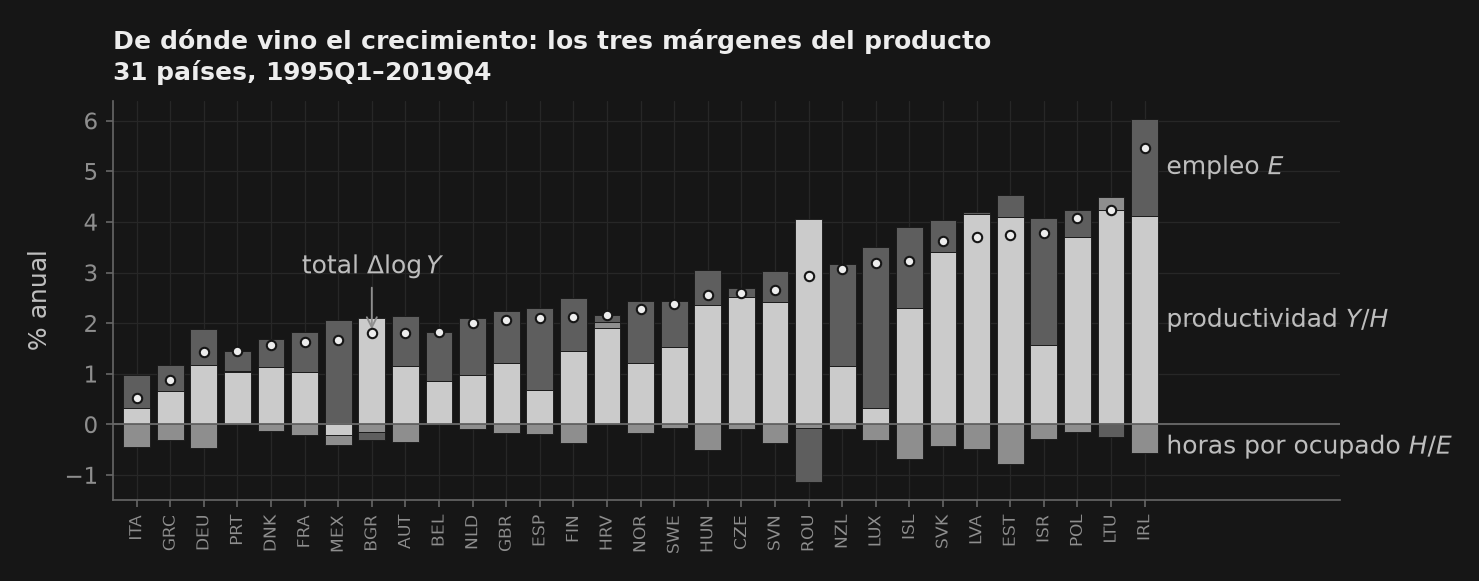

In [10]:
fig, ax = _nbstyle.figura(figsize="ancho")
g = crecim.sort_values("g_y")
x = np.arange(len(g))
base_pos = np.zeros(len(g))
base_neg = np.zeros(len(g))
PARTES = (("g_prod", "productividad $Y/H$", _nbstyle.BARRA_COLORES[0]),
          ("g_horas", "horas por ocupado $H/E$", _nbstyle.BARRA_COLORES[1]),
          ("g_empleo", "empleo $E$", _nbstyle.BARRA_COLORES[2]))
centros = {}                      # el centro de cada segmento en la última barra
for clave, etiqueta, col in PARTES:
    v = g[clave].to_numpy()
    base = np.where(v >= 0, base_pos, base_neg)
    ax.bar(x, v, bottom=base, color=col, edgecolor=_nbstyle.FONDO, lw=0.4)
    centros[etiqueta] = base[-1] + v[-1] / 2.0
    base_pos = base_pos + np.where(v >= 0, v, 0.0)
    base_neg = base_neg + np.where(v < 0, v, 0.0)
ax.plot(x, g["g_y"].to_numpy(), "o", color=_nbstyle.TINTA, mec=_nbstyle.FONDO, ms=4.5, zorder=5)
ax.axhline(0, color=_nbstyle.SPINE, lw=0.9)
ax.set_xticks(x); ax.set_xticklabels(g.index, rotation=90, fontsize=8.4)
ax.set_ylabel("% anual")
ax.set_title("De dónde vino el crecimiento: los tres márgenes del producto\n"
             f"{len(g)} países, {g['desde'].min()}–{g['hasta'].max()}")
# Los nombres, junto a los segmentos de la última barra (la más alta) y junto a
# un punto, en vez de en una leyenda.
ax.set_xlim(-0.7, len(g) + 4.8)
for etiqueta, y in centros.items():
    # Un segmento negativo cuelga bajo la línea del cero: su nombre baja con él.
    ax.annotate(etiqueta, xy=(x[-1] + 0.4, y), xytext=(4, 0 if y >= 0 else -4),
                textcoords="offset points", ha="left", va="center", color=_nbstyle.TEXTO)
i = len(g) // 4
ax.annotate("total $\\Delta\\log Y$", xy=(x[i], g["g_y"].iloc[i]), xytext=(0, 26),
            textcoords="offset points", ha="center", va="bottom", color=_nbstyle.TEXTO,
            arrowprops=_nbstyle.FLECHA)
plt.show()


### 2.1 Cincuenta años de crecimiento, veinticinco de ciclo

La contabilidad anterior abarca veinticinco años, porque ese es el tramo que publican los cuadros vigentes de la contabilidad nacional. Da de sobra para medir una tasa de crecimiento y se queda muy corto para ver cambiar a una economía.

Dos países de este panel tienen una historia archivada que llega más atrás, y son justo aquellos cuyo registro de posguerra más merece la pena tener. Las cuentas trimestrales de España se remontan a **1970** y las de Japón a **1960** — no en los cuadros de hoy, sino en ediciones del archivo de la OCDE que en su momento fueron las vigentes. Reconstruir esas series es una sola operación: la edición antigua y la nueva se solapan durante unos años, el cociente entre ambas sobre el solape es la constante que reconcilia dos bases de precios y dos metodologías, y aplicarlo traslada las **tasas de crecimiento** de la añada antigua a los niveles de la añada vigente. `ratio_splice` lo hace y además informa de cuán constante era realmente ese cociente, que es la garantía del empalme.

**Qué compra eso, y qué no.** Compra la tendencia. Dos ediciones de los mismos quince años españoles coinciden en el crecimiento acumulado con menos de medio punto porcentual de diferencia, de modo que una añada archivada es un testigo fiable de adónde fue una economía. No compra el ciclo: esas mismas dos ediciones discrepan sobre la volatilidad trimestral en un factor de alrededor de 1,8, y sus movimientos trimestre a trimestre correlacionan en torno a un medio. Los segundos momentos son lo primero que revisa una oficina estadística y lo último que fija, así que la volatilidad de una edición antigua es en parte una propiedad de la edición. Todo lo que sigue trata, por tanto, del **crecimiento a lo largo de décadas**, y los estadísticos de §3, §4 y §5 se quedan en los veinticinco años en los que una sola añada cubre a todos los países a la vez.

In [11]:
from puremacro.fetch.longpanel import ratio_splice

ARCHIVO = DATOS / "oecd_stes_vintages_gdp.csv.gz"
LARGO = {"ESP": "España", "JPN": "Japón"}

_arch = pd.read_csv(ARCHIVO, dtype={"edition": str})
_arch["date"] = pd.PeriodIndex(_arch["date"].astype(str), freq="Q").to_timestamp()


def pib_real_largo(code):
    """PIB real tan atrás como llegue el archivo, en un solo empalme.

    Espina: la edición más nueva, cuyos niveles se conservan exactamente.
    Segmento antiguo: la edición cuya serie empieza antes — la historia más
    profunda que la OCDE llegó a publicar para este país. `ratio_splice` se
    niega a hacer un empalme que no puede estimar, así que una serie devuelta
    es una serie cuya costura ha sido comprobada.
    """
    d = _arch[_arch["code"] == code]
    piv = d.pivot_table(index="date", columns="edition", values="value").sort_index()
    inicios = {e: piv[e].dropna().index.min() for e in piv.columns}
    nueva = max(piv.columns)
    profunda = min(inicios, key=lambda e: (inicios[e], e))
    return ratio_splice([(nueva, piv[nueva].dropna()),
                         (profunda, piv[profunda].dropna())])


pib_largo, costuras_largo = {}, []
for code in LARGO:
    res = pib_real_largo(code)
    pib_largo[code] = res.series.loc[:HASTA]
    for s in res.seams:
        costuras_largo.append({"code": code, "antigua": s.older, "nueva": s.newer,
                               "costura": s.date.to_period("Q"), "solape": s.overlap_n,
                               "deriva %": 100.0 * s.ratio_drift, "estable": s.stable})

print("PIB real, empalmado hacia atrás hasta la edición más profunda del archivo:\n")
print(pd.DataFrame(costuras_largo).to_string(index=False,
                                             float_format=lambda v: f"{v:.3f}"))
for code, s in pib_largo.items():
    print(f"  {LARGO[code]:6s} {s.index.min().to_period('Q')}-"
          f"{s.index.max().to_period('Q')}, {len(s)} trimestres "
          f"({len(s) - 100} más que el panel común)")
assert all(r["estable"] for r in costuras_largo)

PIB real, empalmado hacia atrás hasta la edición más profunda del archivo:

code antigua  nueva costura  solape  deriva %  estable
 ESP  199907 202608  1995Q1      16     0.329     True
 JPN  199907 202608  1994Q1      21     1.042     True
  España 1970Q1-2019Q4, 200 trimestres (100 más que el panel común)
  Japón  1960Q1-2019Q4, 240 trimestres (140 más que el panel común)


### Los dos hechos que da una muestra larga

**Japón no se desaceleró. Se paró, dos veces.** El crecimiento medio por década va 9,7%, 4,7%, 3,8%, 1,4%, 0,5%, 1,0%. El primer número y el quinto difieren en un factor de dieciocho, y nada de eso se ve en una muestra que empiece en 1995 — que solo contiene los dos últimos. Si se parte la historia donde los datos quieren que se parta, con el criterio de mínimos cuadrados que elige el corte que minimiza la varianza residual alrededor de dos medias, cae en **1973Q2**: la crisis del petróleo, escogida por la serie y no impuesta sobre ella. Antes de ese trimestre, 9,1% al año; después, 1,9%. Japón termina la muestra en ocho veces su tamaño de 1960, y bastante más de la mitad de ese múltiplo se ganó en los trece años previos al corte.

**El crecimiento de España está casi todo en el pasado.** Sus décadas van 3,5%, 2,8%, 2,5%, 2,4%, 1,1% — un declive más suave, y que esconde la estructura de verdad. La misma búsqueda de corte sitúa la discontinuidad española en **2008Q1**, y la aritmética a cada lado es contundente: tres cuartas partes de la muestra quedan antes de ese trimestre y acumulan casi todo el crecimiento. La economía española es algo más de tres veces su tamaño de 1970, y alcanzó casi todo ese múltiplo antes de la crisis financiera.

Ninguno de los dos hechos es un estadístico del ciclo económico. Los dos son de la clase de cosas que un curso que mide ciclos sobre veinticinco años de datos debería saber que no puede ver.

In [12]:
filas = []
for code, s in pib_largo.items():
    g = 400.0 * np.log(s).diff().dropna()
    por_dec = g.groupby((g.index.year // 10) * 10).mean()
    filas.append(pd.Series(por_dec, name=LARGO[code]))
decadas = pd.DataFrame(filas).sort_index(axis=1)
print("Crecimiento trimestral medio anualizado, % anual, por década:\n")
print(decadas.round(1).to_string())


def quandt(g, min_lado=40):
    """El corte que minimiza la varianza residual alrededor de dos medias."""
    mejor, arg = np.inf, None
    for i in range(min_lado, len(g) - min_lado):
        a, b = g.iloc[:i], g.iloc[i:]
        scr = float(((a - a.mean()) ** 2).sum() + ((b - b.mean()) ** 2).sum())
        if scr < mejor:
            mejor, arg = scr, i
    return arg


print("\nDónde sitúa el corte la propia serie:\n")
for code, s in pib_largo.items():
    g = 400.0 * np.log(s).diff().dropna()
    k = quandt(g)
    antes, despues = g.iloc[:k], g.iloc[k:]
    tot = float(np.log(s.iloc[-1] / s.iloc[0]))
    pre = float(np.log(s.loc[g.index[k]] / s.iloc[0]))
    print(f"  {LARGO[code]}: {g.index[k].to_period('Q')} — "
          f"{antes.mean():.1f}% anual antes ({len(antes)} trimestres), "
          f"{despues.mean():.1f}% después ({len(despues)} trimestres)")
    print(f"     la economía acaba en {np.exp(tot):.2f}x su tamaño de "
          f"{s.index.min().year}, y el {100 * pre / tot:.0f}% de eso se alcanzó "
          f"antes del corte")

assert decadas.loc["Japón"].iloc[0] > 3 * decadas.loc["Japón"].iloc[-1]

Crecimiento trimestral medio anualizado, % anual, por década:

date    1960  1970  1980  1990  2000  2010
España   NaN   3.5   2.8   2.5   2.4   1.1
Japón    9.7   4.7   3.8   1.4   0.5   1.0

Dónde sitúa el corte la propia serie:

  España: 2008Q1 — 3.1% anual antes (151 trimestres), 0.6% después (48 trimestres)
     la economía acaba en 3.41x su tamaño de 1970, y el 94% de eso se alcanzó antes del corte
  Japón: 1973Q2 — 9.1% anual antes (52 trimestres), 1.9% después (187 trimestres)
     la economía acaba en 8.02x su tamaño de 1960, y el 57% de eso se alcanzó antes del corte


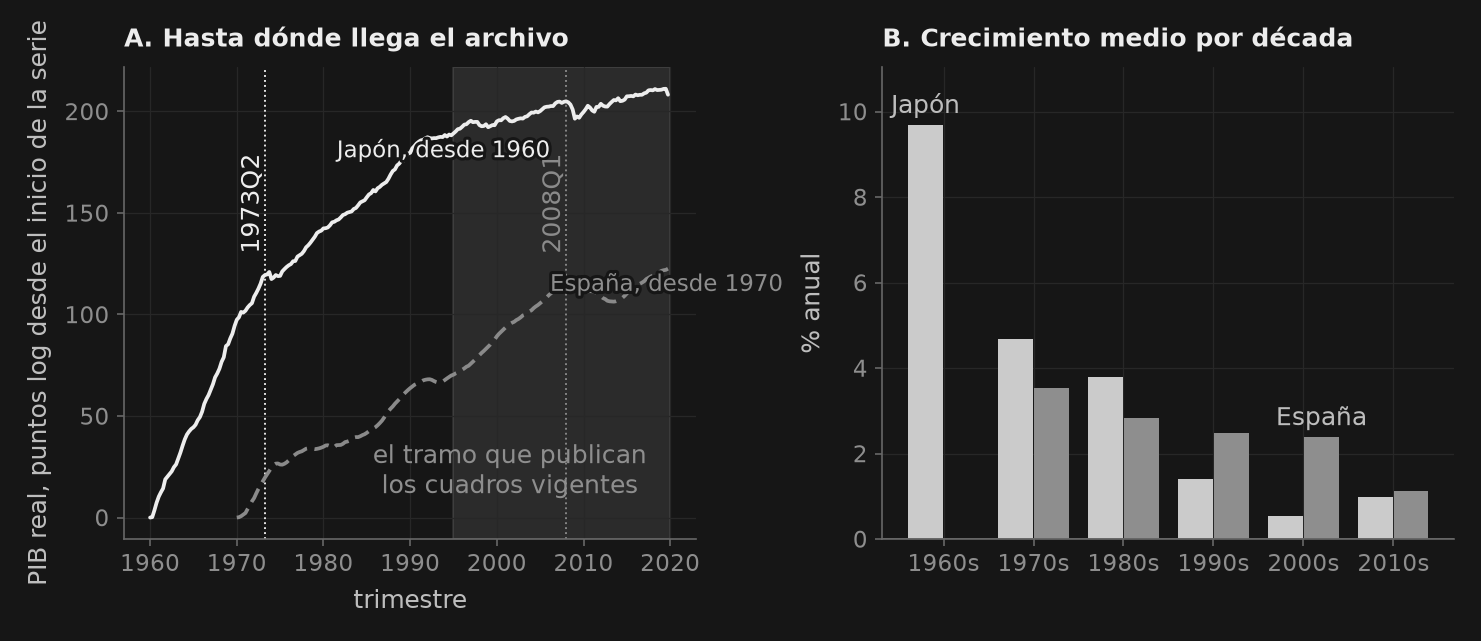

In [13]:
fig, (axI, axD) = _nbstyle.figura(1, 2)

for code, col, ls in (("JPN", cols[0], "-"), ("ESP", cols[3], (0, (4, 2)))):
    s = pib_largo[code]
    axI.plot(s.index, 100.0 * np.log(s / s.iloc[0]), color=col, lw=1.8, ls=ls,
             label=f"{LARGO[code]}, desde {s.index.min().year}")
axI.axvspan(pd.Timestamp("1995-01-01"), pd.Timestamp(HASTA), color=_nbstyle.RECESION, zorder=0)
axI.annotate("el tramo que publican\nlos cuadros vigentes",
             xy=(pd.Timestamp("2001-07-01"), 12), color=_nbstyle.NOTA, ha="center")
for code, col in (("JPN", cols[0]), ("ESP", cols[3])):
    g = np.log(pib_largo[code]).diff().dropna()
    b = g.index[quandt(400.0 * g)]
    axI.axvline(b, color=col, lw=0.9, ls=":", zorder=1)
    # La fecha del corte, por encima de las dos series y a la izquierda de su
    # raya: abajo cruzaba la serie de España y la nota del tramo publicado.
    axI.annotate(f"{b.to_period('Q')}", xy=(b, 130), color=col,
                 ha="right", rotation=90, va="bottom")
axI.set_ylabel("PIB real, puntos log desde el inicio de la serie")
axI.set_xlabel("trimestre")
axI.set_title("A. Hasta dónde llega el archivo")

w = decadas.T
x = np.arange(len(w))
axD.bar(x - 0.2, w["Japón"], 0.38, color=_nbstyle.BARRA_COLORES[0])
axD.bar(x + 0.2, w["España"], 0.38, color=_nbstyle.BARRA_COLORES[1])
axD.axhline(0, color=_nbstyle.SPINE, lw=0.9)
axD.set_axisbelow(True)
axD.set_xticks(x); axD.set_xticklabels([f"{int(d)}s" for d in w.index])
axD.set_ylabel("% anual")
axD.set_title("B. Crecimiento medio por década")
axD.margins(y=0.14); axD.set_ylim(bottom=0)
# El nombre de cada país sobre una de sus barras: Japón sobre su primera década,
# España sobre la década en que más sobresale.
i_j = int(np.flatnonzero(w["Japón"].notna())[0])
i_e = int(np.nanargmax((w["España"] - w["Japón"]).to_numpy()))
for pais, dx, i in (("Japón", -0.2, i_j), ("España", 0.2, i_e)):
    axD.annotate(pais, xy=(x[i] + dx, w[pais].iloc[i]), xytext=(0, 3),
                 textcoords="offset points", ha="center", va="bottom", color=_nbstyle.TEXTO)
_nbstyle.etiquetar(axI)
plt.show()


## 3. Tendencia y ciclo — y si el filtro cambia una respuesta

Una serie macro $y_t$ mezcla una **tendencia** lenta $\tau_t$ y un **ciclo** $c_t = y_t - \tau_t$. El análisis del ciclo trata de $c_t$: su volatilidad, su comovimiento, su persistencia. Lo difícil es definir $\tau_t$, y no hay respuesta consensuada.

- **Hodrick–Prescott:** elige $\tau_t$ equilibrando ajuste y suavidad, gobernado por $\lambda$ (1600 para datos trimestrales).
- **Hamilton (2018):** regresa $y_{t+h}$ sobre sus propios rezagos recientes; el residuo es el ciclo. El artículo de Hamilton se titula «Why You Should Never Use the Hodrick-Prescott Filter», y su acusación es concreta: el HP fabrica dinámicas cíclicas que no están en los datos, así que los hechos derivados de él pueden ser artefactos del filtro.
- **Primeras diferencias:** ningún modelo de tendencia. Tosco, y libre de las dos críticas.

### Por qué importa la elección del filtro: El efecto Slutsky-Yule y la calibración en RBC/DSGE
¿Por qué esta discrepancia econométrica importa tan decisivamente para la macroeconomía?
1. **El efecto de ciclos espurios de Slutsky-Yule:** Eugen Slutsky (1937) y Udny Yule (1927) demostraron matemáticamente que aplicar filtros lineales (como medias móviles o diferencias) a ruido blanco no correlacionado o a paseos aleatorios genera endógenamente oscilaciones sinusoidales aparentes («ciclos espurios»). Cogley y Nason (1995) demostraron que la función de transferencia del filtro HP $|H(e^{-i\omega})|^2$ concentra artificialmente la potencia espectral en las frecuencias del ciclo económico (6 a 32 trimestres) cuando se aplica a procesos estacionarios en diferencias $I(1)$ como el logaritmo del PIB. ¡Un paseo aleatorio puro con deriva filtrado con HP parece un ciclo económico genuino!
2. **Calibración estructural distorsionada en modelos RBC y DSGE:** Desde Kydland y Prescott (1982), la metodología estándar en macroeconomía cuantitativa consiste en emparejar momentos: los investigadores calibran los parámetros estructurales (la elasticidad Frisch de oferta laboral $\nu$, el hábito de consumo $b$ o los costes de ajuste del capital $\kappa$) para que las variables simuladas del modelo reproduzcan los segundos momentos de los datos empíricos filtrados con HP ($\sigma_c/\sigma_y$, autocorrelación, covarianzas cruzadas). Si el filtro HP de dos lados introduce persistencia artificial o altera desfases temporales, los parámetros estructurales terminan ajustándose para replicar *artefactos del filtrado* y no verdaderos mecanismos de propagación económica.

La manera habitual de presentar esto es graficar dos ciclos que se ven un poco distintos y seguir adelante. Eso no zanja nada. El contraste honesto es si el filtro cambia una **respuesta**, así que elegimos un hecho que tiene una —*¿es procíclica la productividad?*— y se lo preguntamos a los tres filtros, en todos los países.

Importa porque la respuesta es una afirmación sobre el mundo. La prociclicidad de la productividad medida es la observación detrás del atesoramiento de trabajo, la utilización variable de la capacidad y buena parte del caso a favor y en contra de los ciclos impulsados por tecnología: si la productividad sube en los auges, o bien la tecnología está causando el auge, o bien las empresas retienen trabajadores ociosos en las recesiones y la productividad medida está recogiendo esa holgura y no la tecnología.

In [14]:
def tres_filtros(s):
    """Ciclos (HP, Hamilton, primera diferencia) de una serie en logaritmos."""
    s = s.dropna()
    hp, _ = hp_filter(s)
    ham, _ = hamilton_filter(s)
    return (pd.Series(np.asarray(hp), index=s.index),
            pd.Series(np.asarray(ham), index=s.index),
            s.diff())


def ciclicidad(code):
    """corr(ciclo del producto, ciclo de la productividad) con cada filtro."""
    d = PANEL[code]
    ly = 100.0 * np.log(d["y"])
    lp = ly - 100.0 * np.log(d["h"])
    out = {"code": code, "n": len(d)}
    for nombre, fy, fp in zip(("HP", "Hamilton", "diferencia"),
                              tres_filtros(ly), tres_filtros(lp)):
        j = pd.concat([fy.rename("y"), fp.rename("p")], axis=1, sort=True).dropna()
        out[nombre] = float(j["y"].corr(j["p"])) if len(j) > 8 else np.nan
    return out


cic = pd.DataFrame([ciclicidad(c) for c in CODIGOS]).set_index("code")
F3 = ["HP", "Hamilton", "diferencia"]
cic["rango"] = cic[F3].max(axis=1) - cic[F3].min(axis=1)

todos_pos = (cic[F3] > 0).all(axis=1)
todos_neg = (cic[F3] < 0).all(axis=1)
cambian = ~(todos_pos | todos_neg)
print("¿Es procíclica la productividad medida? corr(ciclo de Y, ciclo de Y/H)\n")
print(cic.sort_values("HP").round(2).to_string())
print(f"\nmediana: " + ", ".join(f"{k} {cic[k].median():+.2f}" for k in F3))
print(f"positiva con LOS TRES filtros: {int(todos_pos.sum())} de {len(cic)}")
print(f"negativa con LOS TRES filtros: {int(todos_neg.sum())} "
      f"({', '.join(cic.index[todos_neg])})")
print(f"el signo depende del filtro:   {int(cambian.sum())} "
      f"({', '.join(cic.index[cambian])})")
print(f"mayor dispersión entre filtros: {cic['rango'].max():.2f} "
      f"({cic['rango'].idxmax()}); dispersión mediana {cic['rango'].median():.2f}")

assert int(todos_pos.sum()) > 0.8 * len(cic)

¿Es procíclica la productividad medida? corr(ciclo de Y, ciclo de Y/H)

        n    HP  Hamilton  diferencia  rango
code                                        
ESP   100 -0.26     -0.32       -0.14   0.18
PRT   100  0.14     -0.01        0.16   0.17
NZL    44  0.36     -0.24        0.29   0.59
NOR   100  0.36      0.18        0.76   0.57
EST    82  0.37      0.63        0.46   0.27
POL   100  0.38      0.22        0.70   0.48
ISL   100  0.43      0.38        0.73   0.34
DNK   100  0.46      0.60        0.49   0.14
ISR   100  0.52      0.53        0.24   0.29
NLD    96  0.56      0.55        0.48   0.08
LVA   100  0.58      0.73        0.63   0.15
AUT   100  0.62      0.70        0.29   0.41
ITA    96  0.63      0.44        0.44   0.18
FRA   100  0.63      0.59        0.81   0.22
BEL   100  0.65      0.55        0.65   0.11
SWE   100  0.69      0.62        0.72   0.10
LTU   100  0.70      0.80        0.60   0.20
GBR   100  0.71      0.68        0.59   0.12
IRL   100  0.71      0.65   

### El veredicto sobre el filtro, y sobre España

**Hamilton tiene razón sobre el número y no la tiene sobre la preocupación.** Los tres filtros discrepan en una mediana de 0.18 y hasta en 0.59 en el peor caso, así que quien cite `corr` con dos decimales está citando al filtro tanto como a los datos. Pero el *signo* —que es lo que el hecho realmente es— sobrevive en 29 de 31 países —28 positivos y España negativa—, y solo dos países cambian de respuesta según cómo quites la tendencia. La prociclicidad de la productividad no es un artefacto del HP.

**España es la excepción, y tampoco es un artefacto del filtro**: negativa con los tres. Esa es una propiedad real y famosa del ciclo español, y §5 la explica en una línea — España ajusta por empleo con más violencia que ningún otro país del panel, y los puestos que destruye primero son los menos productivos. La productividad medida por tanto *sube* en las recesiones españolas, por una razón que no tiene nada que ver con la tecnología y todo con la composición. Guárdatelo: es la advertencia más limpia disponible de que la «productividad» medida como cociente es también una afirmación sobre el denominador.

#### Los dos países que «dependen del filtro», resueltos

Dejar a Portugal y Nueva Zelanda etiquetados como *decide el filtro* sería encogerse de hombros donde hay un diagnóstico disponible, y resultan ser dos situaciones distintas con la misma etiqueta.

**Portugal no cambia de signo.** Los tres filtros dejan la correlación a menos de $0.16$ de cero. Nada cambia de signo de manera significativa; una estimación puntual posada sobre el cero lo cruza en cuanto la empujas, e informar eso como «la respuesta depende del filtro» disfraza de polémica metodológica a un país cuya productividad medida es simplemente **acíclica**. Lo honesto es decir $\mathrm{corr} \approx 0$.

**Nueva Zelanda es un problema de datos, y se delata sola.** No por ningún diagnóstico aislado —Rumanía y Estonia tienen horas más ruidosas en desviación típica cruda— sino por la combinación de tres, todos calculados abajo. Su muestra laboral es la **más corta del panel**: 44 trimestres desde 2009, así que contiene una expansión y ninguna recesión, y una ciclicidad estimada sin recesión está estimada sobre nada. Sus horas tienen $2.3\times$ la volatilidad mediana del panel, con un 16% de trimestres moviéndose más de 3%. Y su primera autocorrelación de $\Delta\log H$ es $-0.51$, la **más negativa del panel** — la firma del error de medición en el *nivel* de una serie, porque un error transitorio en niveles se convierte en un diente de sierra en diferencias, arriba un trimestre y de vuelta al siguiente. El insumo de trabajo real no se comporta así.

Así que la dispersión de $0.59$ entre filtros no son tres métodos discrepando sobre Nueva Zelanda. Es una estimación sin nada detrás, que se mueve cuando la tocas. Eso es un hallazgo, y lo correcto es informarlo — pero solo para este país: en el conjunto del panel, la correlación entre lo ruidosas que son las horas de un país y cuánto se mueve su respuesta con el filtro es de apenas $0.19$, así que **el ruido explica a Nueva Zelanda, no es una ley general**. Dos de treinta y un países no se pueden responder con estos datos, y treinta y uno menos dos sigue siendo el hecho.

In [15]:
_ruido = []
for code in CODIGOS:
    dh = (100.0 * np.log(PANEL[code]["h"])).diff().dropna()
    _ruido.append({"code": code, "n": len(PANEL[code]),
                   "sd(dlog H)": float(dh.std(ddof=1)),
                   "AR(1) de dlog H": float(dh.autocorr(1)),
                   "|dlog H| > 3%": float((dh.abs() > 3.0).mean()),
                   "dispersión": float(cic.loc[code, "rango"])})
ruido = pd.DataFrame(_ruido).set_index("code")
print("¿Qué tan bien medida está la serie de horas de cada país?\n")
print(ruido.sort_values("sd(dlog H)", ascending=False).head(6).round(2).to_string())
print("  ...")
print(ruido.sort_values("sd(dlog H)").head(3).round(2).to_string())
print(f"\nmediana del panel sd(dlog H) = {ruido['sd(dlog H)'].median():.2f}. La de "
      f"Nueva Zelanda es {ruido.loc['NZL', 'sd(dlog H)']:.2f} "
      f"({ruido.loc['NZL', 'sd(dlog H)'] / ruido['sd(dlog H)'].median():.1f}x), un "
      f"{ruido.loc['NZL', '|dlog H| > 3%']:.0%} de sus trimestres se mueve más de "
      f"3%, su AR(1) de {ruido.loc['NZL', 'AR(1) de dlog H']:+.2f} es el más "
      f"negativo del panel, y sus {int(ruido.loc['NZL', 'n'])} trimestres son los "
      f"menos. Ningún récord aislado; la combinación.")
print(f"Las tres correlaciones de Portugal: "
      + ", ".join(f"{k} {cic.loc['PRT', k]:+.2f}" for k in F3)
      + " — todas a menos de 0.16 del cero, que es una respuesta y no tres.")
print(f"\nEn el panel entero, en cambio, corr(dispersión, sd de dlog H) es solo de "
      f"{ruido['dispersión'].corr(ruido['sd(dlog H)']):.2f}: las horas ruidosas "
      f"explican a Nueva Zelanda, no el tamaño general de la dispersión.")

assert ruido.loc["NZL", "AR(1) de dlog H"] < -0.3
assert ruido["AR(1) de dlog H"].idxmin() == "NZL"
assert ruido["n"].idxmin() == "NZL"
assert cic.loc["PRT", F3].abs().max() < 0.2

¿Qué tan bien medida está la serie de horas de cada país?

        n  sd(dlog H)  AR(1) de dlog H  |dlog H| > 3%  dispersión
code                                                             
ROU   100        2.58            -0.39           0.13        0.13
EST    82        2.54             0.02           0.17        0.27
NZL    44        2.40            -0.51           0.16        0.59
ISL   100        2.23            -0.15           0.15        0.34
LVA   100        2.04             0.14           0.12        0.15
IRL   100        1.80            -0.12           0.08        0.22
  ...
        n  sd(dlog H)  AR(1) de dlog H  |dlog H| > 3%  dispersión
code                                                             
FRA   100        0.31             0.70            0.0        0.22
BEL   100        0.44            -0.04            0.0        0.11
DEU   100        0.50             0.18            0.0        0.04

mediana del panel sd(dlog H) = 1.05. La de Nueva Zelanda es 2.40 (2.3x), un 

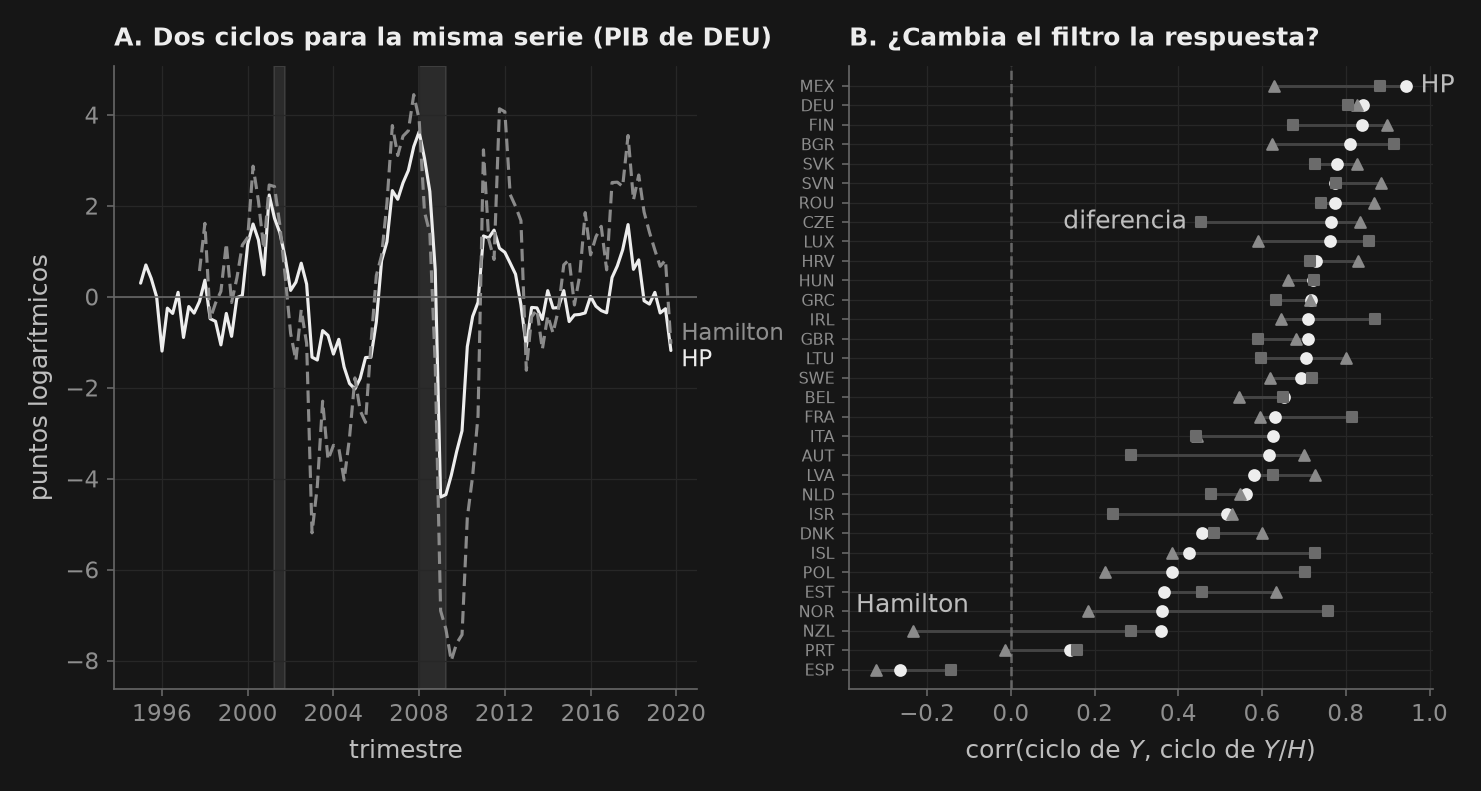

In [16]:
EJEMPLO = "DEU"
d_ej = PANEL[EJEMPLO]
ly_ej = 100.0 * np.log(d_ej["y"])
hp_c, ham_c, dif_c = tres_filtros(ly_ej)

fig, (axL, axR) = _nbstyle.figura(1, 2, alto=True)

for ini, fin in (("2001-04-01", "2001-10-01"), ("2008-01-01", "2009-04-01")):
    axL.axvspan(pd.Timestamp(ini), pd.Timestamp(fin), color=_nbstyle.RECESION, zorder=0)
axL.plot(hp_c.index, hp_c.to_numpy(), color=cols[0], lw=1.5,
         label="HP")
axL.plot(ham_c.index, ham_c.to_numpy(), color=cols[3], lw=1.5, ls=(0, (4, 2)),
         label="Hamilton")
axL.axhline(0, color=_nbstyle.SPINE, lw=0.8)
axL.set_ylabel("puntos logarítmicos"); axL.set_xlabel("trimestre")
axL.set_title(f"A. Dos ciclos para la misma serie (PIB de {EJEMPLO})")

orden = cic.sort_values("HP").index
yy = np.arange(len(orden))
MK = {"HP": ("o", cols[0]), "Hamilton": ("^", cols[3]),
      "diferencia": ("s", cols[4])}
for nombre, (mk, col) in MK.items():
    axR.scatter(cic.loc[orden, nombre], yy, s=26, marker=mk, color=col, zorder=3)
for i, code in enumerate(orden):
    lo, hi = cic.loc[code, F3].min(), cic.loc[code, F3].max()
    axR.plot([lo, hi], [i, i], color=_nbstyle.tono(0.25), lw=1.4, ls="-", zorder=1)
axR.axvline(0, color=_nbstyle.SPINE, ls="--", lw=1.2)
axR.set_yticks(yy); axR.set_yticklabels(orden, fontsize=7.6)
axR.set_ylim(-1, len(orden))
axR.set_xlabel("corr(ciclo de $Y$, ciclo de $Y/H$)")
axR.set_title("B. ¿Cambia el filtro la respuesta?")
# El nombre de cada marcador junto a un país en el que queda lejos de los otros dos.
for nombre, code, dxy, ha, va in (("HP", "MEX", (7, 0), "left", "center"),
                                  ("Hamilton", "NZL", (0, 6), "center", "bottom"),
                                  ("diferencia", "CZE", (-7, 0), "right", "center")):
    if code in orden:
        i = int(np.where(orden == code)[0][0])
        axR.annotate(nombre, xy=(cic.loc[code, nombre], i), xytext=dxy,
                     textcoords="offset points", ha=ha, va=va, color=_nbstyle.TEXTO)
_nbstyle.etiquetar(axL, donde="fin", fuera=True)
plt.show()


## 4. Los hechos del ciclo, como distribución

Los hechos canónicos se enseñan normalmente como una lista corta de números para Estados Unidos. Con el panel de T01_B en disco se convierten en lo que un modelo de verdad tiene que reproducir: una **distribución entre países**, con mediana, dispersión y excepciones con nombre.

Calculamos, sobre el ciclo HP de cada serie: volatilidad relativa $\sigma(x)/\sigma(y)$, comovimiento $\mathrm{corr}(x, y)$, persistencia $\mathrm{corr}(y_t, y_{t-1})$ y la cuota de la varianza del ciclo que de verdad cae en la banda de 6–32 trimestres. A los habituales $C$ e $I$ añadimos los tres márgenes de §2, porque son el asunto de esta lección.

In [17]:
SERIES = {"c": "consumo", "i": "inversión", "h": "horas",
          "e": "empleo", "prod": "productividad $Y/H$",
          "hpe": "horas por ocupado"}
WELCH_SEG = 64          # segmento de Welch para la cuota espectral, en trimestres


def hechos_del_ciclo(code):
    # NO PANEL[code]: ese marco está recortado a los trimestres donde existen a
    # la vez horas y cabezas, y el consumo no necesita ninguna de las dos.
    # Recortar C a la muestra laboral pondría el sigma(c)/sigma(y) de México en
    # 1.06 sobre 2005-2019 en vez de 0.96 sobre 1995-2019 — otra cifra para el
    # mismo país bajo la misma convención declarada, que es exactamente el
    # error que prohíben las fichas de medición del curso. Cada cociente de
    # abajo se calcula sobre la muestra que comparte su propio par, y `n`
    # informa la más corta.
    d = marco_laboral(code)
    L = {k: 100.0 * np.log(d[k]) for k in ("y", "c", "i", "h", "e")}
    L["prod"] = L["y"] - L["h"]
    L["hpe"] = L["h"] - L["e"]
    cy = {}
    for k, s in L.items():
        s = s.dropna()
        if len(s) < MIN_Q:
            continue
        c, _ = hp_filter(s)
        cy[k] = pd.Series(np.asarray(c), index=s.index)
    y = cy["y"]
    n_lab = int(len(PANEL[code]))
    # La cuota espectral necesita el segmento de 64 trimestres de Welch, y una
    # muestra más corta no lo sostiene: acortar el segmento sí devuelve un
    # número, pero uno cuya resolución en frecuencia es tan gruesa que no es
    # comparable con los demás (los 44 trimestres de Nueva Zelanda dan 0.47
    # frente a una mediana del panel cercana a 0.79, y la diferencia es la
    # longitud del segmento, no Nueva Zelanda). Devolvemos NaN y decimos
    # cuántos, en vez de tabular un estadístico junto a otros con los que no se
    # puede comparar.
    out = {"code": code, "n": len(y), "n(lab)": n_lab,
           "sd(y)": float(y.std(ddof=1)),
           "AR(1)": float(y.autocorr(1)),
           "banda 6-32": (float(business_cycle_band_power(y.to_numpy()))
                          if len(y) >= WELCH_SEG else np.nan)}
    for k in SERIES:
        if k not in cy:
            continue
        j = pd.concat([y.rename("y"), cy[k].rename("x")], axis=1, sort=True).dropna()
        out[f"sd({k})/sd(y)"] = float(j["x"].std(ddof=1) / j["y"].std(ddof=1))
        out[f"corr({k},y)"] = float(j["y"].corr(j["x"]))
    return out


hechos = pd.DataFrame([hechos_del_ciclo(c) for c in CODIGOS]).set_index("code")
print(f"Hechos del ciclo económico, filtro HP, {len(hechos)} países "
      f"(hasta {HASTA[:4]}T4):\n")
print(hechos.round(2).to_string())

med = hechos.median(numeric_only=True)
print("\n--- la mediana del panel, que es lo que un modelo tiene que acertar ---")
print(f"  la inversión es {med['sd(i)/sd(y)']:.1f}x más volátil que el producto; "
      f"más volátil en {int((hechos['sd(i)/sd(y)'] > 1).sum())}/{len(hechos)} países")
print(f"  el consumo {med['sd(c)/sd(y)']:.2f}x, y POR ENCIMA de uno en "
      f"{int((hechos['sd(c)/sd(y)'] > 1).sum())} de {len(hechos)} — la división "
      f"que T01_B §4.3 intenta explicar")
print(f"  horas {med['sd(h)/sd(y)']:.2f}x frente a empleo "
      f"{med['sd(e)/sd(y)']:.2f}x: el margen intensivo añade un "
      f"{100*(med['sd(h)/sd(y)']/med['sd(e)/sd(y)']-1):.0f}% más de volatilidad "
      f"que contar solo cabezas")
print(f"  la productividad {med['sd(prod)/sd(y)']:.2f}x y procíclica "
      f"(corr mediana {med['corr(prod,y)']:+.2f})")
_cortas = hechos.index[hechos["banda 6-32"].isna()]
print(f"  persistencia {med['AR(1)']:.2f}; el {med['banda 6-32']:.0%} de la "
      f"varianza del ciclo cae en la banda de 6–32 trimestres (sobre los "
      f"{int(hechos['banda 6-32'].notna().sum())} países con al menos "
      f"{WELCH_SEG} trimestres"
      + (f"; no {', '.join(_cortas)})" if len(_cortas) else ")"))

assert (hechos["sd(i)/sd(y)"] > 1.0).all()
assert hechos["banda 6-32"].min() > 0.5

Hechos del ciclo económico, filtro HP, 31 países (hasta 2019T4):

        n  n(lab)  sd(y)  AR(1)  banda 6-32  sd(c)/sd(y)  corr(c,y)  sd(i)/sd(y)  corr(i,y)  sd(h)/sd(y)  corr(h,y)  sd(e)/sd(y)  corr(e,y)  sd(prod)/sd(y)  corr(prod,y)  sd(hpe)/sd(y)  corr(hpe,y)
code                                                                                                                                                                                                 
AUT   100     100   1.16   0.86        0.89         0.60       0.43         2.00       0.71         0.81       0.63         0.39       0.80            0.80          0.62           0.68         0.29
BEL   100     100   0.91   0.86        0.92         0.68       0.43         3.24       0.67         0.78       0.61         0.54       0.43            0.81          0.65           0.52         0.45
BGR    96      96   2.66   0.64        0.60         2.47       0.62         6.07      -0.30         0.67       0.38         0.55       0.44   

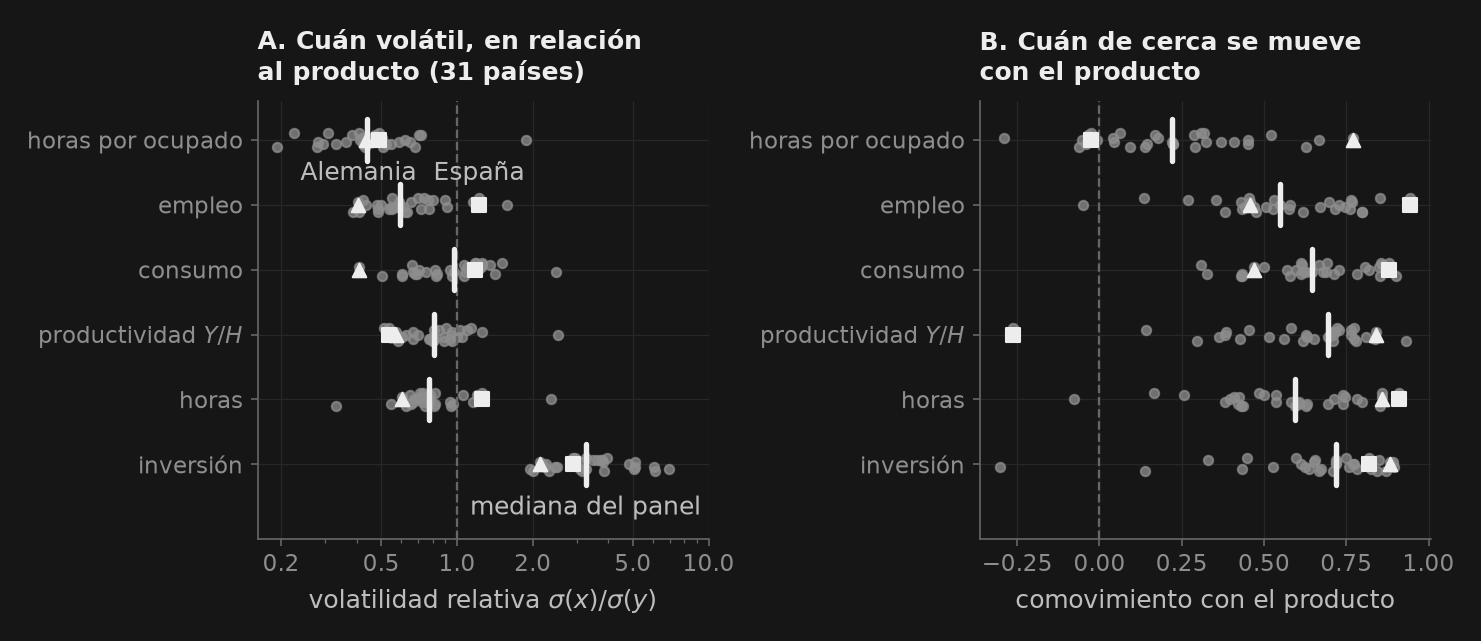

In [18]:
fig, (axV, axC) = _nbstyle.figura(1, 2)
ORDEN = ["i", "h", "prod", "c", "e", "hpe"]

for ax, patron, etiqueta_x, ref in (
        (axV, "sd({})/sd(y)", "volatilidad relativa $\\sigma(x)/\\sigma(y)$", 1.0),
        (axC, "corr({},y)", "comovimiento con el producto", 0.0)):
    for j, k in enumerate(ORDEN):
        v = hechos[patron.format(k)].dropna()
        ruidito = (np.arange(len(v)) % 7 - 3) * 0.035
        ax.scatter(v, np.full(len(v), j) + ruidito, s=20, color=_nbstyle.NOTA,
                   alpha=0.75, zorder=2)
        ax.plot([v.median(), v.median()], [j - 0.32, j + 0.32], color=cols[0],
                lw=2.6, ls="-", zorder=3)
        for code, mk in (("DEU", "^"), ("ESP", "s")):
            if code in v.index:
                ax.scatter([v.loc[code]], [j], s=42, marker=mk, color=cols[0],
                           zorder=4)
    ax.axvline(ref, color=_nbstyle.SPINE, ls="--", lw=1.1)
    ax.set_yticks(range(len(ORDEN)))
    ax.set_yticklabels([SERIES[k] for k in ORDEN])
    ax.set_ylim(-1.15, len(ORDEN) - 0.4)
    ax.set_xlabel(etiqueta_x)
axV.set_xscale("log")
axV.set_xticks([0.2, 0.5, 1, 2, 5, 10])
axV.get_xaxis().set_major_formatter(plt.matplotlib.ticker.ScalarFormatter())
axV.set_title(f"A. Cuán volátil, en relación\nal producto ({len(hechos)} países)")
axC.set_title("B. Cuán de cerca se mueve\ncon el producto")
# Los dos países señalados, nombrados sobre sus marcas en la fila del empleo (donde
# quedan separados), y la mediana bajo su raya en la fila de la inversión.
j = ORDEN.index("e")
v = hechos["sd(e)/sd(y)"].dropna()
for code, nombre in (("DEU", "Alemania"), ("ESP", "España")):
    if code in v.index:
        axV.annotate(nombre, xy=(v.loc[code], j), xytext=(0, 9), textcoords="offset points",
                     ha="center", va="bottom", color=_nbstyle.TEXTO)
j = ORDEN.index("i")
v = hechos["sd(i)/sd(y)"].dropna()
axV.annotate("mediana del panel", xy=(v.median(), j - 0.32), xytext=(0, -5),
             textcoords="offset points", ha="center", va="top", color=_nbstyle.TEXTO)
plt.show()


## 5. La anatomía de una recesión

Los hechos de §4 son momentos incondicionales — promedian sobre todos los trimestres, de auge y de caída por igual. Pero la pregunta que cualquiera se hace de verdad sobre una recesión es *por dónde se fue el ajuste*, y la identidad de §2 la responde directamente. Toma el pico y el valle propios de cada país y parte la caída del producto en los tres márgenes:

$$ \underbrace{\Delta\log Y}_{\text{la recesión}} = \underbrace{\Delta\log(Y/H)}_{\text{productividad}} + \underbrace{\Delta\log(H/E)}_{\text{jornadas más cortas (intensivo)}} + \underbrace{\Delta\log E}_{\text{empleos perdidos (extensivo)}}. $$

Fechamos el pico y el valle por país en vez de imponer fechas comunes, porque 2008–09 no fue un suceso único con un solo calendario: Irlanda hizo pico en 2007T1 y Rumanía en 2008T4, y el valle griego llegó cuatro años y medio después de su pico.

### Instituciones del mercado de trabajo: Kurzarbeit frente a dualidad contractual (EPL)
¿Por qué una economía encaja el golpe en horas mientras otra lo encaja en cabezas?
El margen de ajuste es una decisión de equilibrio endógena determinada por las instituciones laborales:
- **Alemania y el *Kurzarbeit*:** El marco institucional alemán combina cuentas de horas a nivel de empresa (*Arbeitszeitkonten*) con subsidios estatales a la reducción de jornada (*Kurzarbeit*). El Estado cubre entre el 60% y el 67% del salario neto por las horas no trabajadas cuando las empresas recortan jornada en lugar de despedir. Como los empleadores industriales soportan elevados costes de búsqueda, selección y formación específica (capital del emparejamiento o *match capital*, Mortensen y Pissarides 1994), deciden atesorar mano de obra. El producto cae, las horas por trabajador se desploman y la productividad observada se hunde — pero el empleo permanece prácticamente intacto.
- **España y la dualidad de la protección al empleo:** En agudo contraste, el mercado laboral español estaba históricamente segmentado por una extrema dualidad en la Legislación de Protección del Empleo (EPL) (Bentolila, Dolado y Jimeno 2012, 2020). Los trabajadores indefinidos contaban con costes de despido muy elevados (hasta 45 días por año de servicio), mientras que más del 30% de la fuerza laboral estaba atrapada en contratos temporales con indemnizaciones mínimas. Al golpear la crisis financiera y de la construcción en 2008, las empresas tomaron la vía de menor resistencia legal: no redujeron horas, sino que no renovaron contratos temporales en masa. El empleo colapsó de manera violenta en el margen extensivo.
- **La paradoja de la productividad medida:** Además, debido a que los trabajadores temporales expulsados pertenecían de forma desproporcionada a sectores de baja cualificación y baja productividad (construcción y servicios no cualificados), su salida expulsó del denominador a los puestos de menor valor añadido. Como consecuencia aritmética, ¡la productividad laboral agregada ($Y/H$) *subió* (+7.2 puntos logarítmicos) durante una recesión devastadora! Un descomunal efecto composición sin ninguna relación con el progreso tecnológico.

In [19]:
def anatomia(code, lo="2007-01-01", hi="2011-12-31", pico_hasta="2008-12-31"):
    """Descomposición de pico a valle de la recesión de un país."""
    d = marco_laboral(code, hasta=None).dropna(subset=["y", "h", "e"]).loc[lo:hi]
    if len(d) < 12:
        return None
    ly = 100.0 * np.log(d["y"])
    cabeza = ly.loc[:pico_hasta]
    if cabeza.empty:
        return None
    pk = cabeza.idxmax()
    tr = ly.loc[pk:].idxmin()
    if tr == pk:
        return None
    a, b = d.loc[pk], d.loc[tr]
    dy = 100.0 * np.log(b["y"] / a["y"])
    dh = 100.0 * np.log(b["h"] / a["h"])
    de = 100.0 * np.log(b["e"] / a["e"])
    return {"code": code, "pico": pk.to_period("Q"), "valle": tr.to_period("Q"),
            "trimestres": int(round((tr - pk).days / 91.31)),
            "d_y": dy, "d_prod": dy - dh, "d_hpe": dh - de, "d_empleo": de}


rec = pd.DataFrame([r for r in (anatomia(c) for c in CODIGOS) if r]).set_index("code")
rec["residuo"] = rec.d_prod + rec.d_hpe + rec.d_empleo - rec.d_y
rec = rec.sort_values("d_y")
print("La Gran Recesión, de pico a valle, en puntos logarítmicos:\n")
# 'pico' y 'valle' son trimestres (Period): se redondea sólo lo numérico.
_tabla = rec.drop(columns="residuo")
print(_tabla.round({c: 2 for c in _tabla.select_dtypes("number")}).to_string())
assert rec["residuo"].abs().max() < 1e-9

cayeron = rec[rec["d_y"] < -0.5]
print(f"\n{len(cayeron)} de {len(rec)} países tuvieron una caída de más de medio "
      f"punto logarítmico. De esa caída, el país mediano perdió:")
for k, lbl in (("d_prod", "productividad"), ("d_hpe", "horas por ocupado"),
               ("d_empleo", "empleo")):
    print(f"  {(cayeron[k] / cayeron['d_y']).median():5.0%} por la vía de {lbl}")
subio = rec[(rec["d_y"] < -0.5) & (rec["d_prod"] > 0)]
_subio = ", ".join("{} ({:+.1f})".format(c, rec.loc[c, "d_prod"])
                   for c in subio.index)
print(f"\nY en {len(subio)} países la productividad medida SUBIÓ durante la "
      f"recesión: {_subio}")

La Gran Recesión, de pico a valle, en puntos logarítmicos:

        pico   valle  trimestres    d_y  d_prod  d_hpe  d_empleo
code                                                            
LVA   2007Q3  2010Q3          12 -26.65    1.09  -5.19    -22.55
GRC   2007Q2  2011Q4          18 -26.53  -14.42  -3.14     -8.97
EST   2007Q3  2009Q3           8 -22.36   -0.75  -9.57    -12.05
LTU   2008Q2  2009Q4           6 -18.23   -3.85  -2.39    -11.98
ISL   2007Q4  2010Q1           9 -16.58   -6.12   0.18    -10.64
ROU   2008Q4  2010Q3           7 -14.62   -8.45   1.26     -7.42
IRL   2007Q1  2009Q4          11 -13.12    4.55  -6.71    -10.96
HRV   2008Q2  2011Q1          11 -10.49   -6.22   1.16     -5.43
SVK   2008Q4  2009Q1           1 -10.25   -6.62  -2.58     -1.05
FIN   2007Q4  2009Q2           6  -9.89   -6.67  -1.79     -1.43
SVN   2008Q2  2009Q2           4  -9.76   -7.64  -0.88     -1.24
MEX   2008Q3  2009Q2           3  -9.66   -9.00  -0.84      0.19
LUX   2008Q1  2009Q1          

### Tres países, tres recesiones distintas

**Alemania** perdió 7.3 puntos logarítmicos de producto con el empleo **al alza** en 0.6. Todo el ajuste corrió por la productividad ($-5.1$) y por jornadas más cortas ($-2.8$). Eso es el *Kurzarbeit* en dos números: el Estado pagó a las empresas por recortar horas en vez de puestos, así que el emparejamiento entre trabajador y empresa sobrevivió a la recesión y el atesoramiento de trabajo aparece como un desplome de productividad que nunca fue un choque tecnológico.

**España** perdió 5.7 puntos logarítmicos de producto —menos que Alemania— y 12.9 puntos logarítmicos de **empleo**. La productividad medida *subió* 7.2 puntos. Nada bueno le pasó a la tecnología española en 2008–2011; lo que pasó es que el sector de la construcción, con una productividad muy por debajo de la media nacional, fue borrado, y borrar tus empleos menos productivos sube la media. Esta es la correlación negativa de §3, y es un efecto de composición vestido de auge de productividad.

**Letonia** perdió 26.7 puntos logarítmicos, de los cuales 22.6 fueron empleo y 5.2 horas por ocupado, con la productividad esencialmente plana. Un derrumbe sin ningún mecanismo de ajuste salvo la puerta.

La lección va más allá de estos tres. El país mediano perdió más de su recesión por la vía de la **productividad** que por la de los empleos —que es el hecho del atesoramiento de trabajo, visible en 29 países a la vez— y los países que *no* atesoraron son exactamente aquellos donde el empleo hizo el trabajo.

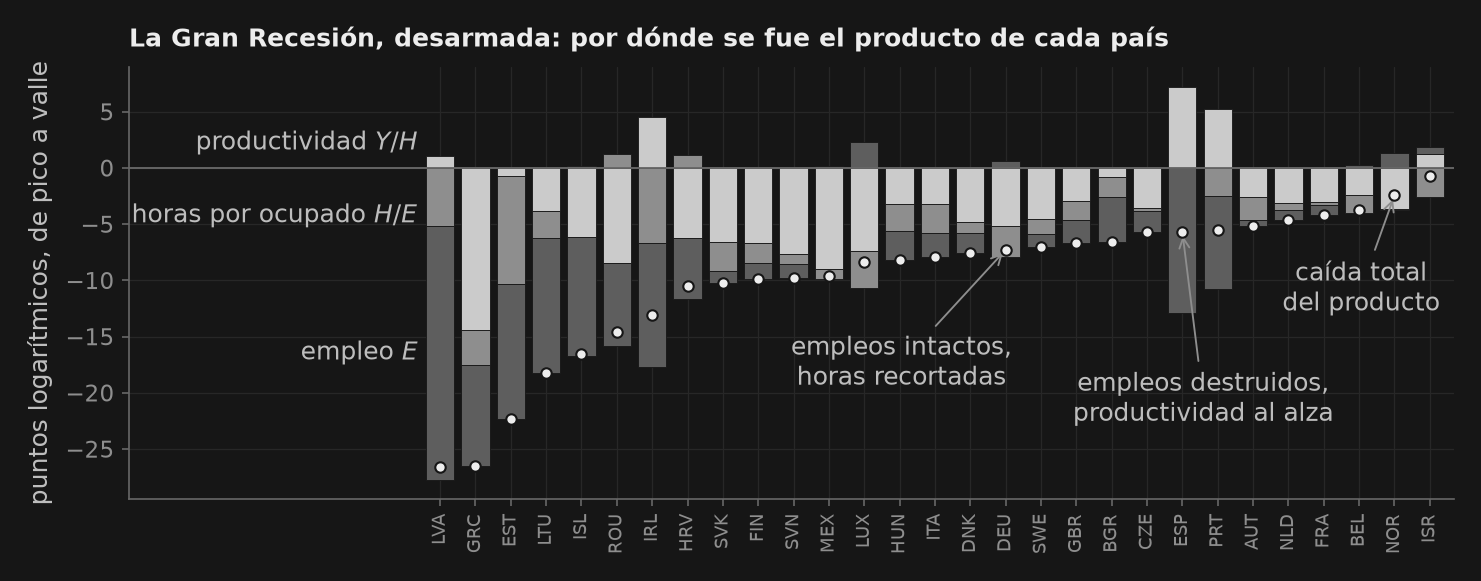

In [20]:
fig, ax = _nbstyle.figura(figsize="ancho")
r = rec.sort_values("d_y")
x = np.arange(len(r))
bp = np.zeros(len(r)); bn = np.zeros(len(r))
centros = {}                      # el centro de cada segmento en la primera barra
for clave, etiqueta, col in (("d_prod", "productividad $Y/H$", _nbstyle.BARRA_COLORES[0]),
                             ("d_hpe", "horas por ocupado $H/E$", _nbstyle.BARRA_COLORES[1]),
                             ("d_empleo", "empleo $E$", _nbstyle.BARRA_COLORES[2])):
    v = r[clave].to_numpy()
    base = np.where(v >= 0, bp, bn)
    ax.bar(x, v, bottom=base, color=col, edgecolor=_nbstyle.FONDO, lw=0.4)
    centros[etiqueta] = base[0] + v[0] / 2.0
    bp = bp + np.where(v >= 0, v, 0.0)
    bn = bn + np.where(v < 0, v, 0.0)
ax.plot(x, r["d_y"].to_numpy(), "o", color=_nbstyle.TINTA, mec=_nbstyle.FONDO, ms=5, zorder=5)
ax.axhline(0, color=_nbstyle.SPINE, lw=0.9)
ax.set_xticks(x); ax.set_xticklabels(r.index, rotation=90, fontsize=8.6)
ax.set_ylabel("puntos logarítmicos, de pico a valle")
ax.set_title("La Gran Recesión, desarmada: por dónde se fue el producto de cada país")
# Los nombres, junto a los segmentos de la primera barra (la caída mayor) y junto
# a su punto, en vez de en una leyenda.
ax.set_xlim(-8.8, len(r) - 0.3)
for (etiqueta, y), va in zip(centros.items(), ("bottom", "top", "center")):
    ax.annotate(etiqueta, xy=(x[0] - 0.4, y), xytext=(-4, 3 if va == "bottom" else -3 if va == "top" else 0),
                textcoords="offset points", ha="right", va=va, color=_nbstyle.TEXTO)
i = int(np.where(r.index == "NOR")[0][0]) if "NOR" in r.index else len(r) - 2
ax.annotate("caída total\ndel producto", xy=(x[i], r["d_y"].iloc[i]), xytext=(-16, -30),
            textcoords="offset points", ha="center", va="top", color=_nbstyle.TEXTO,
            arrowprops=_nbstyle.FLECHA)
for code, nota, dxy in (("DEU", "empleos intactos,\nhoras recortadas", (-50, -40)),
                        ("ESP", "empleos destruidos,\nproductividad al alza", (10, -66))):
    if code in r.index:
        i = int(np.where(r.index == code)[0][0])
        ax.annotate(nota, xy=(i, r.loc[code, "d_y"]), xytext=dxy,
                    textcoords="offset points", ha="center", va="top",
                    color=_nbstyle.TEXTO, arrowprops=_nbstyle.FLECHA)
plt.show()


### 5.1 La ley de Okun: la mezcla de márgenes de §4, comprimida en un número

La descomposición de arriba trata de *por dónde* se fue el ajuste. La ley de Okun es lo que el mundo exterior ve cuando se va por ahí: cuánto desempleo compra un déficit dado de producto. La estimamos en forma de brecha sobre los ciclos HP,

$$ \tilde{u}_t \;=\; \alpha + \beta\,\tilde{y}_t + \varepsilon_t, $$

y lo interesante no es la mediana — es la **dispersión**, y el hecho de que §4 ya nos había dicho qué la produciría.

### La Crítica de Lucas en el mercado laboral: Okun y Beveridge son formas reducidas
Esta divergencia institucional es una demostración empírica directa de la **Crítica de Lucas** (Lucas 1976):
El parámetro de Okun $\beta$ y la elasticidad de emparejamiento de Beveridge son **correlaciones estadísticas en forma reducida, no invariantes estructurales**.
Cuando un gobierno altera el marco regulatorio del mercado laboral —como Alemania perfeccionando el *Kurzarbeit* o España aprobando la reforma laboral de 2012 (que abarató el despido y facilitó la flexibilidad interna de jornadas)—, las decisiones empresariales de contratación, despido y horas se reoptimizan.
Si la autoridad económica asume que el $\beta$ de Okun es una ley natural inmutable al diseñar políticas de estabilización, las proyecciones fracasarán: en una economía con reducción de jornada subsidiada, $\beta$ será casi nulo (Alemania $-0.18$); en una economía con extrema dualidad de protección, $\beta$ será extraordinariamente empinado (España $-0.91$). La pendiente es una elección institucional.

**Una nota sobre los datos, porque es la razón de que esto sea una sección y no una nota al pie.** La tasa de paro que viaja en el bloque laboral de T01_B viene de la construcción de la curva de Beveridge, así que la limita la serie de *vacantes* y empieza en 2008–2010 para casi todos los países: diez años y un ciclo, que no alcanza para estimar nada. `oecd_urate_q.csv` trae el mismo concepto —la tasa armonizada de la OCDE, trimestral y desestacionalizada— desde la réplica que hace FRED de ella, hasta 1983 donde existe. Eso lleva al país mediano de 40 trimestres utilizables a 100, y es toda la diferencia entre un ejercicio flojo y un hecho.

Y hace algo que §1–§5 no podían: **devuelve a Estados Unidos y a Japón.** Una tasa de paro es una encuesta de hogares, y todos los países hacen una; las horas dentro de la contabilidad nacional son otra historia. Así que las dos economías sobre las que las cuentas no podían decirnos nada aparecen aquí, y EUA cae casi exactamente sobre el coeficiente del propio Okun.

In [21]:
PARO_LARGO = DATOS / "oecd_urate_q.csv"
if not _here(PARO_LARGO):
    raise RuntimeError(f"No está {PARO_LARGO.name}: viaja en data_curso/.")
u_largo = pd.read_csv(PARO_LARGO, parse_dates=["date"])


def okun(code, paro):
    """Okun en forma de brecha: ciclo HP de u sobre el ciclo HP del log del producto."""
    y = volumen("gdp", code).dropna()
    # u arranca antes que el PIB, así que la unión de índices hay que ordenarla:
    # sort=True es el default actual de concat, pero pandas 4 lo cambia.
    d = pd.concat([y.rename("y"), paro.rename("u")],
                  axis=1, sort=True).dropna().loc[:HASTA]
    if len(d) < MIN_Q:
        return None
    yc, _ = hp_filter(100.0 * np.log(d["y"]))
    uc, _ = hp_filter(d["u"])
    yc, uc = np.asarray(yc), np.asarray(uc)
    res_ok = ols(uc, add_constant(yc))
    out = {"code": code, "n": len(d), "desde": d.index[0].year,
           "beta": float(res_ok.params[1]), "se": float(res_ok.bse[1]),
           "R2": float(res_ok.rsquared)}
    if code in hechos.index:
        out["sd(E)/sd(Y)"] = float(hechos.loc[code, "sd(e)/sd(y)"])
    return out


ok = pd.DataFrame([r for r in (okun(c, g.set_index("date")["urate"])
                               for c, g in u_largo.groupby("code")
                               if c in HAY_PIB) if r]).set_index("code")
print(f"Ley de Okun, forma de brecha, {len(ok)} países, mediana de "
      f"{int(ok['n'].median())} trimestres:\n")
print(ok.sort_values("beta").round(2).to_string())

_extra = sorted(set(ok.index) - set(CODIGOS))
print(f"\nbeta es negativo en {int((ok['beta'] < 0).sum())} de {len(ok)} "
      f"países; mediana {ok['beta'].median():+.2f}, R2 mediano "
      f"{ok['R2'].median():.2f}.")
print(f"  España {ok.loc['ESP', 'beta']:+.2f} —un punto de producto cuesta casi "
      f"un punto de paro— frente a Japón {ok.loc['JPN', 'beta']:+.2f} y "
      f"Alemania {ok.loc['DEU', 'beta']:+.2f}.")
print(f"  Estados Unidos está en {ok.loc['USA', 'beta']:+.2f}, que es el "
      f"coeficiente del propio Okun de 1962 salvo redondeo.")
print(f"  {len(_extra)} de estos países NO están en el panel de productividad "
      f"({', '.join(_extra)}):\n  una tasa de paro es una encuesta de hogares y "
      f"todos hacen una; las horas dentro\n  de la contabilidad nacional son otra "
      f"historia.")

_j = ok.dropna(subset=["sd(E)/sd(Y)"])
print(f"\nY §4 anticipaba la dispersión: corr(beta, sd(E)/sd(Y)) = "
      f"{_j['beta'].corr(_j['sd(E)/sd(Y)']):.2f} sobre los {len(_j)} países con "
      f"ambas.\nLos países que ajustan por empleo convierten un déficit dado de "
      f"producto en más paro.\nEs *casi* una tautología — y el ejercicio 7 te pide "
      f"la parte que no lo es.")

assert (ok["beta"] < 0).all()
assert ok["n"].median() > 80

Ley de Okun, forma de brecha, 34 países, mediana de 100 trimestres:

        n  desde  beta    se    R2  sd(E)/sd(Y)
code                                           
ESP   100   1995 -0.91  0.05  0.80         1.22
USA   100   1995 -0.59  0.03  0.75          NaN
GRC    87   1998 -0.50  0.04  0.64         0.66
PRT   100   1995 -0.50  0.05  0.53         0.90
POL    92   1997 -0.50  0.10  0.21         1.16
EST    92   1997 -0.40  0.03  0.64         0.63
NLD    96   1996 -0.37  0.04  0.54         0.72
CAN   100   1995 -0.36  0.02  0.75          NaN
SVK    88   1998 -0.34  0.04  0.43         0.49
KOR   100   1995 -0.32  0.02  0.65          NaN
CHL    96   1996 -0.32  0.03  0.51          NaN
DNK   100   1995 -0.31  0.03  0.46         0.77
BEL   100   1995 -0.30  0.05  0.26         0.54
TUR    60   2005 -0.28  0.03  0.65          NaN
CZE   100   1995 -0.27  0.03  0.40         0.50
ITA    96   1996 -0.25  0.03  0.43         0.48
GBR   100   1995 -0.25  0.02  0.61         0.44
FRA   100   1995 -0

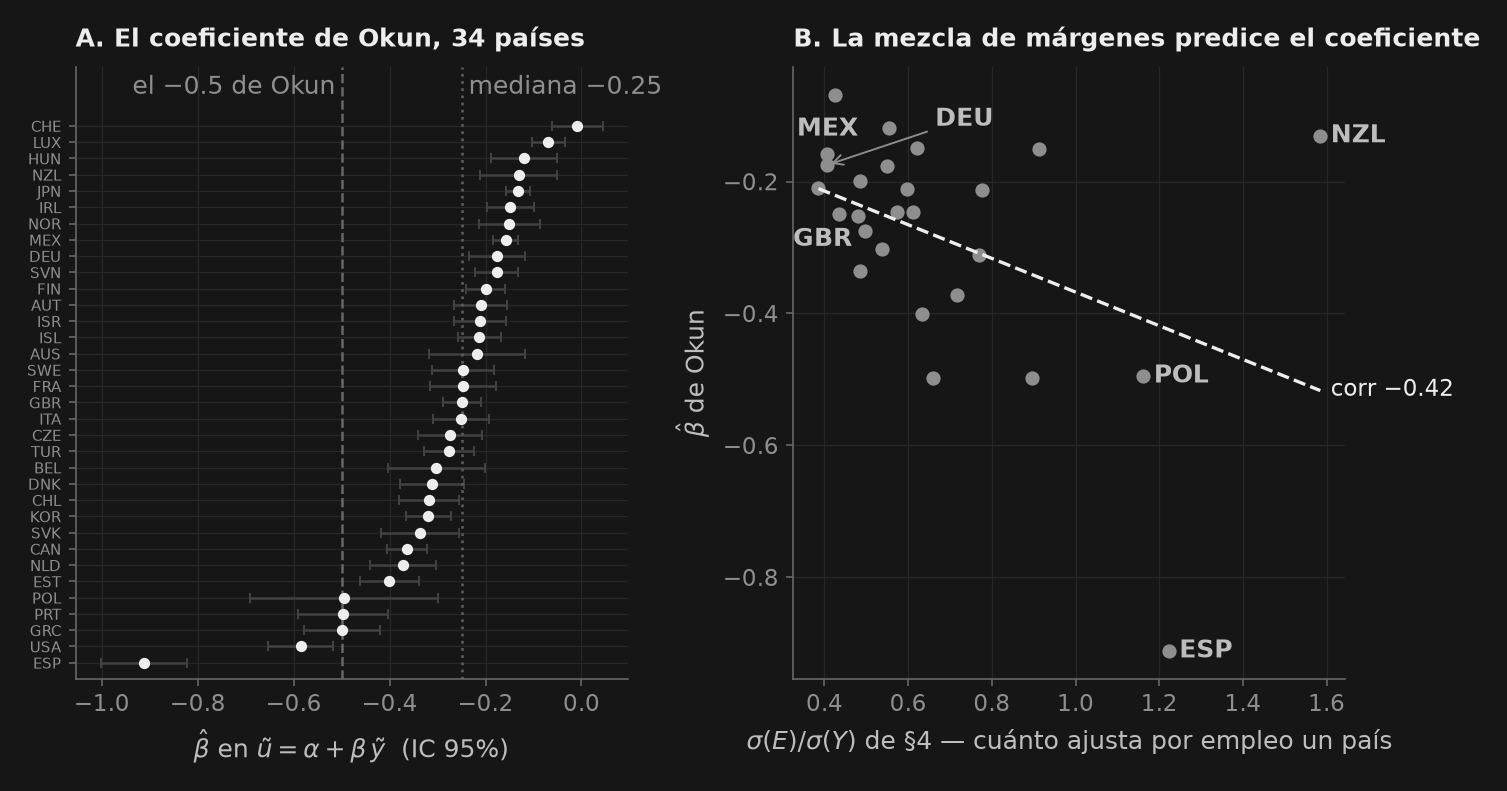

In [22]:
fig, (axO, axM) = _nbstyle.figura(1, 2, alto=True)

o = ok.sort_values("beta")
yy = np.arange(len(o))
axO.errorbar(o["beta"], yy, xerr=1.96 * o["se"], fmt="o", color=cols[0],
             ecolor=_nbstyle.gris("0.7"), elinewidth=1.2, capsize=2.5, ms=4.4, lw=0)
med = float(o["beta"].median())
axO.axvline(med, color=_nbstyle.gris("0.55"), ls=":", lw=1.3)
axO.axvline(-0.5, color=_nbstyle.SPINE, ls="--", lw=1.2)
axO.set_yticks(yy); axO.set_yticklabels(o.index, fontsize=7.4)
axO.set_ylim(-1, len(o) + 2.6)
axO.set_xlabel("$\\hat{\\beta}$ en $\\tilde{u} = \\alpha + \\beta\\,\\tilde{y}$  (IC 95%)")
axO.set_title(f"A. El coeficiente de Okun, {len(o)} países")
# Las dos rectas, nombradas en su extremo superior en vez de en una leyenda.
axO.annotate(f"mediana ${med:+.2f}$", xy=(med, len(o) + 0.6), xytext=(3, 0),
             textcoords="offset points", ha="left", va="bottom", color=_nbstyle.NOTA)
axO.annotate("el $-0.5$ de Okun", xy=(-0.5, len(o) + 0.6), xytext=(-3, 0),
             textcoords="offset points", ha="right", va="bottom", color=_nbstyle.NOTA)

j = ok.dropna(subset=["sd(E)/sd(Y)"])
axM.scatter(j["sd(E)/sd(Y)"], j["beta"], s=34, color=_nbstyle.NOTA, zorder=2)
# El rincón izquierdo está lleno: MEX va encima de su punto, GBR debajo del
# suyo y DEU -- encajonado entre ambos -- afuera, con una guía que lo señala.
for code, dxy, ha, va in (("ESP", (5, -3), "left", "baseline"),
                          ("DEU", (52, 16), "left", "bottom"),
                          ("NZL", (5, -3), "left", "baseline"),
                          ("MEX", (0, 6), "center", "bottom"),
                          ("GBR", (-8, -6), "center", "top"),
                          ("POL", (5, -3), "left", "baseline")):
    if code in j.index:
        axM.annotate(code, (j.loc[code, "sd(E)/sd(Y)"], j.loc[code, "beta"]),
                     xytext=dxy, textcoords="offset points", fontweight="bold",
                     ha=ha, va=va, color=_nbstyle.TEXTO,
                     arrowprops=_nbstyle.FLECHA if code == "DEU" else None)
_b = np.polyfit(j["sd(E)/sd(Y)"], j["beta"], 1)
_x = np.linspace(j["sd(E)/sd(Y)"].min(), j["sd(E)/sd(Y)"].max(), 20)
axM.plot(_x, np.polyval(_b, _x), color=cols[0], lw=1.6, ls="--",
         label=f"corr ${j['beta'].corr(j['sd(E)/sd(Y)']):.2f}$")
axM.set_xlabel("$\\sigma(E)/\\sigma(Y)$ de §4 — cuánto ajusta por empleo un país")
axM.set_ylabel("$\\hat{\\beta}$ de Okun")
axM.set_title("B. La mezcla de márgenes predice el coeficiente")
_nbstyle.etiquetar(axM, donde="fin")
plt.show()


### 5.2 La curva de Beveridge: cómo el mercado de trabajo entrega el paro que Okun cuenta

La ley de Okun cuenta el paro; no dice cómo se produce. El mecanismo es la curva de Beveridge: cuando cae el producto las empresas dejan de publicar vacantes, el emparejamiento se enlentece y el paro sube *a lo largo* de una curva decreciente en el plano $(u, v)$. T01_B §5.2 ajustó esa curva —$\log v = a + b\log u$ antes de 2020— y midió cuánto se desplazó tras 2021. Aquí no la volvemos a ajustar: le hacemos tres preguntas, y después le preguntamos qué dice sobre Okun.

**Cuánto se mueve.** La tensión $\theta = v/u$ es la variable de estado de todo modelo de búsqueda, y Shimer (2005) mostró que en Estados Unidos es unas veinte veces más volátil que la productividad cuando el modelo con salarios negociados a la Nash da un número cercano a uno. Ese es el *enigma de Shimer*, y aquí lo medimos como distribución, $\sigma(\tilde\theta)/\sigma(\tilde y)$ país por país: 11 veces en el país mediano, entre 6.7 (Irlanda) y 22.0 (Chequia), con Estados Unidos en 21.1. El número de Shimer es el extremo alto de una distribución cuyo centro está en 10–16, no un número aparte.

**Qué lado se mueve.** $\log\theta = \log v - \log u$, así que la elasticidad de la tensión al ciclo del producto se parte *exactamente* en la de las vacantes y la del paro, y Okun sólo ve la segunda. Un 1% de producto mueve $\theta$ un 6.8% en el país mediano: 4.5 son vacantes que desaparecen y 2.0 son parados que aparecen, dos tercios del movimiento por el lado de las vacantes. Son el lado elástico en 14 de 20 países; Estados Unidos es el simétrico, $+9.2$ y $-10.0$, que es el hecho de Shimer.

**Quién se mueve primero.** Si las vacantes caen antes de que suba el paro, $\mathrm{corr}(\tilde v_t, \tilde u_{t+k})$ alcanza su mínimo en $k>0$ y la trayectoria en el plano $(u,v)$ gira en sentido antihorario. La correlación mediana toca fondo en $k=+1$, y en 16 de 20 países la correlación con el paro del trimestre *siguiente* es más negativa que con el del anterior. Las vacantes van un trimestre por delante.

**Y lo que eso dice sobre Okun**, en la segunda celda. La pendiente $b$ de la curva no predice el coeficiente de Okun: corr $0.07$ sobre 16 países, porque $\beta$ depende de cuánto caen las vacantes *y* de la pendiente a la vez. Lo que sí hace la pendiente es ordenar la elasticidad del paro cuando se le da la de las vacantes —corr $0.67$— pero sobrepredice, $-5.5$ frente a un $-2.1$ observado, porque el mercado no recorre la curva punto a punto sino en bucle. El margen de empleo de §4 predice el Okun en puntos ($-0.73$ sobre los 14 países con las tres cosas, $-0.51$ sin España; §5.1 daba $-0.42$ sobre 26) y no la volatilidad de la tensión ($0.11$ sobre 18); la explicación tentadora —el nivel del paro— es España, no el panel, y queda como pregunta abierta con su test negativo. Y el bucle de 2020–23, que aquí sí es el objeto, fue el mismo bucle antihorario de siempre a otra escala: la tensión tocó 3.1 veces su mediana de 2010–19 en el país mediano, y los países que más la subieron no fueron los de Okun más empinado (corr $+0.36$, el signo equivocado para esa conjetura) sino los de vacantes más elásticas en tiempos normales ($0.53$).

**Una nota sobre los datos, porque otra vez decide la respuesta.** Las $u$ y $v$ son las del bloque laboral de T01_B, y las limita la serie de vacantes: empiezan en 2008–2010 para casi todos los países, y con el corte en 2019T4 exigir `MIN_Q = 40` deja **20 países** con producto y vacantes a la vez de los 30 que tienen $u$ y $v$: Chipre y Malta no tienen PIB en el bloque del gasto; Bélgica, Finlandia, Grecia, Croacia, Italia y Portugal tienen entre 16 y 28 trimestres, y Alemania y Francia se quedan a tres y cinco del mínimo. Son diez años y un ciclo por país, y un ciclo HP sobre 40 trimestres es una estimación floja: lo que sostiene la sección no es el coeficiente de ningún país sino la mediana y el recuento sobre los 20, con Estados Unidos (desde 2000) y el Reino Unido (desde 2001) como los dos contrastes largos. Los niveles de vacantes de JOLTS y de Eurostat no son comparables (T01_B lo advierte); aquí sólo entran ciclos, elasticidades y cocientes dentro de cada país, que son inmunes a la escala. Todo momento cíclico corta en 2019T4; 2020–23 aparece sólo en el último bloque, y sólo porque ahí el episodio es el objeto.

In [23]:
def _elasticidad(x, y):
    """OLS de y sobre x con constante: pendiente, error estándar."""
    res = ols(y, add_constant(x))
    return float(res.params[1]), float(res.bse[1])


ADELANTOS = range(-4, 5)


def beveridge_ciclo(code):
    """Ciclos HP de log theta, log v, log u de un país contra el ciclo del producto.

    Todo antes de 2020 (HASTA). Devuelve None si no hay MIN_Q trimestres con
    producto y vacantes a la vez; quedan fuera diez de los 30 países con u y v:
    Chipre y Malta no tienen PIB en el bloque del gasto, seis tienen entre 16 y
    28 trimestres, y Alemania (37) y Francia (35) se quedan a tres y cinco.
    """
    if code not in HAY_PIB:
        return None
    s = lab.loc[code][["urate", "vrate", "theta"]]
    d = pd.concat([volumen("gdp", code).rename("y"), s],
                  axis=1, sort=True).dropna()
    pre = d.loc[:HASTA]
    if len(pre) < MIN_Q:
        return None
    cy = {k: np.asarray(hp_filter(100.0 * np.log(pre[k]))[0])
          for k in ("y", "theta", "vrate", "urate")}
    out = {"code": code, "n": len(pre), "desde": pre.index[0].year,
           "sd(theta)/sd(y)": float(cy["theta"].std(ddof=1) / cy["y"].std(ddof=1)),
           "corr(theta,y)": float(np.corrcoef(cy["y"], cy["theta"])[0, 1])}
    for k, lbl in (("theta", "theta"), ("vrate", "v"), ("urate", "u")):
        out[f"el({lbl})"], out[f"se({lbl})"] = _elasticidad(cy["y"], cy[k])
    # La pendiente de Beveridge tal como la ajustó T01_B §5.2: log v sobre
    # log u en niveles, antes de 2020.
    out["b"], _ = _elasticidad(np.log(pre["urate"].to_numpy()),
                               np.log(pre["vrate"].to_numpy()))
    # Timing: corr(v_t, u_{t+k}). Si el mínimo cae en k > 0, las vacantes
    # se mueven ANTES que el paro.
    v, u = pd.Series(cy["vrate"]), pd.Series(cy["urate"])
    xc = {k: float(v.corr(u.shift(-k))) for k in ADELANTOS}
    out["adelanto de v"] = int(min(xc, key=xc.get))
    out.update({f"xc{k:+d}": xc[k] for k in ADELANTOS})
    # El episodio 2020-23, que aquí sí es el objeto: pico de la tensión en
    # 2021-23 contra su mediana de 2010-19, y el desplazamiento de T01_B.
    post, ref = d.loc["2021-01-01":"2023-12-31"], d.loc["2010-01-01":HASTA]
    if len(post) >= 8:
        out["theta pico 21-23 / med 10-19"] = float(post["theta"].max()
                                                    / ref["theta"].median())
        out["u min 21-23 / med 10-19"] = float(post["urate"].min()
                                               / ref["urate"].median())
        a = np.log(pre["vrate"]).mean() - out["b"] * np.log(pre["urate"]).mean()
        out["desplaz"] = float((np.log(post["vrate"])
                                - (a + out["b"] * np.log(post["urate"]))).mean())
    return out


bv = pd.DataFrame([r for r in (beveridge_ciclo(c) for c in
                               sorted(set(lab.index.get_level_values("code"))))
                   if r]).set_index("code")
XC = bv[[f"xc{k:+d}" for k in ADELANTOS]]
XC.columns = list(ADELANTOS)

_fuera = {}
_con_uv = set(lab[["urate", "vrate"]].dropna().index.get_level_values("code"))
for c in sorted(_con_uv - set(bv.index)):
    if c not in HAY_PIB:
        _fuera[c] = "sin PIB"
    else:
        _fuera[c] = str(len(pd.concat([volumen("gdp", c).rename("y"),
                                        lab.loc[c][["urate", "vrate"]]],
                                       axis=1, sort=True).dropna().loc[:HASTA]))

print(f"Tensión theta = v/u contra el producto, ciclos HP, {len(bv)} países, "
      f"{int(bv['n'].min())}-{int(bv['n'].max())} trimestres hasta "
      f"{HASTA[:4]}T4 (mediana {int(bv['n'].median())}).")
print(f"Fuera por debajo de MIN_Q = {MIN_Q}: "
      + ", ".join(f"{c} ({v})" for c, v in _fuera.items()) + ".\n")
print(bv[["n", "desde", "sd(theta)/sd(y)", "corr(theta,y)", "el(theta)",
          "se(theta)", "el(v)", "el(u)", "b", "adelanto de v"]]
      .sort_values("el(theta)", ascending=False).round(2).to_string())

r = bv["sd(theta)/sd(y)"]
print(f"\n(a) El enigma de Shimer, como distribución. La tensión es "
      f"{r.median():.0f}x más volátil que el producto\n    en el país mediano "
      f"(rango intercuartil {r.quantile(.25):.0f}-{r.quantile(.75):.0f}x; "
      f"mínimo {r.min():.1f}x {r.idxmin()}, máximo {r.max():.1f}x {r.idxmax()}; "
      f"Estados Unidos {r['USA']:.1f}x).")
t = bv["el(theta)"] / bv["se(theta)"]
print(f"    Un 1% de producto mueve theta un {bv['el(theta)'].median():.1f}% "
      f"(elasticidad mediana); positiva en "
      f"{int((bv['el(theta)'] > 0).sum())} de {len(bv)} países y con t > 2 en "
      f"{int((t > 2).sum())}.\n    Estados Unidos: {bv.loc['USA', 'el(theta)']:.1f} "
      f"sobre {int(bv.loc['USA', 'n'])} trimestres. La excepción es Noruega "
      f"({bv.loc['NOR', 'el(theta)']:+.1f}, corr {bv.loc['NOR', 'corr(theta,y)']:+.2f}).")

lado_v = bv["el(v)"] > -bv["el(u)"]
cuota_v = (bv["el(v)"] / bv["el(theta)"]).median()
print(f"\n(b) Qué lado se mueve. el(theta) = el(v) - el(u): vacantes "
      f"{bv['el(v)'].median():+.1f} frente a paro {bv['el(u)'].median():+.1f}; "
      f"la cuota mediana de las vacantes en el(theta) es {cuota_v:.2f}.\n"
      f"    Las vacantes son el lado elástico en {int(lado_v.sum())} de {len(bv)} "
      f"países; el paro sólo en {', '.join(sorted(bv.index[~lado_v]))}.\n"
      f"    Estados Unidos es simétrico ({bv.loc['USA', 'el(v)']:+.1f} y "
      f"{bv.loc['USA', 'el(u)']:+.1f}), que es el hecho de Shimer (2005).")

xc_med = XC.median()
k_med = int(xc_med.idxmin())
asim = bv["xc+1"] - bv["xc-1"]
print(f"\n(c) Quién se mueve primero. corr(v_t, u_(t+k)) mediana: "
      + ", ".join(f"k={k:+d}: {xc_med[k]:+.2f}" for k in (-2, -1, 0, 1, 2))
      + f".\n    El mínimo cae en k = {k_med:+d}: las vacantes van un trimestre por "
      f"delante del paro. Adelanto modal {int(bv['adelanto de v'].mode()[0])}, "
      f"mediano {bv['adelanto de v'].median():.0f};\n    corr(v_t, u_(t+1)) es más "
      f"negativa que corr(v_t, u_(t-1)) en {int((asim < 0).sum())} de {len(bv)} "
      f"países (no en {', '.join(sorted(bv.index[asim >= 0]))}).\n    Con v por "
      f"delante, el bucle en el plano (u, v) gira en sentido antihorario: v cae, "
      f"u sube, v se recupera, u baja.")

assert 8 < r.median() < 14
assert (bv["el(theta)"] > 0).sum() >= len(bv) - 2
assert lado_v.sum() >= 13 and 0.55 < cuota_v < 0.75
assert k_med == 1 and (asim < 0).sum() >= 14          # un trimestre, no «alguno»
assert len(bv) == 20 and len(_fuera) == 10

Tensión theta = v/u contra el producto, ciclos HP, 20 países, 40-77 trimestres hasta 2019T4 (mediana 48).
Fuera por debajo de MIN_Q = 40: BEL (28), CYP (sin PIB), DEU (37), FIN (28), FRA (35), GRC (24), HRV (28), ITA (16), MLT (sin PIB), PRT (24).

       n  desde  sd(theta)/sd(y)  corr(theta,y)  el(theta)  se(theta)  el(v)  el(u)     b  adelanto de v
code                                                                                                    
USA   77   2000            21.12           0.91      19.25       1.00   9.21 -10.04 -0.69              0
CZE   48   2008            21.96           0.69      15.05       2.36   9.88  -5.18 -1.57              0
NLD   48   2008            15.34           0.87      13.28       1.13   9.96  -3.32 -1.25              2
AUT   40   2010            14.72           0.76      11.16       1.56   7.18  -3.98 -0.75              4
EST   48   2008            10.63           0.94       9.96       0.55   4.85  -5.11 -0.58              0
GBR   75   2001 

In [24]:
# ¿Qué dice todo esto sobre Okun? Cruzamos con 'ok' (§5.1) y 'hechos' (§4).
j = bv.join(ok[["beta"]], how="inner")
jn = j[j["b"] < 0]
print(f"(d) La pendiente de Beveridge y el coeficiente de Okun, {len(j)} países "
      f"con ambos (Okun sobre {int(ok.loc[j.index, 'n'].median())} trimestres):")
print(f"    corr(beta, b) = {j['beta'].corr(j['b']):+.2f}. La pendiente NO predice "
      f"a Okun.\n    corr(beta, 1/|b|) = {jn['beta'].corr(1 / jn['b'].abs()):+.2f} "
      f"sobre los {len(jn)} con b < 0 — pero sin España es "
      f"{jn.drop('ESP')['beta'].corr(1 / jn.drop('ESP')['b'].abs()):+.2f}: "
      f"un país, no un hecho.")
c_ok = j["beta"].corr(j["el(u)"])
bn = bv[bv["b"] < 0]
pred = bn["el(v)"] / bn["b"]
print(f"    Lo que sí hace la pendiente es ordenar cuánto paro compra una caída "
      f"de vacantes: si la economía\n    se moviera a lo largo de la curva, "
      f"el(u) = el(v)/b. corr(el(u), el(v)/b) = {bn['el(u)'].corr(pred):+.2f} "
      f"sobre {len(bn)} países,\n    pero la predicción es {pred.median():+.1f} "
      f"frente a un el(u) mediano de {bn['el(u)'].median():+.1f}: el paro se mueve "
      f"menos de la mitad de lo que\n    dice la pendiente, porque la curva se "
      f"recorre con un trimestre de retraso y en bucle, no punto a punto.")
print(f"    Y el Okun en puntos de §5.1 y la elasticidad del paro de aquí se "
      f"parecen sólo a medias: corr(beta, el(u)) = {c_ok:+.2f}.")

h = bv.join(hechos[["sd(e)/sd(y)"]], how="inner")
u_medio = pd.Series({c: float(lab.loc[c]["urate"].dropna().loc[:HASTA].mean())
                     for c in h.index})
hb = h.join(ok[["beta"]], how="inner")
_sin = hb.drop("ESP")
print(f"\n(e) ¿Predice el margen de empleo de §4 la volatilidad de la tensión? "
      f"No: corr(sd(E)/sd(Y), sd(theta)/sd(y)) = "
      f"{h['sd(e)/sd(y)'].corr(h['sd(theta)/sd(y)']):+.2f}\n    sobre {len(h)} "
      f"países, y tampoco la elasticidad del paro en logs "
      f"({h['sd(e)/sd(y)'].corr(h['el(u)']):+.2f}). Lo que predice es el Okun "
      f"en PUNTOS:\n    corr(sd(E)/sd(Y), beta) = "
      f"{hb['sd(e)/sd(y)'].corr(hb['beta']):+.2f} sobre {len(hb)} países, y "
      f"{_sin['sd(e)/sd(y)'].corr(_sin['beta']):+.2f} sin España: eso sí es un hecho.")
print(f"    La explicación tentadora es el nivel del paro —corr(u medio, beta) = "
      f"{u_medio.loc[hb.index].corr(hb['beta']):+.2f}—, pero sin España cae a "
      f"{u_medio.loc[_sin.index].corr(_sin['beta']):+.2f}.\n    Un país con "
      f"{u_medio['ESP']:.0f}% de paro convierte la misma caída proporcional de su "
      f"mercado en muchos más puntos, y ese país es\n    uno: España. Por qué §4 "
      f"predice los puntos y no la proporción queda como pregunta abierta con su "
      f"test negativo.")

post = bv.dropna(subset=["desplaz"])
pk = post["theta pico 21-23 / med 10-19"]
jp = post.join(ok[["beta"]], how="inner")
print(f"\n(f) El bucle de 2020-23, que aquí sí es el objeto ({len(post)} países "
      f"con datos hasta 2023; GBR no).\n    La tensión tocó un máximo de "
      f"{pk.median():.1f}x su mediana de 2010-19 en el país mediano "
      f"(mínimo {pk.min():.1f}x {pk.idxmin()}, máximo {pk.max():.1f}x {pk.idxmax()}),\n"
      f"    más del doble en {int((pk > 2).sum())} de {len(post)}, y el paro cayó "
      f"por debajo de su mediana de 2010-19 en {int((post['u min 21-23 / med 10-19'] < 1).sum())} "
      f"de {len(post)}.\n    Desplazamiento hacia afuera en "
      f"{int((post['desplaz'] > 0).sum())} de {len(post)}, mediana "
      f"{post['desplaz'].median():+.2f} log-puntos (T01_B §5.2).")
print(f"    ¿Desplazaron más la curva los países con Okun más empinado? No: "
      f"corr(beta, desplaz) = {jp['beta'].corr(jp['desplaz']):+.2f} sobre "
      f"{len(jp)} —el signo\n    contrario a la conjetura— y corr(beta, pico de "
      f"theta) = {jp['beta'].corr(jp[pk.name]):+.2f}. Lo que sí ordena el pico "
      f"es la elasticidad de las\n    vacantes en tiempos normales: corr(el(v), "
      f"pico de theta) = {post['el(v)'].corr(pk):+.2f}. Queda como pregunta "
      f"abierta con su test negativo.")

assert abs(j["beta"].corr(j["b"])) < 0.3
assert bn["el(u)"].corr(pred) > 0.5
assert abs(h["sd(e)/sd(y)"].corr(h["sd(theta)/sd(y)"])) < 0.4
assert hb["sd(e)/sd(y)"].corr(hb["beta"]) < -0.5
assert _sin["sd(e)/sd(y)"].corr(_sin["beta"]) < -0.4
assert pk.median() > 2 and (post["u min 21-23 / med 10-19"] < 1).all()
assert jp["beta"].corr(jp["desplaz"]) > 0 and post["el(v)"].corr(pk) > 0.4   # el signo equivocado, y el que sí ordena

(d) La pendiente de Beveridge y el coeficiente de Okun, 16 países con ambos (Okun sobre 100 trimestres):
    corr(beta, b) = +0.07. La pendiente NO predice a Okun.
    corr(beta, 1/|b|) = -0.68 sobre los 15 con b < 0 — pero sin España es -0.18: un país, no un hecho.
    Lo que sí hace la pendiente es ordenar cuánto paro compra una caída de vacantes: si la economía
    se moviera a lo largo de la curva, el(u) = el(v)/b. corr(el(u), el(v)/b) = +0.67 sobre 19 países,
    pero la predicción es -5.5 frente a un el(u) mediano de -2.1: el paro se mueve menos de la mitad de lo que
    dice la pendiente, porque la curva se recorre con un trimestre de retraso y en bucle, no punto a punto.
    Y el Okun en puntos de §5.1 y la elasticidad del paro de aquí se parecen sólo a medias: corr(beta, el(u)) = +0.58.

(e) ¿Predice el margen de empleo de §4 la volatilidad de la tensión? No: corr(sd(E)/sd(Y), sd(theta)/sd(y)) = +0.11
    sobre 18 países, y tampoco la elasticidad del paro en logs (-0.03). Lo q

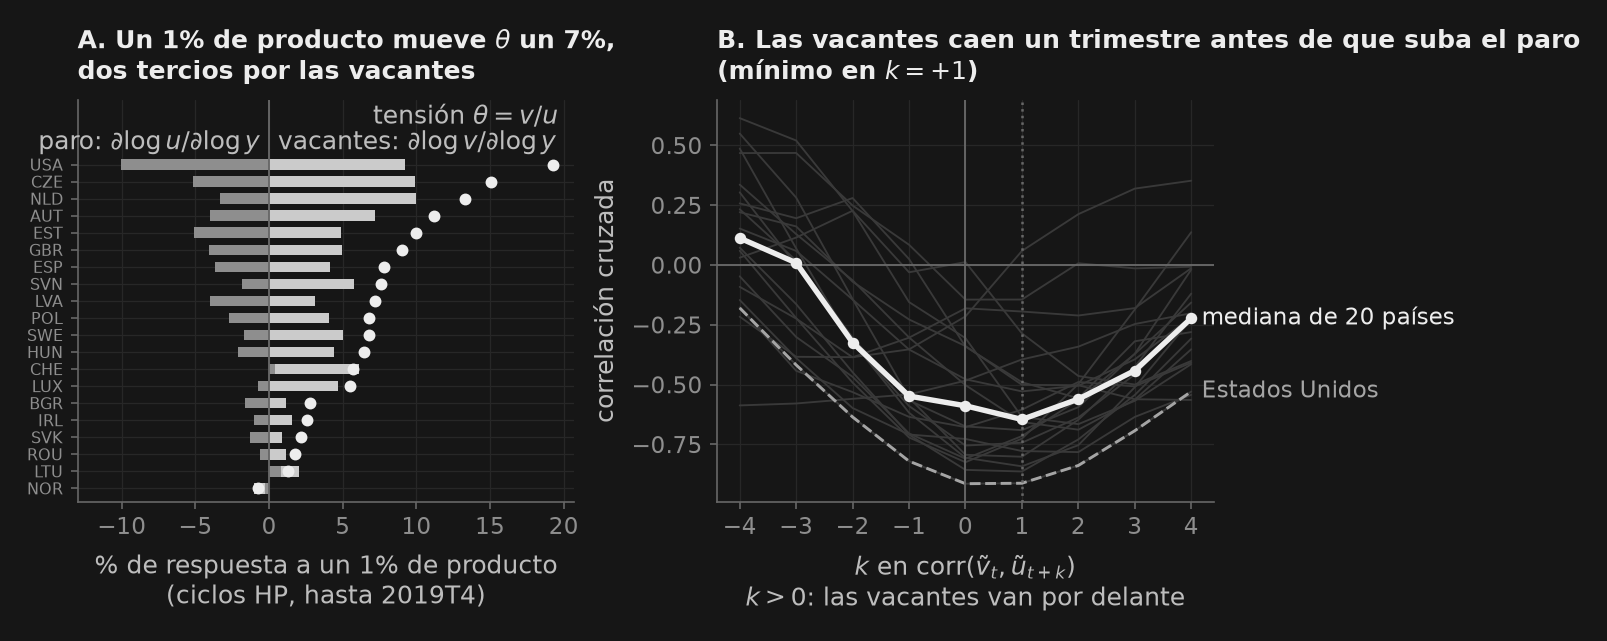

In [25]:
fig, (axE, axX) = _nbstyle.figura(1, 2)

o = bv.sort_values("el(theta)")
yy = np.arange(len(o))
axE.barh(yy, o["el(v)"], color=_nbstyle.BARRA_COLORES[0], height=0.62)
axE.barh(yy, o["el(u)"], color=_nbstyle.BARRA_COLORES[1], height=0.62)
axE.scatter(o["el(theta)"], yy, s=22, color=_nbstyle.TINTA, zorder=4)
axE.axvline(0, color=_nbstyle.SPINE, lw=0.9)
axE.set_axisbelow(True)
axE.set_yticks(yy); axE.set_yticklabels(o.index, fontsize=7.6)
axE.set_ylim(-0.8, len(o) + 2.8)
axE.set_xlim(left=-13.0)
axE.set_xlabel("% de respuesta a un 1% de producto\n(ciclos HP, hasta 2019T4)")
axE.set_title(f"A. Un 1% de producto mueve $\\theta$ un "
              f"{bv['el(theta)'].median():.0f}%,\ndos tercios por las vacantes")
# Los tres nombres sobre la fila de arriba, cada uno encima de lo que nombra,
# en vez de en una leyenda.
arriba = yy[-1] + 0.55
axE.annotate("paro: $\\partial \\log u / \\partial \\log y$", xy=(-0.6, arriba),
             ha="right", va="bottom", color=_nbstyle.TEXTO)
axE.annotate("vacantes: $\\partial \\log v / \\partial \\log y$", xy=(0.6, arriba),
             ha="left", va="bottom", color=_nbstyle.TEXTO)
axE.annotate("tensión $\\theta = v/u$", xy=(o["el(theta)"].iloc[-1], arriba + 1.5),
             xytext=(3, 0), textcoords="offset points", ha="right", va="bottom",
             color=_nbstyle.TEXTO)

for code in XC.index:
    axX.plot(list(ADELANTOS), XC.loc[code], color=_nbstyle.gris("0.75"), lw=0.9, ls="-", zorder=1)
axX.plot(list(ADELANTOS), xc_med, color=cols[0], lw=2.6, ls="-", marker="o", ms=4.5,
         zorder=3, label=f"mediana de {len(XC)} países")
axX.plot(list(ADELANTOS), XC.loc["USA"], color=_nbstyle.S2["color"], lw=1.4, ls="--",
         zorder=2, label="Estados Unidos")
axX.axvline(0, color=_nbstyle.SPINE, lw=0.9); axX.axhline(0, color=_nbstyle.SPINE, lw=0.9)
axX.axvline(k_med, color=_nbstyle.SPINE, ls=":", lw=1.2)
axX.set_xticks(list(ADELANTOS))
axX.set_xlabel("$k$ en $\\mathrm{corr}(\\tilde v_t, \\tilde u_{t+k})$\n"
               "$k>0$: las vacantes van por delante")
axX.set_ylabel("correlación cruzada")
axX.set_title(f"B. Las vacantes caen un trimestre antes de que suba el paro\n"
              f"(mínimo en $k={k_med:+d}$)")
_nbstyle.etiquetar(axX, donde="fin")
plt.show()


### 5.3 La curva de Phillips: lo que ese paro compra en precios

§5.1 dijo cuánto paro compra un déficit de producto y §5.2 cómo lo entrega el mercado. Esta sección pregunta qué compra ese paro en precios, y la respuesta tiene dos partes que conviene no mezclar: la curva de Phillips que traen los libros y la que hay en los datos de 1995–2019.

La de los libros es la aceleracionista, con expectativas adaptativas: $\pi_t - \bar\pi_{t-1..t-4} = \alpha + \kappa\,\tilde u_t$, donde $\bar\pi$ es la media de los cuatro trimestres anteriores y $\tilde u_t$ es **el mismo ciclo HP del paro que estimó Okun en §5.1** —la celda lo comprueba reestimando $\beta$ con él hasta el último bit—. Sobre 34 países y 1995T1–2019T4 esa curva no está: $\kappa<0$ en 14 de 34, mediana $+0.10$. La culpa no es del paro sino del término de expectativas. Si en vez de imponer que la inflación pasada entre con coeficiente 1 lo estimamos, $\pi_t = \alpha + \rho\,\bar\pi + \kappa\,\tilde u_t$, $\rho$ tiene mediana $0.36$, máximo $0.77$ (Hungría) y es menor que 1 al 5% en 33 de 34 países. Eso es lo que significa «expectativas ancladas» escrito como un número, y con $\rho$ tan lejos de 1 la curva que hay que mirar es la de **nivel**, $\pi_t = \alpha + \kappa\,\tilde u_t$: $\kappa<0$ en 30 de 34, mediana $-0.55$, negativa al 5% en 10. Japón ($-1.94$) y Australia ($-1.47$) son empinadas y precisas; Estados Unidos ($-0.21$) y Alemania ($-0.38$) son planas; México es la más empinada ($-2.74$) con el error estándar más grande ($1.76$), y Hungría, Portugal, Noruega y Suiza tienen el signo equivocado. Un punto de paro cíclico vale medio punto de inflación en el país mediano, y casi nada en Estados Unidos ni en el Reino Unido de Phillips ($-0.24$).

**Una nota sobre los datos, porque decide dos cosas.** La inflación sale de las *mismas* cuentas que todo lo demás en esta lección: $\pi_t = 400\,\Delta\log P_t$ con $P$ el deflactor implícito del consumo de los hogares de `gasto()`, desestacionalizado y encadenado. Eso **no es el IPC**: el IPC es una canasta fija de compras de bolsillo, mensual, en muchos países sin desestacionalizar, con otro tratamiento de la vivienda en propiedad, y es lo que los bancos centrales tienen por objetivo; el deflactor es lo que las cuentas dicen que pagaron los hogares por lo que las cuentas dicen que consumieron. En Estados Unidos las dos series interanuales correlacionan $0.97$ y sus medias son $2.2$ y $1.8$ —la brecha de sustitución de siempre—, y el ejercicio 12 te pide medir cuánto mueve eso a $\kappa$. La segunda decisión es una regla para la inflación alta: un trimestre con $|\pi_t|>25$ anualizado no es un ciclo económico, se trata como ausente y arrastra a los cuatro siguientes porque $\bar\pi$ los usa. Quita 32 trimestres-país: los cuatro del Tequila mexicano (1995T2–1996T1), 21 turcos, dos en Hungría y dos en Islandia, uno en Estonia, Polonia y Eslovaquia. Veinte de los 21 turcos —y los de Estonia y Polonia y uno de los húngaros— caen antes de que exista la tasa de paro del país; el turco que queda, 2018T4, la crisis de la lira, le cuesta a Turquía cinco trimestres, de 60 a 55, porque arrastra a los cuatro siguientes. A la estimación la regla le cuesta 27 trimestres-país en total, y decide el $\kappa$ de México ($-1.36$ sin ella), no la mediana del panel, que no se mueve.

Tres preguntas más, en la segunda celda. **¿Se aplanó?** La misma curva de nivel en 1995–2007 y en 2010–2019 sobre 31 países: la mediana pasa de $-0.55$ a $-0.19$ y el cambio mediano dentro de cada país es $+0.20$, pero se aplanan 18 de 31 y se empinan 13 —Japón, Luxemburgo y Alemania están más empinadas después—, y sin la regla de los 25 puntos el conteo es 16 de 31. La mediana se aplana; el panel no lo hace de forma unánime, y queda como pregunta abierta con su test. **¿Cuánto cuesta desinflar?** Okun y Phillips juntos dan $\pi - \pi^* = \kappa\beta\,\tilde y$, así que un punto-año de inflación por debajo del ancla cuesta $1/(\kappa\beta)$ puntos-año de brecha del producto: mediana 5.3 sobre los 30 países con $\kappa<0$, España 2.6 —el Okun más empinado del panel—, Estados Unidos 8.0, Luxemburgo 47.9. El producto de las dos medianas da 6.5 y no 5.3: la mediana conmuta con $1/x$, que es monótona, pero no con el producto de dos variables distintas, y $\mathrm{corr}(\kappa,\beta)=-0.37$ dice que quien tiene el Okun empinado no tiene la Phillips empinada. (La ratio aceleracionista de los libros, $1/(4\kappa\beta)$ puntos-año por punto *permanente*, sólo existe para los 14 países con $\kappa<0$ en esa forma, y el $\rho$ de arriba dice que ese modelo no es el de estos datos; el ejercicio 13 te pide el factor que le falta.) **¿Y 2021–2024?** Está fuera de la ventana de estimación a propósito: el episodio es el objeto, no un segundo momento. Para los 28 países con $\theta = v/u$ del bloque laboral (27 llegan a 2021–24; el Reino Unido no), en desviaciones de la media de cada país en cada ventana, la inflación de 2021–24 responde a la tensión del mercado de trabajo y responde más a $\theta$ que a $u$: $+1.30$ puntos por desviación típica de $\log\theta$ frente a $-0.80$ por la de $u$, $R^2$ de 0.071 frente a 0.027, con $\theta>1$ en el 16% de los trimestres frente al 2% de 2010–19 (Benigno y Eggertsson 2023). En 2010–19 ninguno de los dos tenía pendiente. Pero la pendiente no es lo grande: con sólo efecto fijo de país, una constante de 2021–24 añade 3.2 puntos de inflación que $\theta$ no explica, y 3.4 que $u$ no explica. La curva se empinó en $\theta$ *y además* se desplazó, y el desplazamiento es la mayor parte del episodio. Con el deflactor del PIB en vez del del consumo, la curva de nivel sobrevive ($\kappa<0$ en 29 de 34, mediana $-0.48$) y la ratio de sacrificio mediana pasa de 5.3 a 5.7; la aceleracionista pasa de 14 a 18 de 34 con mediana $-0.04$ —en torno a la mitad con uno u otro deflactor, que no es una curva— y el aplanamiento se mueve un país, 19 de 31. Lo que se mueve con el deflactor es lo que ya estaba sobre el filo del 50%; la regresión de 2021–24 no se repite con él.

**Y los dos países, en una sola figura.** La última celda de la sección junta las tres curvas para Estados Unidos y España; en cada nube los primeros trimestres van en gris tenue y los últimos en tinta plena, para que se lea como una trayectoria, y el bucle de 2020–23 va punteado porque es el episodio, no el ciclo.

In [26]:
TOPE_PI = 25.0     # |pi| por encima de esto (anualizado) no es un ciclo: se trata como ausente
BW_NW = 4          # rezagos de Newey-West: la media de cuatro rezagos deja un MA(4) en el error


def inflacion(code, defl="cons_hh_defl", tope=TOPE_PI):
    """pi_t = 400·Δlog P_t del deflactor de las cuentas, anualizado; |pi| > tope queda ausente."""
    P = gas.loc[code, defl].dropna()
    pi = 400.0 * np.log(P).diff()
    return pi.where(pi.abs() <= tope) if tope else pi


def ciclo_paro(code, paro):
    """El mismo ũ que okun(): ciclo HP de u sobre la muestra conjunta con el PIB, hasta HASTA."""
    y = volumen("gdp", code).dropna()
    d = pd.concat([y.rename("y"), paro.rename("u")],
                  axis=1, sort=True).dropna().loc[:HASTA]
    uc, _ = hp_filter(d["u"])
    return pd.Series(np.asarray(uc), index=d.index)


def ols_nw(y, X, bw=BW_NW):
    res = ols(y, X, cov_type="HAC", cov_kwds={"maxlags": bw})
    return np.asarray(res.params), np.asarray(res.bse), float(res.rsquared)


def muestra_phillips(code, paro, defl="cons_hh_defl", lo=None, hi=HASTA, tope=TOPE_PI):
    """pi, su media de cuatro rezagos y el ũ de §5.1 sobre la MISMA muestra:
    donde falta pi_e falta la observación, en las tres formas por igual."""
    pi = inflacion(code, defl, tope)
    pi_e = pi.shift(1).rolling(4).mean()
    return pd.concat([pi.rename("pi"), pi_e.rename("pi_e"),
                      ciclo_paro(code, paro).rename("u")],
                     axis=1, sort=True).dropna().loc[lo:hi]


def phillips(code, paro, forma="nivel", defl="cons_hh_defl", lo=None, hi=HASTA,
             minq=MIN_Q, tope=TOPE_PI):
    """Tres formas de la misma curva sobre el mismo ũ:
    acelera : pi_t - media(pi_{t-1..t-4}) = a + k·ũ_t          (expectativas adaptativas)
    anidada : pi_t = a + rho·media(pi_{t-1..t-4}) + k·ũ_t      (rho = 1 recupera la anterior)
    nivel   : pi_t = a + k·ũ_t                                  (expectativas ancladas: rho = 0)
    """
    d = muestra_phillips(code, paro, defl, lo, hi, tope)
    if len(d) < minq:
        return None
    y = (d["pi"] - d["pi_e"] if forma == "acelera" else d["pi"]).to_numpy()
    X = [np.ones(len(d)), d["u"].to_numpy()]
    if forma == "anidada":
        X.append(d["pi_e"].to_numpy())
    b, se, R2 = ols_nw(y, np.column_stack(X))
    out = {"code": code, "n": len(d), "desde": d.index[0].year,
           "kappa": float(b[1]), "se": float(se[1]), "R2": R2}
    if forma == "anidada":
        out["rho"], out["se(rho)"] = float(b[2]), float(se[2])
    return out


PARO = {c: g.set_index("date")["urate"] for c, g in u_largo.groupby("code")
        if c in ok.index}


def tabla_phillips(forma, **kw):
    return pd.DataFrame([r for r in (phillips(c, PARO[c], forma, **kw)
                                     for c in ok.index) if r]).set_index("code")


# El ũ de aquí es el de §5.1: reestimar Okun con él devuelve su beta al último bit.
_d = pd.concat([volumen("gdp", "ESP").dropna().rename("y"), PARO["ESP"].rename("u")],
               axis=1, sort=True).dropna().loc[:HASTA]
_yc, _ = hp_filter(100.0 * np.log(_d["y"]))
assert abs(np.polyfit(np.asarray(_yc), ciclo_paro("ESP", PARO["ESP"]).to_numpy(), 1)[0]
           - ok.loc["ESP", "beta"]) < 1e-9

acel = tabla_phillips("acelera")
anid = tabla_phillips("anidada")
niv = tabla_phillips("nivel")
ph = niv.join(acel[["kappa"]].rename(columns={"kappa": "kappa(acel)"})) \
        .join(anid[["rho", "se(rho)"]])
ph["t"] = ph["kappa"] / ph["se"]
print(f"Curva de Phillips sobre el ũ de §5.1, {len(ph)} países, 1995T1-{HASTA[:4]}T4, "
      f"deflactor del consumo de los hogares,\nerrores estándar Newey-West({BW_NW}); "
      f"kappa = pendiente sobre ũ en la forma de NIVEL, kappa(acel) en la aceleracionista, "
      f"rho = peso de pi_{{t-1..t-4}} en la anidada:\n")
print(ph.sort_values("kappa").round(2).to_string())

n_acel = int((acel["kappa"] < 0).sum())
print(f"\n1. La curva aceleracionista, tal como la escriben los libros, no está: "
      f"kappa < 0 en {n_acel} de {len(acel)} países,\n   mediana {acel['kappa'].median():+.2f}, "
      f"R2 mediano {acel['R2'].median():.2f}.")
_sig_rho = int((((1.0 - anid["rho"]) / anid["se(rho)"]) > 1.96).sum())
print(f"2. La culpa es del término de expectativas, no del paro: en la forma anidada rho tiene "
      f"mediana {anid['rho'].median():.2f},\n   máximo {anid['rho'].max():.2f} "
      f"({anid['rho'].idxmax()}), y es menor que 1 al 5% en {_sig_rho} de {len(anid)} países. "
      f"Las expectativas están ancladas,\n   y con rho = 0 la curva que hay que mirar es la de nivel.")
n_niv = int((niv["kappa"] < 0).sum())
_sig = int((ph["t"] < -1.96).sum())
print(f"3. En nivel: kappa < 0 en {n_niv} de {len(niv)}, mediana {niv['kappa'].median():+.2f}, "
      f"negativa al 5% en {_sig}; R2 mediano {niv['R2'].median():.2f}.")
_o = ph.sort_values("kappa")
_e = _o[_o["t"] < -1.96]
print(f"   Empinadas y precisas: {', '.join(f'{c} {_e.loc[c, 'kappa']:+.2f} (t {_e.loc[c, 't']:+.1f})' for c in _e.index[:3])}; "
      f"México {ph.loc['MEX', 'kappa']:+.2f} es la más empinada pero con se {ph.loc['MEX', 'se']:.2f}.\n"
      f"   Planas: Estados Unidos {ph.loc['USA', 'kappa']:+.2f}, Reino Unido {ph.loc['GBR', 'kappa']:+.2f}, "
      f"Alemania {ph.loc['DEU', 'kappa']:+.2f}; con signo positivo {', '.join(_o.index[_o['kappa'] > 0])}.")
_mex0 = phillips("MEX", PARO["MEX"], "nivel", defl="cons_hh_defl")
_mex1 = tabla_phillips("nivel", tope=None)
# Qué quita la regla, país por país: los trimestres con |pi| > tope, cuántos caen antes de
# que exista la tasa de paro del país, y cuántas observaciones pierde la estimación (cada
# trimestre quitado arrastra a los cuatro siguientes vía pi_e).
_alto = {c: s.index[s.abs() > TOPE_PI]
         for c, s in ((c, inflacion(c, tope=None).loc[:HASTA]) for c in ok.index)}
_alto = {c: i for c, i in sorted(_alto.items(), key=lambda kv: -len(kv[1])) if len(i)}
_antes = {c: int((i < PARO[c].dropna().index.min()).sum()) for c, i in _alto.items()}
_coste = {c: int(_mex1.loc[c, "n"] - niv.loc[c, "n"]) for c in _alto}
_tur = _alto["TUR"][_alto["TUR"] >= PARO["TUR"].dropna().index.min()]
_tq = lambda d: f"{d.year}T{d.quarter}"
print(f"4. La regla |pi| > {TOPE_PI:.0f}: quita {sum(len(i) for i in _alto.values())} trimestres-país: "
      + ", ".join(f"{c} {len(i)}" for c, i in _alto.items())
      + f" (MEX {_tq(_alto['MEX'][0])}-{_tq(_alto['MEX'][-1])}, el Tequila).\n"
      f"   Caen antes de que exista la tasa de paro del país: "
      + ", ".join(f"{c} {_antes[c]} de {len(_alto[c])}" for c in _alto if _antes[c])
      + f". El turco que queda, {_tq(_tur[0])}, arrastra a los cuatro siguientes:\n"
      f"   n de Turquía {int(_mex1.loc['TUR', 'n'])} -> {int(niv.loc['TUR', 'n'])}. Observaciones que pierde la estimación: "
      + ", ".join(f"{c} {_coste[c]}" for c in _alto) + f" = {sum(_coste.values())}.\n"
      f"   Sin la regla el kappa de México sería {_mex1.loc['MEX', 'kappa']:+.2f} en vez de {_mex0['kappa']:+.2f}, "
      f"y la mediana del panel\n   {_mex1['kappa'].median():+.3f} sin regla frente a {niv['kappa'].median():+.3f} con ella: "
      f"la regla decide un país, no el hecho.")
# El deflactor no es el IPC: para Estados Unidos, donde el curso congela CPIAUCSL,
# las dos inflaciones interanuales sobre la ventana de la sección.
_cpi = _fred("CPIAUCSL").resample("QS").mean()
_ipc_usa = (100.0 * np.log(_cpi).diff(4)).rename("ipc")
_defl_usa = (100.0 * np.log(gas.loc["USA", "cons_hh_defl"].dropna()).diff(4)).rename("deflactor")
_dos = pd.concat([_ipc_usa, _defl_usa], axis=1, sort=True).dropna().loc["1996-01-01":HASTA]
print(f"5. El deflactor no es el IPC. Estados Unidos, inflación interanual 1996-{HASTA[:4]}: "
      f"corr(IPC, deflactor del consumo) = {_dos['ipc'].corr(_dos['deflactor']):.2f},\n   medias "
      f"{_dos['ipc'].mean():.1f} frente a {_dos['deflactor'].mean():.1f} — la brecha de sustitución "
      f"de siempre. El ejercicio 12 mide qué le hace a kappa.")

assert (acel["kappa"] < 0).mean() < 0.5          # la forma aceleracionista falla
assert anid["rho"].median() < 0.6 and anid["rho"].max() < 1.0
assert (niv["kappa"] < 0).mean() > 0.8            # la de nivel sobrevive
assert abs(niv["kappa"].median() - _mex1["kappa"].median()) < 0.05
assert sum(len(i) for i in _alto.values()) == 32 and len(_alto["MEX"]) == 4 and len(_alto["TUR"]) == 21
assert _antes["TUR"] == 20 and len(_tur) == 1 and _coste["TUR"] == 5
assert _dos["ipc"].corr(_dos["deflactor"]) > 0.9 and _dos["ipc"].mean() > _dos["deflactor"].mean()

Curva de Phillips sobre el ũ de §5.1, 34 países, 1995T1-2019T4, deflactor del consumo de los hogares,
errores estándar Newey-West(4); kappa = pendiente sobre ũ en la forma de NIVEL, kappa(acel) en la aceleracionista, rho = peso de pi_{t-1..t-4} en la anidada:

       n  desde  kappa    se    R2  kappa(acel)   rho  se(rho)     t
code                                                                
MEX   91   1997  -2.74  1.76  0.06         1.64  0.60     0.12 -1.56
JPN   95   1996  -1.94  0.45  0.10         0.25  0.32     0.18 -4.31
AUS   95   1996  -1.47  0.70  0.11        -1.24  0.42     0.11 -2.11
ISL   61   2003  -1.22  0.64  0.06        -1.35 -0.04     0.13 -1.91
TUR   55   2005  -1.16  0.57  0.03        -0.45 -0.59     0.35 -2.03
ISR   95   1996  -1.03  0.77  0.02        -0.44  0.45     0.16 -1.34
NZL   95   1996  -1.01  0.44  0.07        -0.75  0.14     0.16 -2.29
FIN   95   1996  -0.98  0.30  0.13        -0.02  0.42     0.12 -3.27
CHL   91   1997  -0.85  0.74  0.04        -0.43  

In [27]:
# --- (a) ¿Se aplanó? La misma curva de nivel en dos ventanas, sobre el mismo ũ.
MIN_VENT = 32       # ocho años por ventana; deja fuera a quien empieza tarde (ISL, TUR, CHE)
antes = tabla_phillips("nivel", hi="2007-12-31", minq=MIN_VENT)
despues = tabla_phillips("nivel", lo="2010-01-01", minq=MIN_VENT)
vent = antes[["kappa"]].join(despues[["kappa"]], lsuffix="_95_07", rsuffix="_10_19", how="inner")
vent["cambio"] = vent["kappa_10_19"] - vent["kappa_95_07"]
n_plano = int((vent["cambio"] > 0).sum())
print(f"(a) Aplanamiento, {len(vent)} países con >= {MIN_VENT} trimestres en cada ventana:")
print(f"    mediana de kappa 1995-2007 {vent['kappa_95_07'].median():+.2f}, 2010-2019 "
      f"{vent['kappa_10_19'].median():+.2f}; pero el cambio mediano DENTRO de cada país es "
      f"{vent['cambio'].median():+.2f}\n    y se aplanan {n_plano} de {len(vent)} — los otros "
      f"{len(vent) - n_plano} se empinan. La mediana se aplana; el panel no lo hace de forma unánime.")
print(f"    Los más empinados después (kappa 2010-19): {', '.join(f'{c} {vent.loc[c, 'kappa_10_19']:+.2f}' for c in vent['kappa_10_19'].nsmallest(3).index)}; "
      f"los que más se empinan (cambio): {', '.join(f'{c} {vent.loc[c, 'cambio']:+.2f}' for c in vent['cambio'].nsmallest(3).index)};\n"
      f"    los que más se aplanan (cambio): {', '.join(f'{c} {vent.loc[c, 'cambio']:+.2f}' for c in vent['cambio'].nlargest(3).index)}.")
_a0 = tabla_phillips("nivel", hi="2007-12-31", minq=MIN_VENT, tope=None)
_d0 = tabla_phillips("nivel", lo="2010-01-01", minq=MIN_VENT, tope=None)
_v0 = _a0[["kappa"]].join(_d0[["kappa"]], lsuffix="_a", rsuffix="_d", how="inner")
print(f"    Y el conteo es frágil: sin la regla de |pi| > {TOPE_PI:.0f} se aplanan "
      f"{int((_v0['kappa_d'] > _v0['kappa_a']).sum())} de {len(_v0)}. Queda como pregunta abierta con su test.")

# --- (b) Okun y Phillips juntos: pi - pi* = kappa·ũ y ũ = beta·ỹ  =>  pi - pi* = kappa·beta·ỹ.
#     Un punto-año de inflación por debajo del ancla cuesta 1/(kappa·beta) puntos-año de brecha.
sac = pd.DataFrame({"kappa": niv["kappa"], "beta": ok["beta"]})
sac["kb"] = sac["kappa"] * sac["beta"]
sac["ratio"] = 1.0 / sac["kb"]
neg = sac[sac["kappa"] < 0]
prod_med = 1.0 / (neg["kappa"].median() * neg["beta"].median())
print(f"\n(b) Ratio de sacrificio 1/(kappa·beta), {len(neg)} países con kappa < 0: mediana "
      f"{neg['ratio'].median():.1f} puntos-año de brecha por punto-año de desinflación;\n"
      f"    mínimo {neg['ratio'].min():.1f} ({neg['ratio'].idxmin()}), máximo {neg['ratio'].max():.1f} "
      f"({neg['ratio'].idxmax()}); España, con el Okun más empinado del panel, {sac.loc['ESP', 'ratio']:.1f}; "
      f"Estados Unidos {sac.loc['USA', 'ratio']:.1f}.")
print(f"    El producto de las medianas da {prod_med:.1f}, no {neg['ratio'].median():.1f}: la mediana "
      f"conmuta con 1/x (es monótona) pero no con el producto de dos\n    variables distintas, y "
      f"corr(kappa, beta) = {neg['kappa'].corr(neg['beta']):+.2f}: quien tiene el Okun empinado "
      f"(ESP {sac.loc['ESP', 'beta']:+.2f}) no tiene la Phillips empinada (ESP {sac.loc['ESP', 'kappa']:+.2f}).")
_ac = pd.DataFrame({"kappa": acel["kappa"], "beta": ok["beta"]}).query("kappa < 0")
_ac["ratio"] = 1.0 / (4.0 * _ac["kappa"] * _ac["beta"])
print(f"    (La versión aceleracionista, 1/(4·kappa·beta) puntos-año por punto PERMANENTE, existe "
      f"sólo para los {len(_ac)} países con kappa < 0:\n    mediana {_ac['ratio'].median():.1f}, "
      f"de {_ac['ratio'].min():.1f} ({_ac['ratio'].idxmin()}) a {_ac['ratio'].max():.0f} "
      f"({_ac['ratio'].idxmax()}) — y el rho de arriba dice que ese modelo no es el de estos datos.)")

# --- (c) 2021-2024, FUERA de la ventana de estimación: el episodio es el objeto, no un segundo momento.
#     Para los países con theta = v/u del bloque laboral, pi contra u y contra log(theta), en
#     desviaciones de la media de cada país en cada ventana (efectos fijos país x ventana).
_filas = []
for c in sorted(set(lab["theta"].dropna().index.get_level_values("code")) & HAY_PIB):
    s = lab.loc[c]
    pi = inflacion(c)
    _filas.append(pd.concat([pi.rename("pi"), (pi - pi.shift(1).rolling(4).mean()).rename("dpi"),
                             s["urate"].rename("u"), np.log(s["theta"]).rename("log_theta")],
                            axis=1, sort=True).dropna().assign(code=c))
epi = pd.concat(_filas)
epi["ventana"] = np.where(epi.index <= HASTA, "2010-19",
                          np.where(epi.index >= "2021-01-01", "2021-24", "2020"))
epi = epi[(epi.index >= "2010-01-01") & (epi.index <= "2024-12-31") & (epi["ventana"] != "2020")]
epi["theta_mayor_1"] = epi["log_theta"] > 0
VARS = ["pi", "dpi", "u", "log_theta"]
epi_pais = epi.copy()          # sólo efecto fijo de país: para preguntar cuánto del episodio es un desplazamiento
epi_pais[VARS] = epi_pais[VARS] - epi_pais.groupby("code")[VARS].transform("mean")
epi[VARS] = epi[VARS] - epi.groupby(["code", "ventana"])[VARS].transform("mean")

pend = {}
for w, g in epi.groupby("ventana"):
    for yv in ("pi", "dpi"):
        for x in ("u", "log_theta"):
            b, se, R2 = ols_nw(g[yv].to_numpy(),
                               np.column_stack([np.ones(len(g)), g[x].to_numpy()]))
            pend[(w, yv, x)] = {"pendiente": float(b[1]), "t": float(b[1] / se[1]), "R2": R2,
                                "por sd(x)": float(b[1] * g[x].std()),
                                "n": len(g), "paises": g["code"].nunique()}
pend = pd.DataFrame(pend).T.sort_index()
pend.index.names = ["ventana", "y", "x"]
_np = epi.groupby("ventana")["code"].nunique()
_falta = sorted(set(epi.loc[epi["ventana"] == "2010-19", "code"])
                - set(epi.loc[epi["ventana"] == "2021-24", "code"]))
print(f"\n(c) 2021-24 fuera de muestra, {epi['code'].nunique()} países con theta "
      f"({_np['2021-24']} llegan a 2021-24; {', '.join(_falta) + ' no' if _falta else 'todos'}), "
      f"efectos fijos país x ventana, Newey-West({BW_NW}):")
print(pend.round(3).to_string())
_l = pend.loc[("2021-24", "pi")]
print(f"    En 2021-24 la inflación sí responde a la tensión del mercado de trabajo, y responde más "
      f"a theta que a u: por desviación típica\n    del regresor, {_l.loc['log_theta', 'por sd(x)']:+.2f} "
      f"puntos frente a {_l.loc['u', 'por sd(x)']:+.2f}, R2 {_l.loc['log_theta', 'R2']:.3f} frente a "
      f"{_l.loc['u', 'R2']:.3f} (Benigno-Eggertsson 2023).\n    En 2010-19 ninguno de los dos tenía "
      f"pendiente (R2 {pend.loc[('2010-19', 'pi', 'u'), 'R2']:.3f} y "
      f"{pend.loc[('2010-19', 'pi', 'log_theta'), 'R2']:.3f}), y la forma aceleracionista (dpi) "
      f"no funciona con ninguno.")
_X = np.column_stack([np.ones(len(epi_pais)), epi_pais["log_theta"].to_numpy(),
                      (epi_pais["ventana"] == "2021-24").astype(float).to_numpy()])
_b, _se, _R2 = ols_nw(epi_pais["pi"].to_numpy(), _X)
_b0, _, _R20 = ols_nw(epi_pais["pi"].to_numpy(), _X[:, :2])
_Xu = _X.copy(); _Xu[:, 1] = epi_pais["u"].to_numpy()
_bu, _, _R2u = ols_nw(epi_pais["pi"].to_numpy(), _Xu)
print(f"    Pero la mayor parte del episodio no es mercado de trabajo: juntando las dos ventanas con "
      f"sólo efecto fijo de país,\n    log(theta) explica el {_R20:.0%} de la varianza y una constante "
      f"de 2021-24 añade {_b[2]:+.1f} puntos que theta no explica (R2 {_R2:.0%});\n    con u en vez de "
      f"theta la constante es {_bu[2]:+.1f}. La curva se empinó en theta y ADEMÁS se desplazó, y el "
      f"desplazamiento es lo grande.")
_th = epi.groupby("ventana")["theta_mayor_1"].mean()
print(f"    theta > 1 (más vacantes que parados) en el {_th['2021-24']:.0%} de los trimestres de "
      f"2021-24 frente al {_th['2010-19']:.0%} de 2010-19;\n    el tramo empinado de "
      f"Benigno-Eggertsson casi no existe antes de 2021.")

# --- (d) Robustez: el deflactor del PIB en vez del del consumo.
_g = tabla_phillips("nivel", defl="gdp_defl"); _ga = tabla_phillips("acelera", defl="gdp_defl")
_vg = tabla_phillips("nivel", hi="2007-12-31", minq=MIN_VENT, defl="gdp_defl")[["kappa"]] \
    .join(tabla_phillips("nivel", lo="2010-01-01", minq=MIN_VENT, defl="gdp_defl")[["kappa"]],
          lsuffix="_a", rsuffix="_d", how="inner")
_plano_g = int((_vg["kappa_d"] > _vg["kappa_a"]).sum())
_sg = pd.DataFrame({"kappa": _g["kappa"], "beta": ok["beta"]}).query("kappa < 0")
_sg["ratio"] = 1.0 / (_sg["kappa"] * _sg["beta"])
print(f"\n(d) Con el deflactor del PIB: nivel kappa < 0 en {int((_g['kappa'] < 0).sum())} de {len(_g)}, "
      f"mediana {_g['kappa'].median():+.2f}; aceleracionista {int((_ga['kappa'] < 0).sum())} de "
      f"{len(_ga)}, mediana {_ga['kappa'].median():+.2f} ({n_acel} de {len(acel)} con el del consumo);\n"
      f"    se aplanan {_plano_g} de {len(_vg)} ({n_plano} de {len(vent)} con el del consumo); ratio de sacrificio "
      f"mediana {_sg['ratio'].median():.1f} sobre {len(_sg)} con kappa < 0 ({neg['ratio'].median():.1f}).\n"
      f"    La curva de nivel y la ratio no dependen del deflactor; la aceleracionista se queda en torno a la "
      f"mitad con los dos,\n    y el conteo del aplanamiento se mueve un país. La regresión de 2021-24 no se repite aquí.")

assert 0.3 * len(vent) < n_plano < 0.75 * len(vent)     # aplanamiento: ni unánime ni ausente
assert neg["ratio"].median() > 3 and sac.loc["ESP", "ratio"] < neg["ratio"].median()
assert _b[2] > 2.0 and _bu[2] > 2.0                        # el desplazamiento de 2021-24 sobrevive a ambos regresores
assert _l.loc["log_theta", "R2"] > _l.loc["u", "R2"]
assert (_g["kappa"] < 0).mean() > 0.8
assert 0.35 < (_ga["kappa"] < 0).mean() < 0.65 and abs(_ga["kappa"].median()) < 0.15   # la aceleracionista, en torno a la mitad
assert abs(_plano_g - n_plano) <= 2 and abs(_sg["ratio"].median() - neg["ratio"].median()) < 1.0

(a) Aplanamiento, 31 países con >= 32 trimestres en cada ventana:
    mediana de kappa 1995-2007 -0.55, 2010-2019 -0.19; pero el cambio mediano DENTRO de cada país es +0.20
    y se aplanan 18 de 31 — los otros 13 se empinan. La mediana se aplana; el panel no lo hace de forma unánime.
    Los más empinados después (kappa 2010-19): JPN -3.12, LUX -2.02, DEU -1.91; los que más se empinan (cambio): LUX -3.00, DEU -1.47, JPN -1.16;
    los que más se aplanan (cambio): KOR +3.67, DNK +2.41, MEX +1.96.
    Y el conteo es frágil: sin la regla de |pi| > 25 se aplanan 16 de 31. Queda como pregunta abierta con su test.

(b) Ratio de sacrificio 1/(kappa·beta), 30 países con kappa < 0: mediana 5.3 puntos-año de brecha por punto-año de desinflación;
    mínimo 2.3 (MEX), máximo 47.9 (LUX); España, con el Okun más empinado del panel, 2.6; Estados Unidos 8.0.
    El producto de las medianas da 6.5, no 5.3: la mediana conmuta con 1/x (es monótona) pero no con el producto de dos
    variables distintas

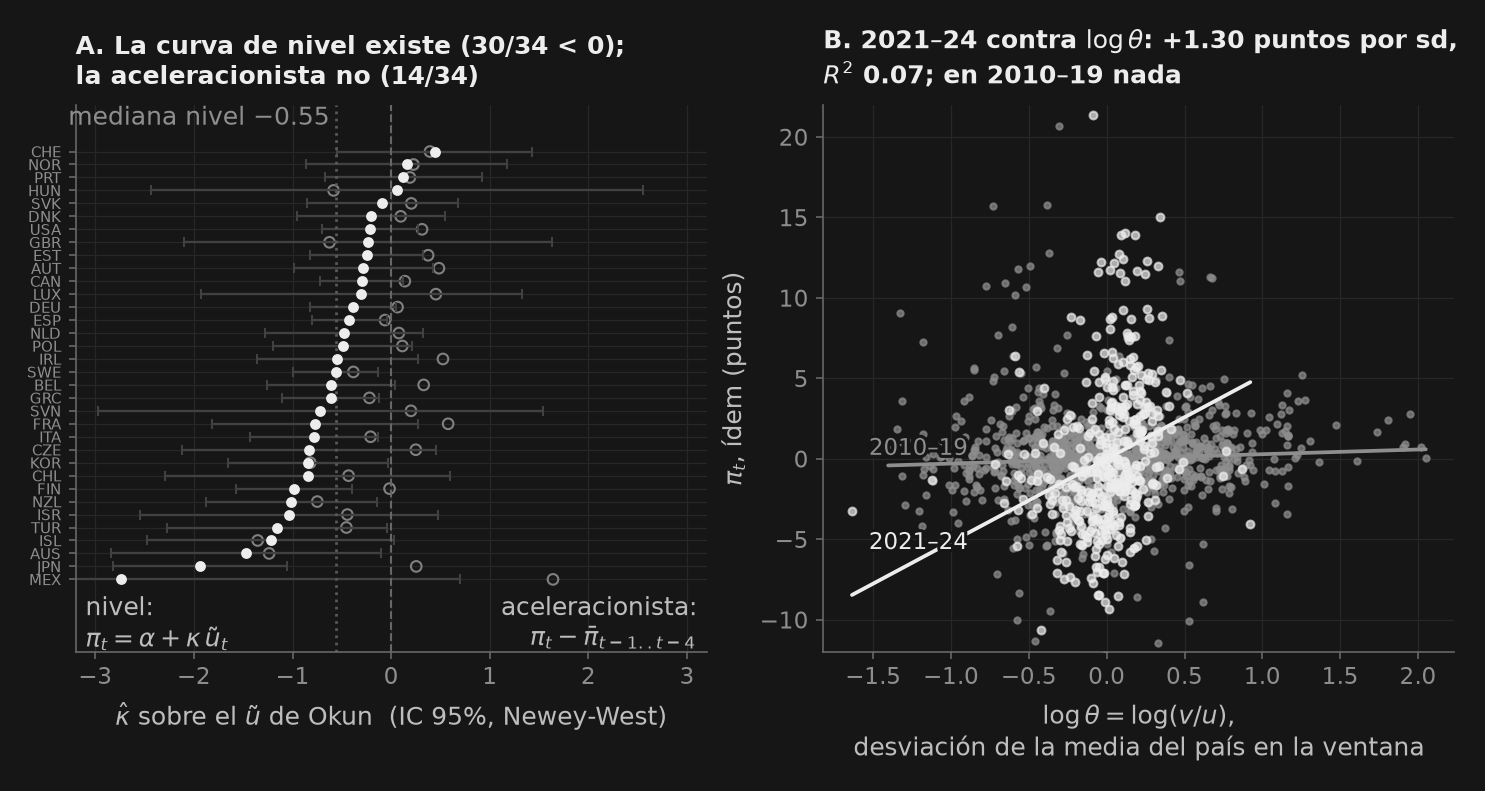

In [28]:
fig, (axK, axT) = _nbstyle.figura(1, 2, alto=True)

o = ph.sort_values("kappa")
yy = np.arange(len(o))
axK.errorbar(o["kappa"], yy, xerr=1.96 * o["se"], fmt="o", color=cols[0], ecolor=_nbstyle.gris("0.7"),
             elinewidth=1.1, capsize=2.2, ms=4.2, lw=0)
axK.scatter(o["kappa(acel)"], yy, s=26, facecolors="none", edgecolors=_nbstyle.gris("0.35"), lw=1.0)
med = float(o["kappa"].median())
axK.axvline(med, color=_nbstyle.gris("0.55"), ls=":", lw=1.3)
axK.axvline(0, color=_nbstyle.SPINE, ls="--", lw=1.0)
axK.set_yticks(yy); axK.set_yticklabels(o.index, fontsize=7.2); axK.set_ylim(-5.6, len(o) + 2.6)
axK.set_xlim(-3.2, 3.2)
axK.set_xlabel("$\\hat\\kappa$ sobre el $\\tilde u$ de Okun  (IC 95%, Newey-West)")
axK.set_title(f"A. La curva de nivel existe ({n_niv}/{len(niv)} < 0);\n"
              f"la aceleracionista no ({n_acel}/{len(acel)})")
# Las dos marcas, nombradas bajo la fila de abajo (donde más lejos quedan una de
# otra), y la mediana en lo alto de su recta, en vez de en una leyenda.
axK.annotate("nivel:\n$\\pi_t = \\alpha + \\kappa\\,\\tilde u_t$", xy=(-3.1, -1.1),
             ha="left", va="top", color=_nbstyle.TEXTO)
axK.annotate("aceleracionista:\n$\\pi_t - \\bar\\pi_{t-1..t-4}$", xy=(3.1, -1.1),
             ha="right", va="top", color=_nbstyle.TEXTO)
axK.annotate(f"mediana nivel ${med:+.2f}$", xy=(med, len(o) + 0.6), xytext=(-3, 0),
             textcoords="offset points", ha="right", va="bottom", color=_nbstyle.NOTA)

for w, col, s_, lab_ in (("2010-19", _nbstyle.NOTA, 9, "2010–19"), ("2021-24", cols[0], 14, "2021–24")):
    g = epi[epi["ventana"] == w]
    axT.scatter(g["log_theta"], g["pi"], s=s_, color=col, alpha=0.7, zorder=2)
    b = np.polyfit(g["log_theta"], g["pi"], 1)
    _xx = np.linspace(g["log_theta"].min(), g["log_theta"].max(), 20)
    axT.plot(_xx, np.polyval(b, _xx), color=col, lw=1.8, ls="-", label=lab_)
axT.set_xlabel("$\\log\\theta = \\log(v/u)$,\ndesviación de la media del país en la ventana")
axT.set_ylabel("$\\pi_t$, ídem (puntos)")
axT.set_ylim(-12, 22)
_pt = pend.loc[("2021-24", "pi", "log_theta")]
axT.set_title(f"B. 2021–24 contra $\\log\\theta$: {_pt['por sd(x)']:+.2f} puntos por sd,\n"
              f"$R^2$ {_pt['R2']:.2f}; en 2010–19 nada")
_nbstyle.etiquetar(axT, donde=-1.2)
plt.show()


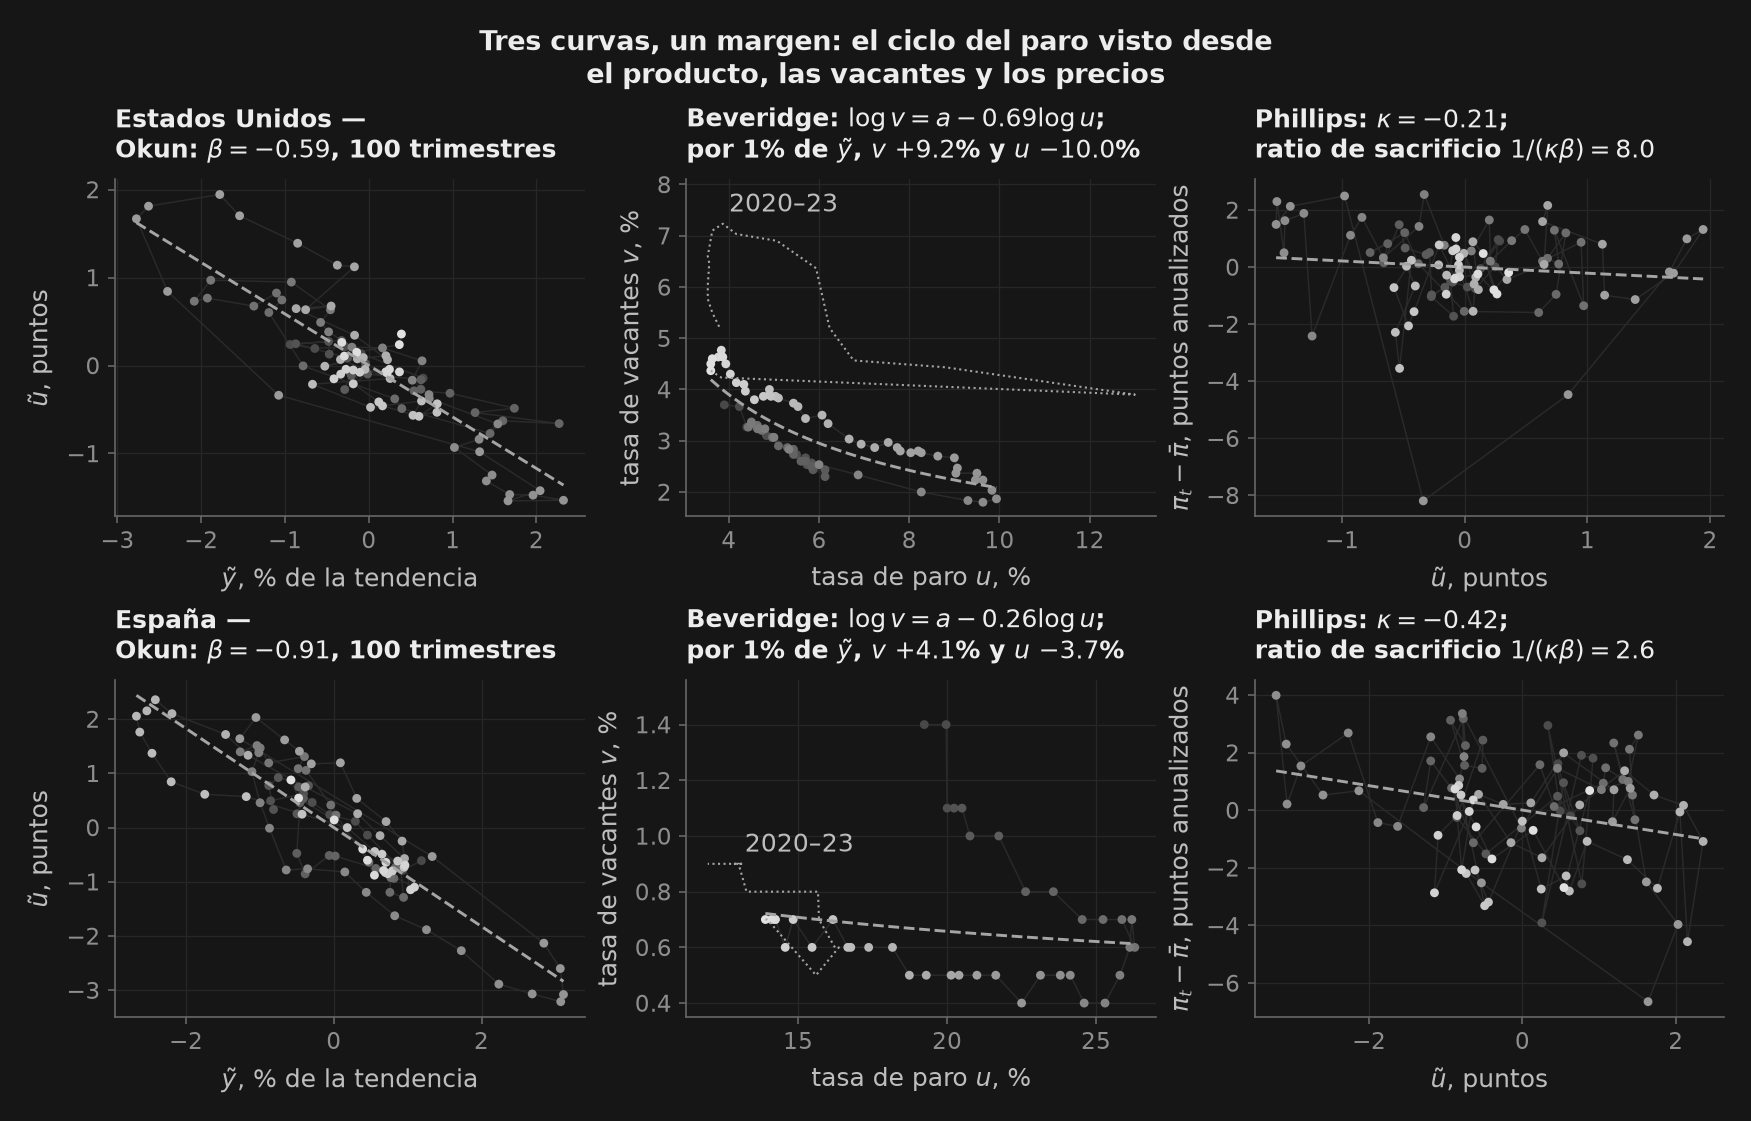

In [29]:
# Tres curvas, un margen: el mismo ciclo del paro visto desde el producto (Okun,
# §5.1), desde las vacantes (Beveridge, §5.2) y desde los precios (Phillips, §5.3),
# en los dos países que la lección viene siguiendo. Tenues los primeros
# trimestres y en tinta plena los últimos, como en T01_B §5.2, para que cada nube se lea
# como una trayectoria. El bucle de 2020-23 va punteado: es el episodio, no el ciclo.
HEROES = (("USA", "Estados Unidos"), ("ESP", "España"))


def _trayectoria(ax, x, y):
    ax.plot(x, y, color=_nbstyle.gris("0.85"), lw=0.7, ls="-", zorder=1)
    ax.scatter(x, y, c=np.linspace(0.22, 0.95, len(x)), cmap="mav_seq",
               vmin=0, vmax=1, s=18, zorder=2, edgecolor="none")


fig, axes = _nbstyle.figura(2, 3)
for fila, (code, nombre) in enumerate(HEROES):
    axO, axB, axP = axes[fila]
    # Okun: el mismo par (ỹ, ũ) que estimó §5.1; la recta es su beta.
    d = pd.concat([volumen("gdp", code).dropna().rename("y"), PARO[code].rename("u")],
                  axis=1, sort=True).dropna().loc[:HASTA]
    yc = np.asarray(hp_filter(100.0 * np.log(d["y"]))[0])
    uc = ciclo_paro(code, PARO[code]).to_numpy()
    _p = np.polyfit(yc, uc, 1)
    assert abs(_p[0] - ok.loc[code, "beta"]) < 1e-9
    _trayectoria(axO, yc, uc)
    gx = np.linspace(yc.min(), yc.max(), 20)
    axO.plot(gx, np.polyval(_p, gx), color=_nbstyle.S2["color"], lw=1.4, ls="--")
    axO.set_xlabel("$\\tilde y$, % de la tendencia"); axO.set_ylabel("$\\tilde u$, puntos")
    axO.set_title(f"{nombre} —\nOkun: $\\beta = {ok.loc[code, 'beta']:+.2f}$, "
                  f"{int(ok.loc[code, 'n'])} trimestres")
    # Beveridge: niveles antes de 2020 con la curva de T01_B, y el bucle 2020-23 encima.
    s = lab.loc[code][["urate", "vrate"]].dropna()
    pre, bucle = s.loc[:HASTA], s.loc["2019-10-01":"2023-12-31"]
    _trayectoria(axB, pre["urate"].to_numpy(), pre["vrate"].to_numpy())
    axB.plot(bucle["urate"], bucle["vrate"], color=_nbstyle.S2["color"], lw=1.0, ls=":", zorder=3)
    # El bucle, nombrado en su punto más alto (el techo de vacantes): es el único
    # tramo suyo que sale de la nube. Un poco de aire arriba para que quepa.
    _i = int(np.argmax(bucle["vrate"].to_numpy()))
    axB.annotate("2020–23", (bucle["urate"].iloc[_i], bucle["vrate"].iloc[_i]), xytext=(3, 3),
                 textcoords="offset points", ha="left", va="bottom", color=_nbstyle.TEXTO)
    gx = np.linspace(pre["urate"].min(), pre["urate"].max(), 40)
    _a = np.log(pre["vrate"]).mean() - bv.loc[code, "b"] * np.log(pre["urate"]).mean()
    # La ecuación de la curva va al título: sobre la nube no queda sitio limpio.
    axB.plot(gx, np.exp(_a + bv.loc[code, "b"] * np.log(gx)), color=_nbstyle.S2["color"], lw=1.4, ls="--")
    axB.set_xlabel("tasa de paro $u$, %"); axB.set_ylabel("tasa de vacantes $v$, %")
    axB.set_title(f"Beveridge: $\\log v = a {bv.loc[code, 'b']:+.2f}\\log u$;\n"
                  f"por 1% de $\\tilde y$, $v$ ${bv.loc[code, 'el(v)']:+.1f}$% y "
                  f"$u$ ${bv.loc[code, 'el(u)']:+.1f}$%")
    _y0, _y1 = axB.get_ylim(); axB.set_ylim(_y0, _y1 + 0.10 * (_y1 - _y0))
    # Phillips: pi menos su media (el ancla) contra el mismo ũ; la recta es kappa.
    m = muestra_phillips(code, PARO[code])
    dpi = (m["pi"] - m["pi"].mean()).to_numpy()
    _q = np.polyfit(m["u"].to_numpy(), dpi, 1)
    assert abs(_q[0] - ph.loc[code, "kappa"]) < 1e-9
    _trayectoria(axP, m["u"].to_numpy(), dpi)
    gx = np.linspace(m["u"].min(), m["u"].max(), 20)
    axP.plot(gx, np.polyval(_q, gx), color=_nbstyle.S2["color"], lw=1.4, ls="--")
    axP.set_xlabel("$\\tilde u$, puntos"); axP.set_ylabel("$\\pi_t - \\bar\\pi$, puntos anualizados")
    axP.set_title(f"Phillips: $\\kappa = {ph.loc[code, 'kappa']:+.2f}$;\nratio de sacrificio "
                  f"$1/(\\kappa\\beta) = {sac.loc[code, 'ratio']:.1f}$")
fig.suptitle("Tres curvas, un margen: el ciclo del paro visto desde\n"
             "el producto, las vacantes y los precios")
plt.show()


### 5.4 Experimento Macroeconómico 1: Descomposición del Trabajo en Tres Márgenes (Gran Recesión vs. COVID-19) y Análisis de Distorsión de Filtros

#### Motivación económica y la Crítica de Lucas
En §2 formulamos la identidad contable exacta del producto:

$$ \Delta\log Y = \Delta\log(Y/H) + \Delta\log(H/E) + \Delta\log E $$

Toda recesión macroeconómica es una mezcla empírica de estos tres márgenes: productividad aparente ($Y/H$), margen intensivo (horas por ocupado $H/E$) y margen extensivo (empleo $E$).

¿Por qué dos economías sujetas a choques externos comparables presentan patrones de ajuste diametralmente opuestos?
1. **La Gran Recesión de 2008:** En 2008, Alemania atesoró mano de obra mediante el *Kurzarbeit* (subsidios públicos a la reducción de jornada) y cuentas de tiempo de trabajo (*Arbeitszeitkonten*), concentrando la contracción en las horas efectivas ($H/E$) con empleo ($E$) prácticamente inalterado. En España, un marco regulatorio con severa dualidad contractual (EPL) incentivó a las empresas a destruir masivamente empleo temporal ($E$), reduciendo la plantilla sin ajustar prácticamente las horas de los indefinidos.
2. **La paradoja de la productividad contracíclica:** Como los trabajadores temporales despedidos en España procedían de ramas de baja cualificación y bajo valor añadido (construcción, servicios básicos), su salida del denominador provocó un aumento mecánico de la productividad observada ($Y/H$, $+3.1$ puntos logarítmicos). No fue un choque tecnológico positivo, sino un puro efecto composición.
3. **El cambio de régimen en la pandemia de COVID-19:** En 2020, España desplegó los ERTEs (*Expedientes de Regulación Temporal de Empleo*), adoptando de facto el modelo del *Kurzarbeit*. Conforme a la **Crítica de Lucas** (Lucas 1976), al modificarse la regla de política laboral, el comportamiento optimizador de las empresas cambió drásticamente: España absorbió la caída del PIB predominantemente por el margen intensivo ($\Delta\log(H/E) \approx -21.5\%$), comportándose como Alemania.
4. **Prueba de estrés sobre la distorsión del filtro:** ¿Cómo afecta la elección de desestacionalización y filtrado a los momentos estructurales en episodios de crisis extremas? Ante el choque extremo no gaussiano de 2020, el filtro bilateral HP ($\lambda=1600$) sufre una severa distorsión de extremo: arrastra la tendencia hacia abajo y fabrica retrospectivamente auges artificiales en los trimestres previos a la pandemia (revisando la brecha de 2019T4 en más de $+2.7$ puntos porcentuales).

#### Tareas guiadas para el estudiante:
1. **Implementar la descomposición exacta en tres márgenes:** Escribir `descomposicion_tres_margenes(code, t_pico, t_valle)` extrayendo el PIB real encadenado ($Y = \text{gdp}/\text{gdp\_defl} \times 100$), el empleo ($E$) y las horas trabajadas ($H$) desde `_datos.gasto()` y `_datos.mercado_laboral()`. Verificar la identidad contable $\Delta\log Y = \Delta\log(Y/H) + \Delta\log(H/E) + \Delta\log E$.
2. **Prueba de estrés de la Gran Recesión de 2008 (Alemania vs. España):** Descomponer la caída de pico a valle (2008T1 a 2009T2 para DEU; 2008T1 a 2009T3 para ESP). Cuantificar el peso de los márgenes intensivo vs. extensivo y contrastar la paradoja de la productividad en España.
3. **Analizar el choque de COVID-19 de 2020:** Descomponer el colapso de 2019T4 a 2020T2. Documentar cómo los programas de sostenimiento del empleo (ERTEs / Kurzarbeit) volcaron el ajuste en el margen intensivo en ambos países.
4. **Evaluar la distorsión del filtro HP en los extremos:** Calcular el ciclo HP sobre 2015–2019 frente a 2015–2021 para Alemania y España, cuantificando la revisión retrospectiva inducida sobre las brechas previas al choque.

=== Experimento Macroeconómico 1: Descomposición en Tres Márgenes ===
               País  Delta log Y (%)  Productividad Y/H (%)  Intensivo H/E (%)  Extensivo E (%)  Residuo Identidad
Episodio                                                                                                          
DEU 2008 GFC    DEU            -7.04                  -3.63              -3.77            +0.36              +0.00
ESP 2008 GFC    ESP            -4.19                  +3.07              +1.72            -8.97              +0.00
DEU 2020 COVID  DEU           -11.26                  -2.97              -7.01            -1.28              +0.00
ESP 2020 COVID  ESP           -24.91                  +5.12             -21.49            -8.53              +0.00


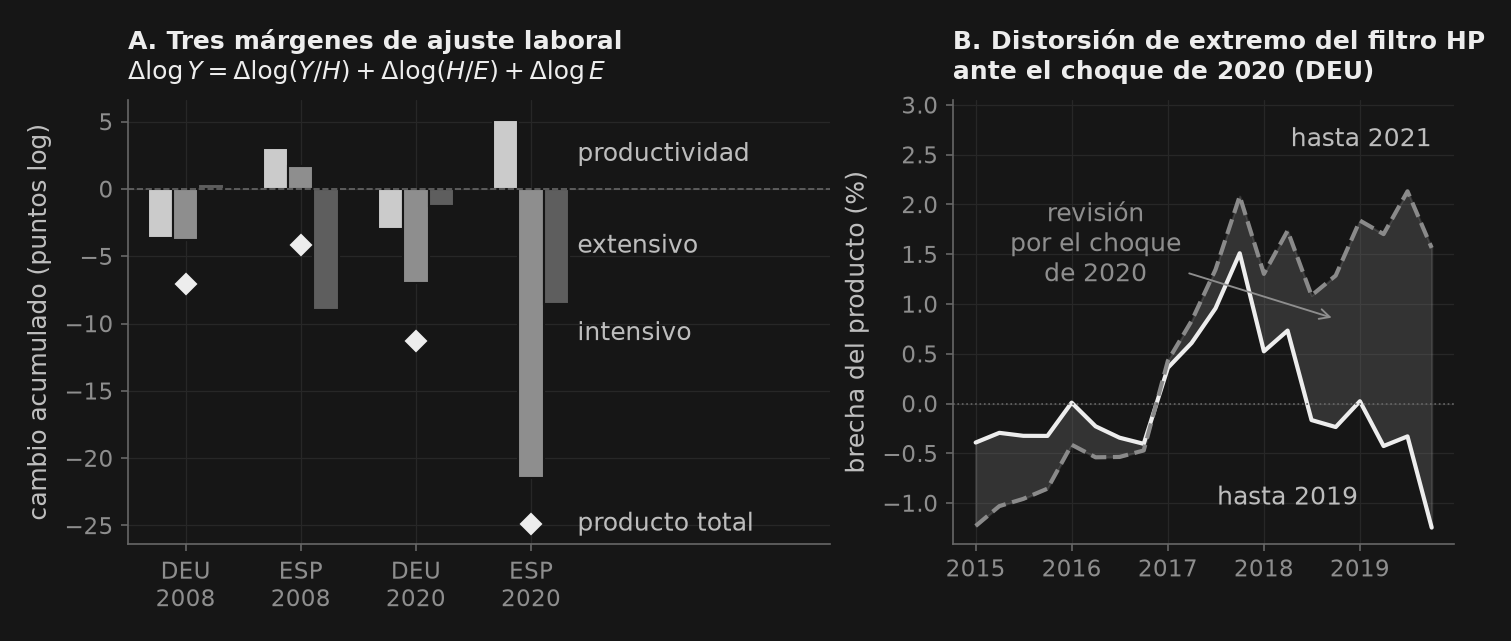

In [30]:
# --- Experimento Macroeconómico 1: Descomposición del Trabajo en Tres Márgenes ---

def descomposicion_tres_margenes(code, t_pico, t_valle):
    """Descomposición de pico a valle del crecimiento del producto en tres márgenes.

    Identifica:
      dy = d_prod + d_intens + d_extens
    donde:
      dy = Delta log(Y)
      d_prod = Delta log(Y/H) (Productividad)
      d_intens = Delta log(H/E) (Horas por ocupado / Margen intensivo)
      d_extens = Delta log(E) (Empleo / Margen extensivo)
    """
    pib = gas.xs(code)["gdp"] / gas.xs(code)["gdp_defl"] * 100.0
    l_df = lab.xs(code)

    y = np.log(pib)
    e = np.log(l_df["emp"])
    h = np.log(l_df["hours"])

    dy = 100.0 * (y.loc[t_valle] - y.loc[t_pico])
    de = 100.0 * (e.loc[t_valle] - e.loc[t_pico])
    dh = 100.0 * (h.loc[t_valle] - h.loc[t_pico])

    d_prod = dy - dh          # Producto por hora
    d_intens = dh - de        # Horas por ocupado
    d_extens = de             # Empleo

    return {
        "code": code,
        "pico": t_pico,
        "valle": t_valle,
        "dy": dy,
        "d_prod": d_prod,
        "d_intens": d_intens,
        "d_extens": d_extens,
    }


# Evaluar episodios: Gran Recesión (2008) y COVID-19 (2020)
esp_gfc = descomposicion_tres_margenes("ESP", "2008-01-01", "2009-07-01")
deu_gfc = descomposicion_tres_margenes("DEU", "2008-01-01", "2009-04-01")
esp_cov = descomposicion_tres_margenes("ESP", "2019-10-01", "2020-04-01")
deu_cov = descomposicion_tres_margenes("DEU", "2019-10-01", "2020-04-01")

# Construir tabla comparativa
exp_resultados = [
    ("DEU 2008 GFC", deu_gfc),
    ("ESP 2008 GFC", esp_gfc),
    ("DEU 2020 COVID", deu_cov),
    ("ESP 2020 COVID", esp_cov),
]

df_descomp = pd.DataFrame([
    {
        "Episodio": etiqueta,
        "País": r["code"],
        "Delta log Y (%)": r["dy"],
        "Productividad Y/H (%)": r["d_prod"],
        "Intensivo H/E (%)": r["d_intens"],
        "Extensivo E (%)": r["d_extens"],
        "Residuo Identidad": r["dy"] - (r["d_prod"] + r["d_intens"] + r["d_extens"]),
    }
    for etiqueta, r in exp_resultados
]).set_index("Episodio")

print("=== Experimento Macroeconómico 1: Descomposición en Tres Márgenes ===")
print(df_descomp.to_string(float_format=lambda x: f"{x:+.2f}"))

# Visualización: A (tres márgenes) y B (distorsión de extremo del filtro HP)
# Al exportar a lámina la figura hereda el tamaño de la ranura; en el cuaderno
# usa el tamaño de siempre para dos paneles.
_ranura = plt.rcParams["figure.figsize"] if _nbstyle.PERFIL == "lamina" else None
fig, (ax_m, ax_f) = _nbstyle.figura(1, 2, gridspec_kw={"width_ratios": [1.4, 1]},
                                    figsize=_ranura)

etiquetas = [item[0] for item in exp_resultados]
pos_x = np.arange(len(etiquetas))
ancho = 0.22

d_prods = [item[1]["d_prod"] for item in exp_resultados]
d_intenss = [item[1]["d_intens"] for item in exp_resultados]
d_extenss = [item[1]["d_extens"] for item in exp_resultados]
d_ys = [item[1]["dy"] for item in exp_resultados]

ax_m.bar(pos_x - ancho, d_prods, ancho, color=_nbstyle.BARRA_COLORES[0], edgecolor=_nbstyle.FONDO)
ax_m.bar(pos_x, d_intenss, ancho, color=_nbstyle.BARRA_COLORES[1], edgecolor=_nbstyle.FONDO)
ax_m.bar(pos_x + ancho, d_extenss, ancho, color=_nbstyle.BARRA_COLORES[2], edgecolor=_nbstyle.FONDO)
ax_m.plot(pos_x, d_ys, marker="D", color=_nbstyle.TINTA, linestyle="",
          markersize=plt.rcParams["lines.markersize"] + 1.5)

ax_m.axhline(0, color=_nbstyle.SPINE, lw=0.8, ls="--")
ax_m.set_xticks(pos_x)
# País y año bastan para nombrar el episodio, y en dos renglones cortos caben
# bajo barras de 0,4 pulgadas en la ranura.
ax_m.set_xticklabels([f"{e.split()[0]}\n{e.split()[1]}" for e in etiquetas])
ax_m.set_ylabel("cambio acumulado (puntos log)")
# La identidad va en el título (el cuaderno lo conserva; en la lámina la
# cabeza del marco dice lo mismo), para que los nombres de las barras quepan.
ax_m.set_title("A. Tres márgenes de ajuste laboral\n"
               r"$\Delta\log Y=\Delta\log(Y/H)+\Delta\log(H/E)+\Delta\log E$")
# Los nombres, a la derecha del último episodio (el de barras más largas), a la
# altura de la barra o del punto que nombran, en vez de en una leyenda.
ax_m.set_xlim(-0.5, len(etiquetas) + 1.6)
for etiqueta, y in (("productividad", d_prods[-1] / 2.0),
                    ("intensivo", d_intenss[-1] / 2.0),
                    ("extensivo", d_extenss[-1] / 2.0),
                    ("producto total", d_ys[-1])):
    ax_m.annotate(etiqueta, xy=(pos_x[-1] + ancho * 1.5, y), xytext=(4, 0),
                  textcoords="offset points", ha="left", va="center", color=_nbstyle.TEXTO)

# Panel B: distorsión de extremo del filtro HP (Alemania)
pib_deu = gas.xs("DEU")["gdp"] / gas.xs("DEU")["gdp_defl"] * 100.0
y_deu_pre = 100.0 * np.log(pib_deu.loc["2015-01-01":"2019-12-31"])
y_deu_full = 100.0 * np.log(pib_deu.loc["2015-01-01":"2021-12-31"])

hp_pre, _ = hp_filter(y_deu_pre, lamb=1600)
hp_full, _ = hp_filter(y_deu_full, lamb=1600)

fechas_graf = hp_pre.index
ax_f.plot(fechas_graf, hp_pre, label="hasta 2019", color=cols[0])
ax_f.plot(fechas_graf, hp_full.loc[fechas_graf], label="hasta 2021", color=cols[3], ls="--")
ax_f.fill_between(fechas_graf, hp_pre, hp_full.loc[fechas_graf], color=cols[3], alpha=0.25)

ax_f.axhline(0, color=_nbstyle.SPINE, lw=0.8, ls=":")
ax_f.set_ylabel("brecha del producto (%)")
ax_f.set_title("B. Distorsión de extremo del filtro HP\nante el choque de 2020 (DEU)")
# Los nombres de las dos muestras van en los dos huecos limpios del panel: bajo
# la línea corta, y arriba en un carril abierto para la larga.  `etiquetar` los
# escribe pegados a la línea, y al ancho de la ranura el vaivén trimestral de la
# muestra larga se los come.
_techo = ax_f.get_ylim()[1]
ax_f.set_ylim(top=_techo + 0.75)
ax_f.annotate("hasta 2019", xy=(pd.Timestamp("2018-04-01"), -0.95),
              ha="center", va="center", color=_nbstyle.TEXTO)
ax_f.annotate("hasta 2021", xy=(fechas_graf[-1], _techo + 0.35),
              ha="right", va="center", color=_nbstyle.TEXTO)
# El nombre de la franja, en el hueco de arriba a la izquierda y con una flecha
# hasta ella: escrito dentro cruzaba la línea de la muestra corta.
ax_f.annotate("revisión\npor el choque\nde 2020", xy=(pd.Timestamp("2018-10-01"), 0.85),
              xytext=(pd.Timestamp("2016-04-01"), 1.6), ha="center", va="center",
              color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
plt.show()


In [31]:
# --- Experimento Macroeconómico 1: Verificación Automatizada y Aserciones Diagnósticas ---

# 1. Verificar identidad contable exacta en todas las descomposiciones
for etiqueta, r in exp_resultados:
    residuo = abs(r["dy"] - (r["d_prod"] + r["d_intens"] + r["d_extens"]))
    assert residuo < 1e-6, f"Fallo de identidad contable en {etiqueta}: residuo = {residuo}"

# 2. Verificar paradoja de productividad y colapso de empleo en España (GFC 2008)
assert esp_gfc["d_prod"] > 0, "La productividad medida en España debe subir en 2008 (efecto composición)"
assert esp_gfc["d_extens"] < -5.0, "El margen extensivo en España debe contraerse severamente en 2008"

# 3. Verificar atesoramiento y ajuste intensivo por Kurzarbeit en Alemania (GFC 2008)
assert deu_gfc["d_intens"] < -2.0, "Alemania debe ajustar intensamente por horas por ocupado en 2008"
assert deu_gfc["d_extens"] > -1.0, "El empleo en Alemania debe permanecer resiliente en 2008"

# 4. Verificar cambio institucional en COVID-19 (predominio del margen intensivo vía ERTEs/Kurzarbeit)
assert esp_cov["d_intens"] < -15.0, "El margen intensivo en España debe colapsar en 2020 debido a los ERTEs"
assert deu_cov["d_intens"] < -5.0, "El margen intensivo en Alemania debe absorber el choque COVID vía Kurzarbeit"

# 5. Verificar magnitud de distorsión del filtro HP en el extremo
rev_2019t4 = float(hp_full.loc["2019-10-01"] - hp_pre.loc["2019-10-01"])
assert rev_2019t4 > 1.5, f"Se esperaba revisión >1.5 pp en brecha HP de 2019T4, obtenida {rev_2019t4:.2f} pp"

print("✓ Experimento Macroeconómico 1: Todas las aserciones empíricas y estructurales verificadas con éxito.")

✓ Experimento Macroeconómico 1: Todas las aserciones empíricas y estructurales verificadas con éxito.


#### Hallazgos y conclusiones teóricas del Experimento 1

1. **Las instituciones determinan el margen de ajuste:**
   - En la Gran Recesión de 2008, la caída del PIB alemán de $-7.0\%$ fue absorbida mayoritariamente por reducción de jornada ($-3.8\%$) y productividad aparente ($-3.6\%$), con el empleo manteniéndose estable ($+0.4\%$). Las empresas alemanas atesoraron mano de obra cualificada porque el *Kurzarbeit* subvencionó los salarios protegiendo el capital específico del emparejamiento.
   - En España, la contracción del PIB de $-4.2\%$ fue absorbida casi en su totalidad por la destrucción masiva de puestos de trabajo ($-9.0\%$). La dualidad contractual permitió a las empresas despedir a trabajadores temporales con un coste indemnizatorio casi nulo.
2. **La paradoja de la productividad contracíclica es un efecto composición:**
   - El PIB español se contrajo menos que las horas totales trabajadas debido a que los empleos destruidos se concentraban en ramas de baja productividad relativa (construcción y servicios). La purga estadística de los trabajadores menos productivos provocó que el producto por hora agregada aumentara $+3.1\%$ durante la peor crisis moderna de España.
3. **La Crítica de Lucas en acción (los ERTEs de 2020):**
   - Cuando estalló la pandemia de COVID-19 en 2020, España no repitió el ajuste de 2008. El gobierno articuló los ERTEs (*Expedientes de Regulación Temporal de Empleo*), financiando reducciones temporales de jornada e impidiendo despidos. Como predijo la Crítica de Lucas, la conducta privada cambió endógenamente: España absorbió $-21.5\%$ de su desplome de $-24.9\%$ a través del margen intensivo ($H/E$), demostrando que los parámetros del mercado laboral dependen de la política y no son constantes universales.
4. **El peligro del filtro HP ante choques de cola:**
   - Como muestra el Panel B, añadir las observaciones del choque de 2020 revisa retrospectivamente al alza la brecha del producto estimada en 2019T4 en $+2.81$ puntos porcentuales. El filtro bilateral deprime la tendencia estimada y fabrica retrospectivamente una falsa burbuja de sobrecalentamiento justo antes de la pandemia. Para la calibración de modelos DSGE/RBC, recurrir a filtros bilaterales en torno a episodios de crisis introduce severos sesgos paramétricos de tipo Slutsky.

## 6. ¿Era conocible algo de esto en su momento?

Todos los números de hasta aquí se calcularon con los datos de hoy y la muestra completa de hoy. Quien hacía política no tenía ninguna de las dos cosas. Esta sección reconstruye la brecha del producto **tal como estaba en cada edición mensual desde julio de 1999 hasta marzo de 2020**, para las 39 economías del archivo de T01_B §4.1 cuya historia llega lo bastante atrás, y pregunta cuánto de lo que acabamos de medir era visible mientras importaba. Las ediciones paran en marzo de 2020 y los periodos de referencia en 2019T4, por la razón de §1.1 aplicada un nivel más arriba: una brecha *final* trazada a través de la pandemia no es el patrón contra el que deba medirse nada.

Una nota sobre el archivo, porque decide una de las cifras de abajo. Para doce de las cuarenta y dos áreas las ediciones tempranas cargan la serie **sin desestacionalizar** —501 de las 11.434 que puntúa el cribado de T01_B §4.1, sobre un archivo de 11.503—, y una tendencia HP trazada a través de un factor estacional no es una brecha del producto. Esta sección hace con ellas exactamente lo que hace T01_B §4.1: desestacionalizar las 11.503 —el archivo entero, también las 69 que el cribado no llega a puntuar— con un mismo filtro de ficticias trimestrales ajustadas dentro de cada edición, sin tirar ninguna. Tirar las 501 —que es lo que esta sección hacía— borra 149 de las 6.945 estimaciones de abajo, y las borra donde más pesa el estadístico: en las siete áreas que las pierden, la parte de la revisión que son los datos vale 1.35 pp en las estimaciones que se irían y 0.83 pp en las que quedan, mientras que la parte del filtro va al revés. El tratamiento no era neutral para el reparto que esta sección mide, así que las dos lecciones lo comparten.

Orphanides y van Norden (2002) mostraron para Estados Unidos que la brecha del producto en tiempo real se revisa tanto que resulta casi inútil para la política — y, crucialmente, que la mayor parte de la revisión **no** es culpa de los estadísticos. Hay dos problemas distintos, y se pueden separar:

| | qué usa | qué aísla |
|---|---|---|
| **final** | los datos de hoy, muestra completa hasta 2019T4 | la respuesta que creemos ahora |
| **cuasi tiempo real** | los datos de hoy, truncados en $t$ | el problema del **extremo de la muestra**: una tendencia HP al final de una muestra no tiene futuro en el que apoyarse |
| **tiempo real** | los datos que de verdad estaban publicados en $t$ | añade encima el problema de la **revisión de los datos** |

y como $(\text{final} - \text{tiempo real}) = \underbrace{(\text{final} - \text{cuasi})}_{\text{extremo}} + \underbrace{(\text{cuasi} - \text{tiempo real})}_{\text{datos}}$ exactamente, las dos fuentes se pueden sumar y comparar. Aquí es donde el archivo de T01_B §4.1 se gana el sueldo por segunda vez: allí midió si las revisiones son *news* o *noise*, y aquí mide qué le hicieron esas revisiones al único número que un banco central de verdad quiere.

In [32]:
from puremacro.fetch.realtime import (VintagePanel, seasonal_signature,
                                      SEASONAL_MIN_OBS, SEASONAL_WINDOW)

INSTANTANEA_VINTAGES = DATOS / "oecd_stes_vintages_gdp.csv.gz"
#: El archivo trae una serie sin desestacionalizar en algunas ediciones
#: tempranas, y una tendencia HP trazada a través de un estacional no es una
#: brecha del producto. El CRIBADO que las detecta vive en puremacro, y el
#: TRATAMIENTO es el mismo que el de T01_B §4.1: las dos lecciones
#: desestacionalizan TODAS las ediciones del archivo con un mismo filtro de
#: ficticias trimestrales ajustadas dentro de cada edición, y no tiran
#: ninguna. Ya no hay manera de que discrepen — ni sobre qué ediciones están
#: sin ajustar, ni sobre qué hacerles.
MIN_TR = 40


def panel_tiempo_real(ruta):
    s = pd.read_csv(ruta, dtype={"edition": str})
    return VintagePanel(df=pd.DataFrame({
        "country": s["code"].astype(str), "variable": s["variable"].astype(str),
        "date": pd.PeriodIndex(s["date"].astype(str), freq="Q").to_timestamp(),
        "vintage": pd.to_datetime(s["edition"], format="%Y%m"),
        "value": pd.to_numeric(s["value"]), "provider": "oecd_stes",
        "series_id": s["code"].astype(str) + ".Q.B1GQ_Q...", "units": "level"}))


# El cuerpo de la función es el de T01_B §4.1, carácter por carácter: es el
# tratamiento y no el cribado, así que vive en el cuaderno y a la vista —el
# cribado sí está en puremacro— y las dos lecciones tienen que aplicar el
# mismo. Lo único que cambia es la última frase del docstring, que apunta a
# T01_B §4.1 porque la comprobación contra X-13 vive allí y no aquí.
def desestacionalizar_ediciones(p, firma=None, ventana=SEASONAL_WINDOW,
                                min_obs=SEASONAL_MIN_OBS):
    """Un mismo filtro estacional sobre TODAS las ediciones del archivo.

    El filtro es el reverso exacto del cribado: `seasonal_signature` detecta
    una edición sin desestacionalizar comparando las cuatro medias trimestrales
    del crecimiento logarítmico *de esa misma edición*, y esto les resta esas
    cuatro medias. Sobre el nivel equivale a dividir por un factor estacional
    multiplicativo, porque la suma acumulada de cuatro medias centradas es
    periódica con periodo cuatro; sobre el crecimiento —que es lo que la
    regresión de Mankiw–Shapiro usa— equivale a un ajuste por variables
    ficticias trimestrales.

    Tres propiedades que lo hacen admisible en un archivo en tiempo real:

    1. **No mira hacia adelante.** Cada edición se ajusta con los trimestres
       que esa edición contenía, y ninguno posterior. La edición de mayo de
       2001 se desestacionaliza con lo que se sabía en mayo de 2001.
    2. **Es invariante a los cambios de base.** Multiplicar una edición entera
       por una constante no cambia su crecimiento logarítmico, así que tampoco
       sus medias trimestrales ni el factor que se le resta.
    3. **Es un no-operativo donde la oficina ya hizo el trabajo.** Las
       ediciones ya ajustadas conservan una estacionalidad residual de décimas
       de punto; restarla las mueve en el cuarto decimal.

    Es deliberadamente tosco —no persigue estacionalidad móvil, ni efectos de
    calendario, ni atípicos, que es lo que X-13 sí hace— y deliberadamente
    barato: once mil ediciones en un par de segundos, sin binarios externos,
    en una tableta. T01_B §4.1 lo contrasta contra X-13 donde más se juega.

    Devuelve ``(VintagePanel, recibo)``; el recibo dice, área por área, cuánta
    estacionalidad tenía la peor edición antes y después.
    """
    lo, hi = pd.Timestamp(ventana[0]), pd.Timestamp(ventana[1])
    piezas, cortas = [], 0
    for (pais, var), sub in p.df.groupby(["country", "variable"], sort=True):
        piv = (sub.pivot_table(index="date", columns="vintage", values="value")
                  .sort_index())
        lg = np.log(piv)
        g = lg.diff()
        q = pd.Index(g.index.quarter)
        dentro = (g.index >= lo) & (g.index < hi)
        qd = q[dentro]
        m = g[dentro].groupby(qd).mean().reindex([1, 2, 3, 4])
        n_q = g[dentro].groupby(qd).count().reindex([1, 2, 3, 4]).fillna(0)
        # Las poquísimas ediciones que no llegan a min_obs dentro de la ventana
        # —las primerísimas, que terminan en 1998— se estiman sobre su muestra
        # entera, que para ellas es toda anterior a la pandemia de todos modos.
        corta = n_q.sum() < min_obs
        if corta.any():
            entera = g.groupby(q).mean().reindex([1, 2, 3, 4])
            mask = corta.to_numpy()
            m.loc[:, mask] = entera.loc[:, mask]
            cortas += int(corta.sum())
        m = m.fillna(0.0)
        m = m - m.mean(axis=0)      # centrado: se quita el perfil, no la media
        factor = m.cumsum()          # periódico por construcción: factor[4] = 0
        clave = pd.MultiIndex.from_arrays(
            [sub["date"].dt.quarter, sub["vintage"]])
        piezas.append(sub.assign(
            value=sub["value"].to_numpy()
            * np.exp(-factor.stack().reindex(clave).to_numpy())))
    salida = pd.concat(piezas, ignore_index=True)
    ajustado = VintagePanel(df=salida,
                            metadata={**p.metadata,
                                      "seasonal": "quarterly dummies within edition",
                                      "short_editions": cortas})
    # `firma` se recibe hecha porque la celda ya la calculó para el cribado:
    # puntuar once mil ediciones dos veces es un cuarto de segundo en un
    # escritorio y bastante más en una tableta, y son exactamente los mismos
    # números.
    antes = seasonal_signature(p) if firma is None else firma
    despues = seasonal_signature(ajustado)
    recibo = pd.concat(
        [antes.groupby("country")["seasonal_range"].max().rename("rango_antes"),
         despues.groupby("country")["seasonal_range"].max().rename("rango_después"),
         antes.groupby("country")["unadjusted"].sum().rename("marcadas")],
        axis=1)
    return ajustado, recibo


if not _here(INSTANTANEA_VINTAGES):
    raise RuntimeError(
        f"No hay archivo en tiempo real en {INSTANTANEA_VINTAGES}. Lo escribe "
        f"T01_B §4.1 y viaja en la carpeta data_curso/ del curso; cópiala junto "
        f"a este cuaderno.")
crudo = panel_tiempo_real(INSTANTANEA_VINTAGES)
n_filas = len(crudo.df)
# Dos conteos distintos que conviene no confundir, porque la prosa los usa los
# dos: cuántas ediciones trae el archivo, y cuántas PUNTÚA el cribado. El
# cribado exige 16 trimestres dentro de 1995-2019 para estimar unas medias
# trimestrales creíbles, así que las primerísimas ediciones —las que terminan
# en 1998— se quedan sin puntuar. El filtro, en cambio, pasa por todas.
n_ediciones = int(crudo.df.groupby(["country", "variable", "vintage"]).ngroups)
firma = seasonal_signature(crudo)
rev, recibo = desestacionalizar_ediciones(crudo, firma=firma)
# Qué (área, edición) marcó el cribado, para poder decir abajo qué habría
# costado tirarlas. Tirar borra exactamente estas y no toca nada más, así que
# el costo se cuenta sobre la misma tabla y no hace falta un segundo panel.
MARCADAS = set(map(tuple, firma.loc[firma["unadjusted"],
                                    ["country", "vintage"]]
                   .itertuples(index=False, name=None)))
crudo = None        # 1,25 millones de filas que ya no hacen falta: en una
                    # tableta es la diferencia entre correr y paginar.

n_marcadas = int(firma["unadjusted"].sum())
print(f"Archivo en tiempo real: {len(rev.countries)} áreas, {len(rev):,} "
      f"observaciones (trimestre de referencia x edición).")
print(f"Cribado (T01_B §4.1): {n_marcadas} de {len(firma):,} ediciones "
      f"evaluadas cargan la serie sin desestacionalizar,\n  en "
      f"{firma.loc[firma['unadjusted'], 'country'].nunique()} de "
      f"{len(rev.countries)} áreas. El archivo trae {n_ediciones:,} ediciones; "
      f"las\n  {n_ediciones - len(firma)} que el cribado no puntúa no llegan a "
      f"16 trimestres dentro de 1995–2019.")
print(f"Tratamiento (el mismo que T01_B §4.1): un filtro de ficticias "
      f"trimestrales dentro de cada edición,\n  sobre las {n_ediciones:,} "
      f"—todas, también las que el cribado no puntúa— y no sobre las "
      f"{n_marcadas}\n  marcadas. Entran {n_filas:,} filas y salen "
      f"{len(rev.df):,}: no se tira ninguna. La estacionalidad de la\n  peor "
      f"área pasa de {recibo['rango_antes'].max():.1f} pp a "
      f"{recibo['rango_después'].max():.2f} pp.")

# Guardias: el cribado tiene que encontrar algo, el filtro tiene que dejar el
# archivo entero en pie, y la estacionalidad que mide el cribado tiene que
# haberse ido.
assert n_marcadas > 0
assert len(rev.df) == n_filas
assert len(rev.countries) == 42
assert n_ediciones == 11503 and len(firma) == 11434   # archivo / puntuadas
assert float(recibo["rango_después"].max()) < 1e-6

Archivo en tiempo real: 42 áreas, 1,249,388 observaciones (trimestre de referencia x edición).
Cribado (T01_B §4.1): 501 de 11,434 ediciones evaluadas cargan la serie sin desestacionalizar,
  en 12 de 42 áreas. El archivo trae 11,503 ediciones; las
  69 que el cribado no puntúa no llegan a 16 trimestres dentro de 1995–2019.
Tratamiento (el mismo que T01_B §4.1): un filtro de ficticias trimestrales dentro de cada edición,
  sobre las 11,503 —todas, también las que el cribado no puntúa— y no sobre las 501
  marcadas. Entran 1,249,388 filas y salen 1,249,388: no se tira ninguna. La estacionalidad de la
  peor área pasa de 61.8 pp a 0.00 pp.


In [33]:
# El mismo corte de 2019T4 que el resto de la lección, y por la misma razón: una
# tendencia HP trazada a través de 2020 queda contaminada a ambos lados, y aquí
# contaminaría la brecha FINAL contra la que se puntúa cada estimación en tiempo
# real. Así que los periodos de referencia paran en 2019T4 y las ediciones en
# 2020-03, que es la última cuyo trimestre más nuevo sigue dentro de la muestra.
ULTIMO_T = pd.Timestamp(HASTA)
ULTIMA_ED = pd.Timestamp("2020-03-01")

filas = []
for code, sub in rev.df.groupby("country", sort=True):
    piv = (sub.pivot_table(index="date", columns="vintage", values="value")
              .sort_index().loc["1980-01-01":HASTA])
    final = piv[piv.columns.max()].dropna()
    if len(final) < 60:
        continue
    lf = 100.0 * np.log(final)
    brecha_final = pd.Series(np.asarray(hp_filter(lf)[0]), index=lf.index)
    for v in piv.columns:
        if v > ULTIMA_ED:
            continue
        col = piv[v].dropna()
        col = col[col.index <= v]        # nada publicado después de la edición
        if len(col) < MIN_TR:
            continue
        t = col.index[-1]                # el trimestre que esta edición acaba de añadir
        if t not in brecha_final.index:
            continue
        trunc = lf[lf.index <= t]
        if len(trunc) < MIN_TR:
            continue
        filas.append({
            "code": code, "edicion": v, "fecha": t,
            "tr": float(np.asarray(hp_filter(100.0 * np.log(col))[0])[-1]),
            "ctr": float(np.asarray(hp_filter(trunc)[0])[-1]),
            "final": float(brecha_final.loc[t])})
tr = pd.DataFrame(filas)
tr["rev_total"] = tr["final"] - tr["tr"]
tr["rev_extremo"] = tr["final"] - tr["ctr"]
tr["rev_datos"] = tr["ctr"] - tr["tr"]
tr["marcada"] = [(c, v) in MARCADAS
                 for c, v in zip(tr["code"], tr["edicion"])]
assert (tr["rev_extremo"] + tr["rev_datos"] - tr["rev_total"]).abs().max() < 1e-9
print(f"{len(tr):,} estimaciones de la brecha en tiempo real en "
      f"{tr['code'].nunique()} áreas, de las ediciones de "
      f"{tr['edicion'].min():%Y-%m} a {tr['edicion'].max():%Y-%m}.\n")


def _rmse(x):
    return float(np.sqrt(np.mean(np.square(x))))


def _partes(g):
    """Parte var(revisión total) entre sus dos sumandos, de forma exacta.

    Como total = extremo + datos, cov(parte, total) / var(total) para las dos
    partes suma exactamente 1 — cosa que var(parte)/var(total) no hace, porque
    las dos partes están correlacionadas. Una cuota por encima de 1 es entonces
    informativa y no un accidente aritmético: dice que la otra parte se mueve
    en contra del total, es decir, que las revisiones de datos CANCELAN en
    parte el error del filtro.
    """
    v = g["rev_total"].var()
    return (float(g["rev_extremo"].cov(g["rev_total"]) / v),
            float(g["rev_datos"].cov(g["rev_total"]) / v))


ov = tr.groupby("code").apply(lambda g: pd.Series({
    "n": len(g),
    "sd(brecha final)": g["final"].std(ddof=1),
    "corr(tr, final)": g["tr"].corr(g["final"]),
    "rmse(revisión)": _rmse(g["rev_total"]),
    "ruido/señal": _rmse(g["rev_total"]) / g["final"].std(ddof=1),
    "cuota extremo": _partes(g)[0],
    "cuota datos": _partes(g)[1],
    "signo errado": float((np.sign(g["tr"]) != np.sign(g["final"])).mean()),
}), include_groups=False)
assert (ov["cuota extremo"] + ov["cuota datos"] - 1.0).abs().max() < 1e-9
print(ov.sort_values("ruido/señal", ascending=False).round(2).to_string())

m = ov.median(numeric_only=True)
print(f"\n--- la economía mediana ---")
print(f"  la revisión de la brecha es {m['ruido/señal']:.2f} veces la propia "
      f"desviación típica de la brecha")
print(f"  las brechas en tiempo real y final correlacionan "
      f"{m['corr(tr, final)']:.2f}")
print(f"  discrepan sobre el SIGNO de la brecha el {m['signo errado']:.0%} de "
      f"las veces — sobre si la economía estaba por encima o por debajo de la "
      f"tendencia siquiera")
print(f"  y la revisión se reparte {m['cuota extremo']:.0%} / "
      f"{m['cuota datos']:.0%} entre el problema del extremo de la muestra y la "
      f"revisión de los datos — los estadísticos son la mitad pequeña, y por mucho")
_compensan = int((ov["cuota datos"] < 0).sum())
if _compensan:
    print(f"  en {_compensan} áreas la cuota de los datos es NEGATIVA: las "
          f"revisiones de los datos empujan en promedio la brecha DE VUELTA "
          f"hacia la respuesta final, compensando en parte al filtro")
_peor, _mejor = ov["signo errado"].idxmax(), ov["signo errado"].idxmin()
assert ov.loc[_mejor, "n"] == ov["n"].min()   # el mejor es también el más corto
print(f"\n  peor: {_peor} yerra el signo el {ov.loc[_peor, 'signo errado']:.0%} "
      f"de las veces, sobre {int(ov.loc[_peor, 'n'])} estimaciones. "
      f"Mejor: {_mejor} con\n  {ov.loc[_mejor, 'signo errado']:.0%}, sobre sólo "
      f"{int(ov.loc[_mejor, 'n'])} — la muestra más corta del panel, contra una "
      f"mediana de {int(ov['n'].median())}: los dos\n  extremos de esta columna "
      f"no pesan lo mismo.")

# Y lo que habría costado el tratamiento anterior de esta sección —tirar las
# ediciones marcadas—, medido sobre esta misma tabla: tirar borra exactamente
# las filas cuya edición está marcada y deja el resto intacto.
_cuenta = tr[tr["marcada"]].groupby("code").size().sort_values(ascending=False)
_esas = tr[tr["code"].isin(_cuenta.index)]
_por = _esas.groupby(["code", "marcada"])["rev_datos"].apply(_rmse).unstack()
_fuera_datos = _rmse(_esas.loc[_esas["marcada"], "rev_datos"])
_dentro_datos = _rmse(_esas.loc[~_esas["marcada"], "rev_datos"])
print(f"\n--- lo que habría costado tirarlas en vez de ajustarlas ---")
print(f"  {int(_cuenta.sum())} de estas {len(tr):,} estimaciones se irían, en "
      f"{len(_cuenta)} de las {tr['code'].nunique()} áreas "
      f"({', '.join(f'{c} {n}' for c, n in _cuenta.items())}),")
print(f"  todas de ediciones de {tr.loc[tr['marcada'], 'edicion'].min():%Y-%m} "
      f"a {tr.loc[tr['marcada'], 'edicion'].max():%Y-%m}. Y se irían justo "
      f"donde el estadístico pesa más:")
print(f"  en esas {len(_cuenta)} áreas la parte de la revisión que son los "
      f"datos vale {_fuera_datos:.2f} pp en las que se")
print(f"  tirarían y {_dentro_datos:.2f} pp en las que quedan "
      f"({_fuera_datos / _dentro_datos:.1f} veces, y en las "
      f"{int((_por[True] > _por[False]).sum())} de {len(_cuenta)}), mientras "
      f"que la parte")
print(f"  del filtro va al revés "
      f"({_rmse(_esas.loc[_esas['marcada'], 'rev_extremo']):.2f} frente a "
      f"{_rmse(_esas.loc[~_esas['marcada'], 'rev_extremo']):.2f}). Tirar no "
      f"era neutral para el reparto que mide esta sección.")

# Las cifras de cabecera de §6, cada una con su guardia.
assert tr["code"].nunique() == 39
assert abs(m["ruido/señal"] - 1.05) < 0.05
assert abs(m["corr(tr, final)"] - 0.53) < 0.05
assert m["signo errado"] > 0.2
assert abs(m["signo errado"] - 0.35) < 0.03
assert m["cuota extremo"] > 0.5
assert abs(m["cuota extremo"] - 0.92) < 0.03
assert _compensan == 10
assert _fuera_datos > _dentro_datos

6,945 estimaciones de la brecha en tiempo real en 39 áreas, de las ediciones de 1999-07 a 2020-03.

          n  sd(brecha final)  corr(tr, final)  rmse(revisión)  ruido/señal  cuota extremo  cuota datos  signo errado
code                                                                                                                 
GRC   124.0              1.63            -0.03            4.05         2.48           1.16        -0.16          0.24
SVN   116.0              1.21             0.34            2.23         1.84           0.91         0.09          0.54
EST   110.0              1.25             0.35            2.20         1.76           0.74         0.26          0.27
ESP   178.0              1.45             0.16            2.19         1.51           1.03        -0.03          0.31
NZL   245.0              0.94             0.17            1.35         1.43           0.74         0.26          0.55
LVA    45.0              0.72             0.49            1.00         1.4

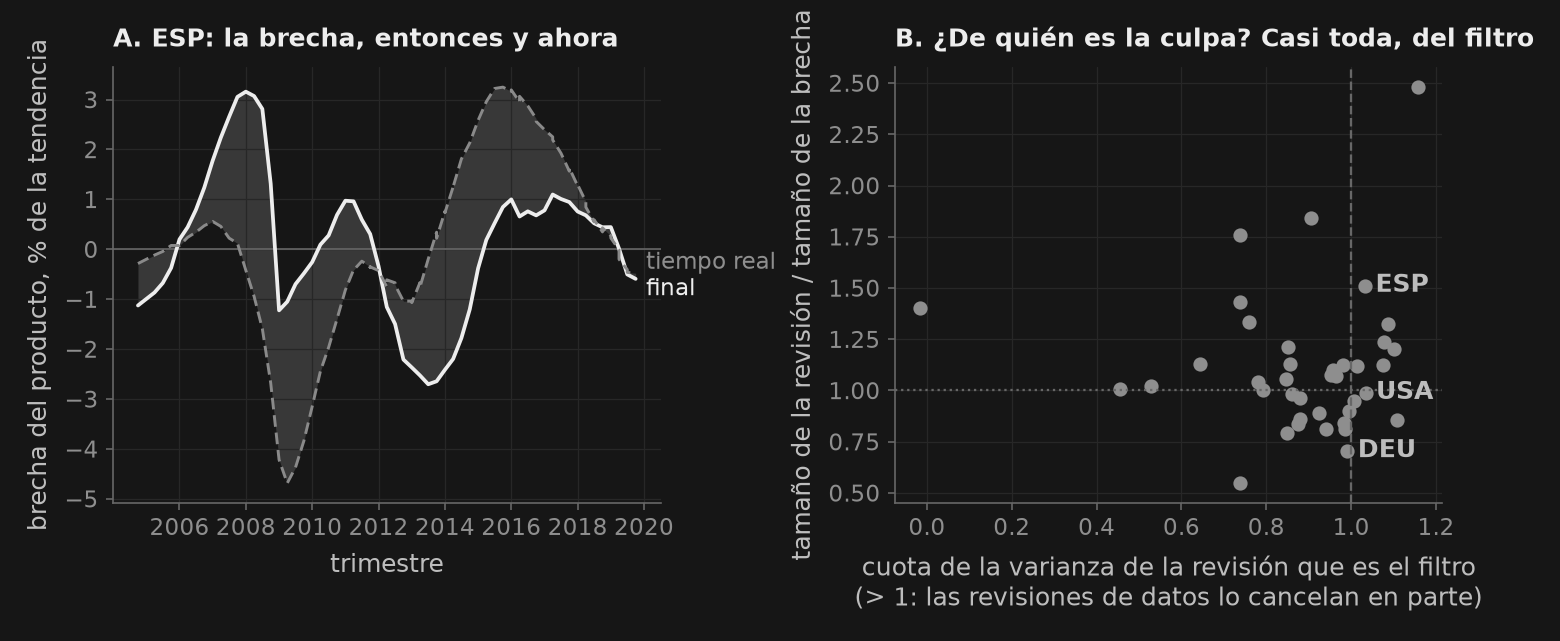

In [34]:
fig, (ax1, ax3) = _nbstyle.figura(1, 2)

FOCO = "ESP" if "ESP" in set(tr["code"]) else sorted(set(tr["code"]))[0]
uno = tr[tr["code"] == FOCO].sort_values("fecha")
ax1.axhline(0, color=_nbstyle.SPINE, lw=0.8)
ax1.plot(uno["fecha"], uno["final"], color=cols[0], lw=1.8, label="final")
ax1.plot(uno["fecha"], uno["tr"], color=cols[3], lw=1.4, ls=(0, (4, 2)), label="tiempo real")
ax1.fill_between(uno["fecha"], uno["tr"], uno["final"], color=_nbstyle.BANDA, lw=0, zorder=0)
ax1.set_ylabel("brecha del producto, % de la tendencia")
ax1.set_xlabel("trimestre")
ax1.set_title(f"A. {FOCO}: la brecha, entonces y ahora")

ax3.scatter(ov["cuota extremo"], ov["ruido/señal"], s=34, color=_nbstyle.NOTA, zorder=2)
# Sólo los tres países que quedan fuera del racimo central llevan nombre; los demás
# no se leerían entre 39 puntos.
for code in ("USA", "ESP", "DEU"):
    if code in ov.index:
        ax3.annotate(code, (ov.loc[code, "cuota extremo"],
                            ov.loc[code, "ruido/señal"]),
                     xytext=(5, -3), textcoords="offset points",
                     color=_nbstyle.TEXTO, fontweight="bold")
ax3.axvline(1.0, color=_nbstyle.SPINE, ls="--", lw=1.1)
ax3.axhline(1.0, color=_nbstyle.SPINE, ls=":", lw=1.1)
ax3.set_xlabel("cuota de la varianza de la revisión que es el filtro\n"
               "(> 1: las revisiones de datos lo cancelan en parte)")
ax3.set_ylabel("tamaño de la revisión / tamaño de la brecha")
ax3.set_title("B. ¿De quién es la culpa? Casi toda, del filtro")
_nbstyle.etiquetar(ax1, donde="fin", fuera=True)
plt.show()


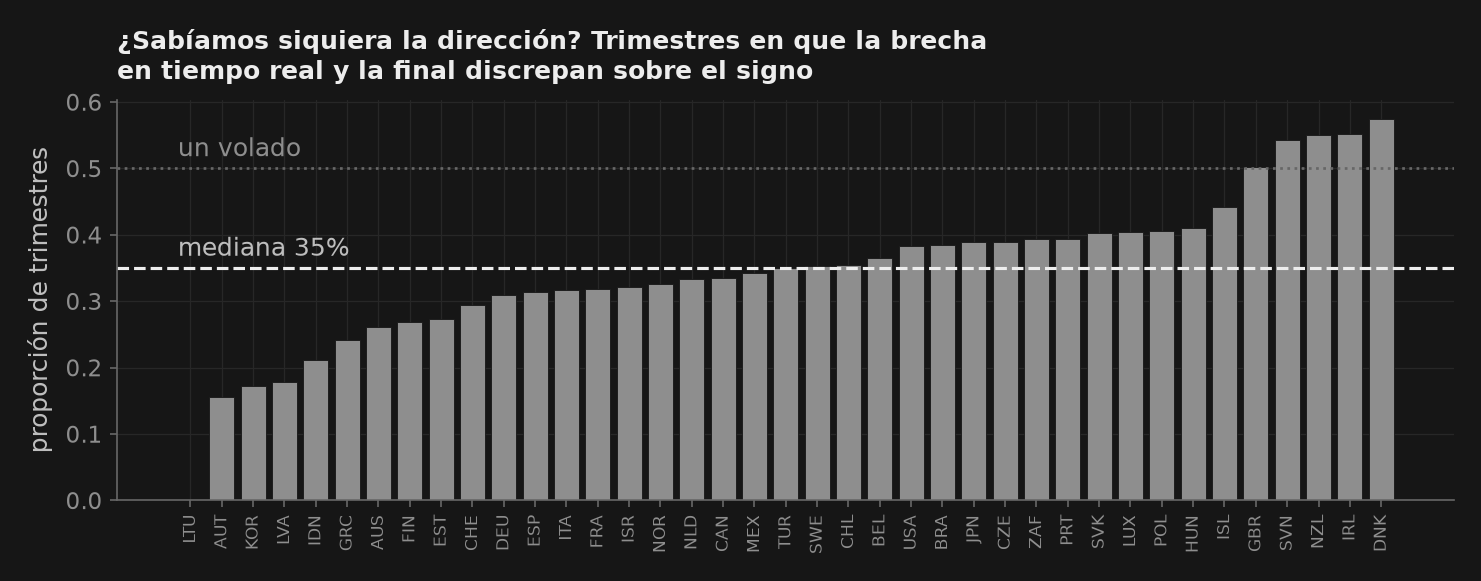

In [35]:
fig, ax = _nbstyle.figura(figsize="ancho")
o = ov.sort_values("signo errado")
x = np.arange(len(o))
ax.bar(x, o["signo errado"], color=_nbstyle.BARRA_COLORES[1], edgecolor=_nbstyle.FONDO, lw=0.4)
med = float(o["signo errado"].median())
ax.axhline(med, color=cols[0], ls="--", lw=1.5)
ax.axhline(0.5, color=_nbstyle.SPINE, ls=":", lw=1.3)
ax.set_xticks(x); ax.set_xticklabels(o.index, rotation=90, fontsize=8.4)
ax.set_ylabel("proporción de trimestres")
ax.set_title("¿Sabíamos siquiera la dirección? Trimestres en que la brecha\n"
             "en tiempo real y la final discrepan sobre el signo")
# Las dos rectas, nombradas en su extremo izquierdo (donde las barras son bajas).
ax.annotate(f"mediana {med:.0%}", xy=(x[0] - 0.4, med), xytext=(0, 3),
            textcoords="offset points", ha="left", va="bottom", color=_nbstyle.TEXTO)
ax.annotate("un volado", xy=(x[0] - 0.4, 0.5), xytext=(0, 3),
            textcoords="offset points", ha="left", va="bottom", color=_nbstyle.NOTA)
plt.show()


### Qué le hace §6 a §1–§5

No las deshace. Los hechos de §4 se calculan con los datos finales y son los hechos correctos que pedirle a un modelo que reproduzca, porque un modelo es una afirmación sobre la economía y no sobre la oficina estadística. Pero zanja la cuestión de cuánto valían esos hechos *en su momento*, y la respuesta es: mucho menos que la confianza con la que se citaban.

Tres cosas para llevarse:

1. **La brecha no es observable.** La brecha del producto en tiempo real de la economía mediana se revisa por **1.05 veces su propia desviación típica** —la corrección es mayor que la cosa corregida—, correlaciona 0.53 con la estimación final y discrepa de ella sobre el *signo* el 35% de las veces. Una regla de política con la brecha del producto en el lado derecho es una regla con un volado dentro, que es exactamente la lectura que hace Orphanides (2001) de la Gran Inflación: la Fed de los años setenta no estaba malinterpretando su propio modelo, estaba leyendo una brecha que después resultó no haber existido.
2. **La culpa es del filtro, no de los estadísticos.** La varianza de la revisión se reparte **92 / 8** entre el extremo de la muestra y los datos, en la economía mediana — y en diez áreas la cuota de los datos es *negativa*, lo que significa que las revisiones del PIB empujan en promedio la brecha estimada de vuelta hacia la respuesta que hoy creemos, cancelando en parte el error del filtro en lugar de sumarse a él. El mecanismo es fácil de ver: la tendencia HP al final de una muestra no tiene futuro en el que apoyarse, así que se ajusta a las últimas observaciones y se mueve cada vez que llega una. T01_B §4.1 mostró que las revisiones del PIB en sí son pequeñas —una desviación típica mediana por debajo de un punto porcentual de crecimiento trimestral—; es el *filtro* el que convierte algo tan pequeño en una brecha que oscila. Ese 8% es además la versión honesta y no la halagadora: tirar las ediciones en bruto en vez de ajustarlas borra justo las estimaciones donde los datos pesan más —1.35 pp de revisión de datos frente a 0.83 pp en las que quedan— y encoge por tanto la mitad que se le atribuye al estadístico. La crítica de Hamilton en §3 era sobre dinámicas espurias. Este es el otro problema, más caro, del mismo filtro, y a diferencia del primero no es cuestión de gustos.
3. **Los dos problemas son separables, y solo uno se arregla con mejores datos.** Que es el caso de la evaluación en tiempo real de cualquier método de extracción de tendencia — y la razón de que `puremacro` guarde los vintages y no solo la última serie.

## 7. Ejercicios
1. **El denominador.** Recalcula la contabilidad del crecimiento de §2 con $Y/E$ en lugar de $Y/H$ — es decir, metiendo `g_horas` dentro de la productividad. (a) ¿A qué países les cambia más el crecimiento de la productividad, y qué tienen en común? (b) Las horas por ocupado alemanas cayeron 0.46% al año. Sobre los 25 años de muestra, ¿cuánto del «milagro de productividad alemán» es ese término? (c) ¿Para qué preguntas es $Y/E$ la medida *correcta*? Nombra una.
2. **Reparar o descartar.** §1.2 repara Chile y Costa Rica con factores de 13 y 1/4. (a) Demuestra que el hecho de que las dos jornadas reparadas coincidan dentro de una hora es evidencia genuina y no algo que el procedimiento forzara — ¿qué habrías visto si el factor hubiera estado mal? (b) Un colega dice que lo prudente es descartar los dos países. ¿Qué se pierde exactamente, y cuál es el costo del error alternativo, dejar a Chile sin reparar? Cuantifica el segundo: ¿qué le hace un Chile sin reparar a la distribución entre países del crecimiento de la productividad de §2?
3. **Filtros.** (a) Rehaz §3 con $\lambda = 6.25$ y $\lambda = 129{,}600$. ¿Cambia el conteo de *signos* (28 de 31)? (b) Varía el horizonte $h$ de Hamilton (4, 8, 12): ¿qué pasa con la pérdida de calentamiento y con la amplitud del ciclo? (c) Portugal y Nueva Zelanda son los dos países cuya respuesta depende del filtro. Mira sus series y di en qué filtro confiarías para cada uno, y por qué «úsalos todos e informa la dispersión» no es una evasiva.
4. **España.** §5 muestra la productividad medida española subiendo 7.2 puntos logarítmicos durante una recesión que costó 12.9 puntos logarítmicos de empleo. (a) Escribe un modelo de dos sectores —construcción con productividad baja, todo lo demás con productividad alta— y muestra algebraicamente que destruir empleos de construcción sube el $Y/H$ agregado medido sin que cambie la productividad de ninguno de los dos sectores. (b) ¿Qué necesitarías de `qna_produccion.csv` de T01_B para medir cuánto de esos 7.2 es este efecto de composición? (c) ¿Es el resto crecimiento «real» de la productividad?
5. **El corte de 2020.** Pon `HASTA = None` y vuelve a correr §4. $\sigma(c)/\sigma(y)$ sube en todas partes y varios países cruzan el 1; la cuota espectral cae. Explica las dos cosas, y después haz el argumento difícil: ¿hay una razón de principio para incluir 2020 en un estadístico del ciclo económico, o excluirlo es una decisión con la que deberíamos sentirnos incómodos?
6. **Gobierno y productividad medida.** §1.3 afirma que el valor añadido de las administraciones públicas tiene crecimiento medido de productividad ~cero por construcción. (a) Explica la convención del SCN que lo hace cierto. (b) La correlación cruda entre países entre la participación de `va_public` y el crecimiento de la productividad es de $-0.39$ en este panel. Da dos razones por las que eso no es evidencia a favor de la afirmación. (Pista: ¿qué países de este panel tienen a la vez gobiernos pequeños y crecimiento alto de la productividad, y por qué?) (c) Diseña un contraste que sí sería evidencia, y di qué datos necesita que no tenemos.
7. **Okun.** §5.1 estima $\tilde{u}_t = \alpha + \beta\,\tilde{y}_t$ para 34 países y encuentra $\beta$ negativo en los 34, con una mediana de $-0.25$ y España en $-0.91$. (a) La correlación entre $\beta$ y $\sigma(E)/\sigma(Y)$ es $-0.42$. Explica por qué eso es *casi* una tautología — y luego identifica la parte que no lo es, escribiendo $E = (1-u)\,L$ y preguntándote qué hace un país con $L$. Nombra dos países de la tabla cuyo $\beta$ es plano *pese* a un margen de empleo violento, y di qué le pasó a su fuerza de trabajo. (b) Nueva Zelanda tiene el mayor $\sigma(E)/\sigma(Y)$ del panel, $1.59$, y uno de los coeficientes de Okun más planos. Dado el diagnóstico de §3 sobre su serie de horas, ¿informarías eso como un hallazgo sobre Nueva Zelanda? (c) Rehaz §5.1 con la tasa de paro del bloque laboral de T01_B en vez de `oecd_urate_q.csv`. El $R^2$ mediano cae de $0.43$ a alrededor de $0.21$ y el $\beta$ de España se mueve. ¿Cuál de esos dos cambios es evidencia de que la muestra corta es peor, y cuál no?
8. **Tiempo real.** (a) En §6, ¿por qué truncar los datos *finales* en $t$ (la brecha cuasi tiempo real) ya produce la mayor parte de la revisión? Dibuja la tendencia HP cerca del final de una muestra para verlo. (b) ¿Lo haría mejor el filtro de Hamilton en tiempo real? Predice primero, y luego pruébalo cambiando `hp_filter` por `hamilton_filter` en §6. (c) Las fechas de vintage del archivo son meses de ingestión de la OCDE, no fechas de publicación nacionales (T01_B §4.1). ¿Sesga eso el ejercicio en tiempo real, y en qué dirección? (d) §6 desestacionaliza las 11.503 ediciones del archivo con el filtro de ficticias trimestrales de T01_B §4.1. Sustitúyelo por `drop_unadjusted_editions` —el tratamiento anterior, que tira las 501 marcadas— y vuelve a correr la sección: la muestra cae de 6.945 estimaciones a 6.796 y el reparto de la varianza pasa de 92/8 a 95/5 en la economía mediana. Explica por qué tirar mueve el reparto *hacia el filtro* precisamente cuando lo que tira son las ediciones contaminadas, y di cuál de los dos números informarías.
9. **Existencias.** `volumen("inv", ...)` es la formación bruta de capital fijo; `volumen("capform", ...)` le suma las existencias. Rehaz $\sigma(i)/\sigma(y)$ con la segunda. ¿Por qué sube, y por qué T01_B escribe aun así la identidad con `capform`?
10. **Junta §5 y §6.** Reconstruye la descomposición de pico a valle de §5 para Alemania usando solo los datos disponibles en 2009T4. ¿Habrías sabido, en tiempo real, que Alemania estaba atesorando trabajo y no sufriendo un desplome de productividad?
11. **Beveridge: el filtro de Shimer y la dirección del bucle.** (a) Repite $\sigma(\tilde\theta)/\sigma(\tilde y)$ de §5.2 con $\lambda = 10^5$ —el de Shimer (2005): `hp_filter(x, lamb=1e5)`— para los 20 países, y después contra la productividad $Y/H$ de §2 en vez del producto, para los que tienen horas. ¿Cambia la mediana, y en qué dirección? ¿Por qué un $\lambda$ mayor mueve más a $\theta$ que al producto? (b) Calcula el área con signo de la trayectoria $(\log u, \log v)$ de cada país —la fórmula del cordón, $\tfrac12\sum_t (x_t y_{t+1} - x_{t+1} y_t)$ cerrando el polígono— sobre los ciclos HP antes de 2020 y sobre los niveles de 2019T4–2023T4. ¿En cuántos países es positiva (antihorario)? ¿Coincide, país por país, con la asimetría $\mathrm{corr}(\tilde v_t,\tilde u_{t+1}) < \mathrm{corr}(\tilde v_t,\tilde u_{t-1})$ de §5.2, y qué tienen en común los países donde no?
12. **Phillips: ¿se aplanó, y con qué índice de precios?** (a) §5.3 encuentra que la mediana de $\kappa$ pasa de $-0.55$ a $-0.19$ entre 1995–2007 y 2010–2019, pero que sólo 18 de 31 países se aplanan y 13 se empinan. Explica cómo puede aplanarse la mediana sin que lo haga el panel, y por qué el cambio mediano *dentro* de cada país ($+0.20$) es el estadístico honesto. (b) Quita la regla $|\pi|>25$ y rehaz el conteo. ¿Qué parte del hecho sobrevive, y qué dice de un hecho que se mueve con un puñado de trimestres-país? (c) Rehaz la curva de nivel para Estados Unidos con `CPIAUCSL.csv` (media trimestral del índice mensual) en inflación interanual, $100\log(P_t/P_{t-4})$, en los dos lados. ¿Cuánto cambia $\kappa$? Separa qué parte del cambio es la canasta y qué parte es pasar de trimestral a interanual.
13. **La ratio de sacrificio y el factor que le falta.** La ratio aceleracionista de los libros, $1/(4\kappa\beta)$ puntos-año por punto permanente, supone $\pi_t = \pi_{t-1} + \kappa\tilde u_t$. Con la expectativa de §5.3, $\bar\pi$ = media de cuatro rezagos, (a) escribe el polinomio $1 - \tfrac14(L + L^2 + L^3 + L^4)$, factoriza $(1-L)$ y calcula cuánto baja la inflación *permanentemente* por cada punto-trimestre acumulado de $\pi - \bar\pi$; compruébalo simulando $\tilde u$ constante durante 40 trimestres. ¿Qué le hace eso a los 2.4 puntos-año de la mediana de §5.3? (b) Ahora pon $\rho = 0.36$ en vez de 1. ¿Cuánto baja la inflación con una brecha permanente, y qué pasa cuando la brecha se cierra? ¿De quién es entonces la ratio de sacrificio: de la economía o del ancla?

14. **Estados Unidos en §3 y §4, ahora que se puede.** §1.4 establece que el par `OUTNFB/HOANBS` mide el mismo concepto que el sector de mercado del panel, con lo que desaparece la objeción de §1.3 a ponerlo en las tablas trimestrales. (a) Construye el sector de mercado **trimestral** para el panel —el bloque laboral ya trae `hours_agri` y `hours_public`, y `produccion()` trae `va_agri` y `va_public`— y recuerda que el valor añadido real de un agregado no es la suma de los volúmenes de sus partes: usa un índice de Törnqvist con las participaciones nominales. (b) Recalcula la tabla de §3 sobre ese concepto y sitúa a Estados Unidos en ella con su propio par del BLS. ¿Sigue siendo la economía más contracíclica del panel, como decía §1.3 que parecería con el empalme? (c) La mediana del panel apenas se mueve al cambiar de concepto mientras que la productividad *media* de casi todos sube (§1.4). Explica por qué un cambio de composición puede mover mucho una media y casi nada una correlación cíclica. (d) Japón no puede entrar aquí por ninguna vía. Di qué haría falta —qué serie, publicada por quién, a qué frecuencia— y por qué construirla a partir de la encuesta de fuerza de trabajo japonesa no sería la misma cosa.

## 8. Explora con IA
Prueba esto con el tutor sin conexión (o cualquier asistente de IA):
- «¿Por qué argumentó Hamilton (2018) en contra del filtro HP? Da la intuición en una frase.»
- «Si la productividad medida sube durante una recesión, nombra tres explicaciones y di cuál deja a la tecnología en paz.»
- «¿Por qué el problema del extremo de la muestra del filtro HP es peor que las revisiones de los datos para una brecha del producto en tiempo real?»
- «Okun, Beveridge y Phillips son tres afirmaciones sobre el mismo margen de empleo. Di en una frase qué pregunta responde cada una, y por qué la pendiente de la curva de Beveridge no basta para predecir el coeficiente de Okun.»

In [36]:
print(tutor("La productividad del trabajo medida subió en España durante la "
            "recesión de 2008-2011 mientras el empleo caía 13%. Explica en dos "
            "frases por qué eso es un efecto de composición y no progreso técnico."))

[tutor sin conexión] No hay ningún motor de LLM local instalado en esta máquina. Instálalo con `pip install "puremacro[local-llm]"` junto con un modelo pequeño (por ejemplo vía Ollama o MLX), o usa las preguntas de exploración con IA de más abajo con el asistente que prefieras. El resto del cuaderno funciona igual sin el tutor.
(detalle del motor: LocalLLMUnavailable)


**Resumen.** Medimos el insumo de trabajo con las mismas cuentas que miden el PIB —reparando dos países cuyas horas llegaban sobre la base temporal equivocada, y nombrando las dos economías que el flujo no cubre en vez de empalmarlas— y construimos el producto por hora para 31 países. El crecimiento se partió exactamente en tres márgenes, y la partición resultó ser el objeto interesante: México creció por empleo con crecimiento negativo de la productividad, Chequia por productividad y casi sin empleo. Después preguntamos si el filtro de extracción de tendencia cambia una respuesta y no solo un número: mueve $\mathrm{corr}(Y, Y/H)$ hasta 0.59 pero le cambia el signo solo a dos de 31 países, así que la prociclicidad de la productividad sobrevive a la crítica de Hamilton — y la productividad *contracíclica* de España también la sobrevive, y §5 explicó por qué en una línea. Los hechos canónicos del ciclo se volvieron una distribución entre 31 países en vez de una lista, con las horas más volátiles que las cabezas en todas partes. Desarmamos la Gran Recesión país por país y encontramos a Alemania perdiéndola por las horas con el empleo al alza, y a España por 13 puntos logarítmicos de empleo con la productividad medida subiendo 7. La ley de Okun comprimió esa mezcla de márgenes en un número —$\beta$ negativo en 34 de 34 países, mediana $-0.25$, España $-0.91$— y las otras dos curvas del mercado de trabajo dijeron cómo se produce ese paro y qué compra: la tensión $v/u$ es 11 veces más volátil que el producto en 20 países, dos tercios por las vacantes, que caen un trimestre antes de que suba el paro, y la pendiente de la curva de Beveridge no predice el coeficiente de Okun; la curva de Phillips aceleracionista no está ($\kappa<0$ en 14 de 34 países) porque las expectativas están ancladas ($\rho = 0.36$), la de nivel sí (30 de 34, mediana $-0.55$), y un punto-año de desinflación cuesta 5.3 puntos-año de brecha del producto en el país mediano. Y luego preguntamos si algo de eso era conocible en su momento: sobre el archivo en tiempo real de T01_B —desestacionalizado edición por edición con el mismo filtro que aquella lección, en vez de recortado—, la brecha del producto de la economía mediana se revisa 1.05 veces su propia desviación típica, discrepa de la estimación final sobre el *signo* el 35% de las veces, y el 92% de esa varianza es el extremo de la muestra del filtro y no los estadísticos. **Siguiente módulo:** el modelo neoclásico de crecimiento por iteración de la función de valor.